# Proyecto Integrador — Metodología CRISP-DM
## Predicción del desempeño alto en las Pruebas Saber 11 a partir del contexto socioeconómico e institucional

---

| Campo | Valor |
|---|---|
| **Título del proyecto** | Predicción del desempeño alto en las Pruebas Saber 11 a partir de condiciones socioeconómicas e institucionales |
| **Autor** | Jhon Esteban Velásquez Gómez |
| **Tipo de problema** | **Clasificación binaria** (desempeño alto / desempeño no alto) |
| **Fuente del dataset** | **Datos Abiertos Colombia** — portal oficial `datos.gov.co` |
| **Nombre del conjunto** | *Resultados únicos Saber 11* (ICFES) |
| **Identificador Socrata** | `kgxf-xxbe` |
| **Enlace al dataset** | https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe |
| **API de descarga** | https://www.datos.gov.co/resource/kgxf-xxbe.json |
| **Entidad publicadora** | Instituto Colombiano para la Evaluación de la Educación — ICFES |
| **Cobertura del universo** | 7.109.704 registros (2010–2022). Este proyecto usa el periodo **20224** |
| **Muestra de trabajo** | 240.000 registros descargados por muestreo sistemático (→ 119.999 únicos tras deduplicación) |
| **Enlace a Google Colab** | https://drive.google.com/file/d/17KIx0GmgRSfeUUAnehJXV9F9PHaPhVFF/view?usp=sharing |
| **Repositorio GitHub** | https://github.com/Jhonnety/proyecto_integrador |
| **URL Streamlit.io** | https://saber11-desempeno-alto.streamlit.app |

> **Cumplimiento del requisito de origen de datos.** La guía de la actividad exige que el
> conjunto provenga de *Datos Abiertos Colombia*, *Medata* o *Datos Abiertos Medellín*, so
> pena de que la nota máxima sea 3.0. El conjunto empleado es un recurso oficial del portal
> **www.datos.gov.co** (Datos Abiertos Colombia), descargado mediante su API Socrata pública.
> El script `descarga_datos.py` incluido en el repositorio reproduce la descarga íntegra.

---

### Índice

| Fase CRISP-DM | Contenido |
|---|---|
| **1. Entendimiento del negocio** | Contexto, problema predictivo, objetivos de minería, diseño de la solución |
| **2. Entendimiento de los datos** | Diccionario de datos, reglas de calidad, distribución del objetivo, sesgos |
| **3. Preparación de los datos** | Selección, perfilado (ydata-profiling), limpieza de errores, nulos, codificación, relaciones lineales y no lineales, reducción de dimensiones, balanceo |
| **4. Modelamiento** | 5 modelos clásicos, ensambles (votación, bagging, boosting), ajuste de hiperparámetros con validación cruzada |
| **5. Evaluación** | Métricas sobre el conjunto de prueba, comparación estadística, selección del modelo |
| **6. Despliegue** | Serialización del pipeline, predicción sobre datos nuevos, app Streamlit, artefactos para GitHub |

## 0. Configuración del entorno

En Google Colab ejecute primero la celda de instalación. En un entorno local con las
dependencias ya instaladas puede omitirla (está comentada por defecto).

In [1]:
# --- Instalación de dependencias (necesaria en Google Colab) -------------------
# Descomente la línea siguiente la primera vez que ejecute el cuaderno en Colab.
# !pip install -q ydata-profiling imbalanced-learn seaborn scikit-learn pandas matplotlib joblib

In [2]:
# =============================================================================
# Importaciones y configuración global
# =============================================================================
import os
import re
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

# --- Reproducibilidad ---------------------------------------------------------
SEMILLA = 42
np.random.seed(SEMILLA)

# --- Estilo de graficos -------------------------------------------------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

# --- Rutas del proyecto -------------------------------------------------------
# El cuaderno funciona tanto si se ejecuta desde la raiz del proyecto como desde
# la carpeta notebooks/ (o desde Google Colab, donde crea la estructura completa).
RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
DIR_DATOS = RAIZ / "data"
DIR_REPORTES = RAIZ / "reportes"
DIR_MODELOS = RAIZ / "modelos"
DIR_APP = RAIZ / "app"
for _d in (DIR_DATOS, DIR_REPORTES, DIR_MODELOS, DIR_APP):
    _d.mkdir(parents=True, exist_ok=True)

# --- Parametros de negocio y de diseno experimental ---------------------------
UMBRAL_DESEMPENO_ALTO = 300   # puntaje global minimo considerado "desempeno alto"
PROPORCION_ENTRENAMIENTO = 0.70
N_MUESTRA_MODELADO = 20_000   # submuestra estratificada para la fase de modelamiento
N_FOLDS = 5
N_JOBS_CV = 5                 # folds evaluados en paralelo (equipo con 12 nucleos)

print("Versiones del entorno")
print(f"  pandas           {pd.__version__}")
print(f"  numpy            {np.__version__}")
import sklearn; print(f"  scikit-learn     {sklearn.__version__}")
import imblearn; print(f"  imbalanced-learn {imblearn.__version__}")
print(f"  matplotlib       {matplotlib.__version__}")
print(f"\nSemilla global: {SEMILLA}")
print(f"Directorio de trabajo: {RAIZ}")

Versiones del entorno
  pandas           2.3.3
  numpy            2.3.5
  scikit-learn     1.9.0


  imbalanced-learn 0.14.2
  matplotlib       3.10.0

Semilla global: 42
Directorio de trabajo: E:\Maestria en Ciencia de Datos\aprendizaje_maquina\proyecto_integrador


---
# FASE 1 — Entendimiento del Negocio

## 1.1 Descripción del negocio

El **Instituto Colombiano para la Evaluación de la Educación (ICFES)** aplica anualmente el
**Examen Saber 11**, prueba de Estado obligatoria para todos los estudiantes que terminan la
educación media en Colombia. Sus resultados cumplen tres funciones simultáneas:

1. **Certificación individual** — el puntaje global (rango 0–500) es el principal criterio de
   admisión en la mayoría de universidades públicas y determina el acceso a programas de becas
   estatales y a los créditos del ICETEX.
2. **Insumo de política pública** — las secretarías de educación departamentales y municipales
   usan los resultados para priorizar la inversión y focalizar programas de acompañamiento.
3. **Rendición de cuentas** — los establecimientos educativos son clasificados según el
   desempeño de sus estudiantes.

Junto con el puntaje, el ICFES recoge un **cuestionario socioeconómico** (estrato de la vivienda,
nivel educativo de los padres, bienes del hogar, tamaño del hogar) y una **caracterización
institucional** (naturaleza oficial/no oficial, calendario, jornada, zona urbana/rural,
departamento). Este proyecto explota esa información de contexto, que es **conocida antes de
que el estudiante presente la prueba**.

**Actor de negocio (usuario de la solución):** la Secretaría de Educación de una entidad
territorial certificada, que debe decidir a qué estudiantes de grado 11 asignar los cupos —
siempre limitados — de sus programas de refuerzo y preparación para el examen.

## 1.2 Descripción del problema

Un puntaje global de **300 puntos** es la barrera práctica que separa a quienes acceden a
educación superior de calidad de quienes no: es el mínimo típico exigido por los programas de
becas y por los puntajes de corte de las universidades públicas de mayor demanda. En la muestra
analizada **solo 1 de cada 5 estudiantes alcanza ese umbral**.

El problema de negocio es que la focalización de los programas de refuerzo se hace hoy de forma
reactiva: se conoce quién no alcanzó el umbral **después** de presentar la prueba, cuando ya no
hay margen de intervención. Se necesita **anticipar, al inicio del año lectivo y usando solo la
información de contexto disponible en la inscripción, la probabilidad de que un estudiante
alcance el desempeño alto**, para intervenir preventivamente sobre quienes tienen baja
probabilidad.

**Formulación del problema predictivo**

> Dadas las características socioeconómicas del hogar del estudiante y las características
> institucionales de su colegio —**y sin utilizar ningún puntaje de la prueba**—, predecir si
> el estudiante obtendrá un **puntaje global ≥ 300** (clase *desempeño alto*) o no.

$$
y_i = \begin{cases}
1 & \text{si } \mathrm{punt\_global}_i \geq 300 \quad (\text{desempeño alto}) \\
0 & \text{en caso contrario}
\end{cases}
$$

Se trata de un problema de **aprendizaje supervisado de clasificación binaria** con
**clases desbalanceadas** (aprox. 20 % positivos / 80 % negativos).

> **Advertencia metodológica sobre fuga de información (*data leakage*).** El puntaje global es
> una función determinística de los cinco puntajes por área,
> $\left(3L + 3M + 3S + 3N + I\right)/13 \times 5$. Incluir esos puntajes como predictores
> produciría un modelo con desempeño casi perfecto pero **inútil**, porque esas variables solo
> existen después de la prueba, justo cuando ya no se puede intervenir. En la sección 3.1 se
> verifica empíricamente esta relación y se excluyen dichas variables.

## 1.3 Objetivos de la minería de datos

| # | Objetivo de minería | Criterio de éxito |
|---|---|---|
| **O1** | Construir un conjunto analítico limpio, deduplicado y libre de fuga de información a partir del recurso crudo de datos.gov.co | 0 duplicados, 0 nulos residuales, 0 predictores derivados de la prueba |
| **O2** | Caracterizar la distribución de la variable objetivo e identificar sesgos estructurales (territoriales, socioeconómicos, de naturaleza del colegio) | Cuantificación de las brechas y documentación de sus implicaciones éticas |
| **O3** | Entrenar y comparar **cinco modelos clásicos** de clasificación bajo validación cruzada sobre el 70 % de entrenamiento | Comparación con media y desviación estándar de la métrica en 5 *folds* |
| **O4** | Implementar y evaluar **tres familias de ensambles**: votación, *bagging* y *boosting* | Cuantificar la mejora frente al mejor modelo clásico |
| **O5** | Ajustar los hiperparámetros del modelo candidato justificando qué controla cada uno, el rango explorado y su efecto | Búsqueda sistemática con validación cruzada y análisis del efecto |
| **O6** | Seleccionar el modelo final con evidencia estadística y desplegarlo en una aplicación web funcional | Pipeline serializado + app Streamlit operativa |

**Meta cuantitativa.** Superar de forma consistente al clasificador trivial (que asigna siempre
la clase mayoritaria y tiene *recall* 0 sobre la clase de interés) y alcanzar un **F1 de la clase
positiva ≥ 0,50** con **ROC-AUC ≥ 0,75**, valores razonables para un fenómeno educativo donde el
contexto explica una parte importante —pero no la totalidad— del resultado.

## 1.4 Diseño de la solución

```
                        ┌──────────────────────────────────────────┐
   datos.gov.co  ─────► │  Ingesta (API Socrata, muestreo           │
   (kgxf-xxbe)          │          sistemático del periodo 20224)   │
                        └────────────────┬─────────────────────────┘
                                         ▼
                        ┌──────────────────────────────────────────┐
                        │  Preparación                              │
                        │  deduplicación · tipado · reglas de       │
                        │  calidad · imputación · codificación ·    │
                        │  PCA · SMOTE                              │
                        └────────────────┬─────────────────────────┘
                                         ▼
                        ┌──────────────────────────────────────────┐
                        │  Modelamiento (Pipeline de scikit-learn)  │
                        │  5 clásicos + votación + bagging +        │
                        │  boosting  →  CV 5-fold sobre el 70 %     │
                        └────────────────┬─────────────────────────┘
                                         ▼
                        ┌──────────────────────────────────────────┐
                        │  Evaluación sobre el 30 % de prueba       │
                        │  Accuracy · Precision · Recall · F1 · AUC │
                        └────────────────┬─────────────────────────┘
                                         ▼
                        ┌──────────────────────────────────────────┐
                        │  Despliegue: joblib → app.py (Streamlit)  │
                        └──────────────────────────────────────────┘
```

### Diseño de solución detallado

| Tipo de análisis | Tipo de aprendizaje | Modelos propuestos | Métrica principal |
|---|---|---|---|
| Predictivo | Supervisado — clasificación binaria | **Clásicos:** Regresión Logística, SVM (RBF), K-Vecinos, Árbol de Decisión, Naive Bayes Gaussiano. **Ensambles:** VotingClassifier (*soft*), BaggingClassifier, AdaBoost y Gradient Boosting | **F1-score de la clase positiva** (*desempeño alto*), con **ROC-AUC** como métrica de apoyo |

**Justificación de la métrica principal.** La *accuracy* es engañosa con un 80 % de negativos:
un modelo que prediga siempre "no alto" obtiene 80 % de acierto y es completamente inútil para
el negocio. La decisión operativa —asignar un cupo de refuerzo— exige equilibrar dos costos
asimétricos pero ambos reales: un **falso negativo** (no detectar a un estudiante con potencial)
desperdicia una oportunidad de movilidad social; un **falso positivo** consume un cupo escaso.
El **F1-score**, media armónica de precisión y exhaustividad sobre la clase minoritaria, penaliza
simultáneamente ambos errores. Se reporta además **ROC-AUC** por ser independiente del umbral de
decisión y, por tanto, comparable entre modelos con distinta calibración.

---
# FASE 2 — Entendimiento de los Datos

## 2.0 Ingesta del conjunto de datos

El conjunto *Resultados únicos Saber 11* contiene **7.109.704 registros** (2010–2022), un volumen
que excede la memoria disponible en un entorno Colab estándar. Se aplicó por ello un
**muestreo sistemático** sobre el periodo más reciente y completo, **20224** (calendario A, 2022,
1.065.888 registros publicados): ordenando por `estu_consecutivo` se extrajeron 6 bloques
equiespaciados de 40.000 registros, cubriendo uniformemente todo el rango de la clave.

La celda siguiente **descarga los datos directamente de la API pública si el archivo no existe**,
de modo que el cuaderno es reproducible en Google Colab sin archivos adjuntos.

In [3]:
# =============================================================================
# 2.0  Ingesta: descarga desde la API Socrata de datos.gov.co (si hace falta)
# =============================================================================
import urllib.parse
import urllib.request

DATASET_ID = "kgxf-xxbe"
URL_API = f"https://www.datos.gov.co/resource/{DATASET_ID}.json?"
PERIODO = "20224"
TOTAL_PERIODO = 1_065_888
N_BLOQUES, TAM_BLOQUE = 6, 40_000
ARCHIVO_CRUDO = DIR_DATOS / "saber11_20224_muestra_cruda.csv"

COLUMNAS_FUENTE = [
    "periodo", "estu_consecutivo",
    "cole_area_ubicacion", "cole_bilingue", "cole_calendario", "cole_caracter",
    "cole_depto_ubicacion", "cole_mcpio_ubicacion", "cole_genero", "cole_jornada",
    "cole_naturaleza", "cole_sede_principal",
    "estu_genero", "estu_fechanacimiento", "estu_nacionalidad", "estu_pais_reside",
    "estu_depto_reside", "estu_privado_libertad", "estu_estadoinvestigacion",
    "estu_estudiante", "estu_tipodocumento",
    "fami_cuartoshogar", "fami_educacionmadre", "fami_educacionpadre",
    "fami_estratovivienda", "fami_personashogar", "fami_tieneautomovil",
    "fami_tienecomputador", "fami_tieneinternet", "fami_tienelavadora",
    "desemp_ingles", "punt_ingles", "punt_matematicas", "punt_sociales_ciudadanas",
    "punt_c_naturales", "punt_lectura_critica", "punt_global",
]


def descargar_muestra_socrata() -> pd.DataFrame:
    # Muestreo sistematico del periodo 20224 a traves de la API Socrata.
    paso = TOTAL_PERIODO // N_BLOQUES
    registros = []
    for i in range(N_BLOQUES):
        consulta = (
            "$select=" + ",".join(COLUMNAS_FUENTE)
            + f"&$where=periodo='{PERIODO}'"
            + "&$order=estu_consecutivo"
            + f"&$limit={TAM_BLOQUE}&$offset={i * paso}"
        )
        url = URL_API + urllib.parse.quote(consulta, safe="=&$'(),*")
        for intento in range(4):                      # reintentos ante throttling
            try:
                with urllib.request.urlopen(url, timeout=600) as resp:
                    registros.extend(json.loads(resp.read().decode("utf-8")))
                break
            except Exception as exc:
                print(f"    reintento {intento + 1} (bloque {i + 1}): {exc}")
                time.sleep(10 * (intento + 1))
        else:
            raise RuntimeError(f"No fue posible descargar el bloque {i + 1}")
        print(f"  bloque {i + 1}/{N_BLOQUES} -> acumulado {len(registros):,} registros")
    return pd.DataFrame(registros)[COLUMNAS_FUENTE]


if ARCHIVO_CRUDO.exists():
    print(f"Leyendo archivo local: {ARCHIVO_CRUDO.name}")
    # dtype=str: la API entrega TODOS los campos como texto; el tipado es parte del
    # proceso de limpieza documentado en la seccion 3.3, no de la ingesta.
    df_crudo = pd.read_csv(ARCHIVO_CRUDO, dtype=str, encoding="utf-8")
else:
    print("Descargando desde la API de datos.gov.co ...")
    df_crudo = descargar_muestra_socrata()
    df_crudo.to_csv(ARCHIVO_CRUDO, index=False, encoding="utf-8")
    df_crudo = pd.read_csv(ARCHIVO_CRUDO, dtype=str, encoding="utf-8")

print(f"\nRegistros crudos : {df_crudo.shape[0]:,}")
print(f"Variables crudas : {df_crudo.shape[1]}")
print(f"Memoria          : {df_crudo.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
df_crudo.head(5)

Leyendo archivo local: saber11_20224_muestra_cruda.csv



Registros crudos : 240,000
Variables crudas : 37


Memoria          : 472.9 MB


,periodo,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_depto_ubicacion,cole_mcpio_ubicacion,cole_genero,cole_jornada,cole_naturaleza,cole_sede_principal,estu_genero,estu_fechanacimiento,estu_nacionalidad,estu_pais_reside,estu_depto_reside,estu_privado_libertad,estu_estadoinvestigacion,estu_estudiante,estu_tipodocumento,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,SB11202240000034,URBANO,N,A,ACADÉMICO,CHOCO,QUIBDÓ,MIXTO,MAÑANA,OFICIAL,N,M,02/02/1993,COLOMBIA,COLOMBIA,CHOCO,N,PUBLICAR,ESTUDIANTE,CC,Dos,Primaria incompleta,Primaria completa,Sin Estrato,3 a 4,No,Si,No,Si,A-,35,39,36,43,41,197
1,20224,SB11202240000034,URBANO,N,A,ACADÉMICO,CHOCO,QUIBDÓ,MIXTO,MAÑANA,OFICIAL,N,M,02/02/1993,COLOMBIA,COLOMBIA,CHOCO,N,PUBLICAR,ESTUDIANTE,CC,Dos,Primaria incompleta,Primaria completa,Sin Estrato,3 a 4,No,Si,No,Si,A-,35,39,36,43,41,197
2,20224,SB11202240000036,URBANO,N,A,ACADÉMICO,CHOCO,QUIBDÓ,MIXTO,MAÑANA,OFICIAL,N,M,28/03/1993,COLOMBIA,COLOMBIA,CHOCO,N,PUBLICAR,ESTUDIANTE,CC,Uno,Primaria incompleta,Primaria incompleta,Estrato 3,3 a 4,No,Si,Si,No,A-,33,30,30,34,33,159
3,20224,SB11202240000036,URBANO,N,A,ACADÉMICO,CHOCO,QUIBDÓ,MIXTO,MAÑANA,OFICIAL,N,M,28/03/1993,COLOMBIA,COLOMBIA,CHOCO,N,PUBLICAR,ESTUDIANTE,CC,Uno,Primaria incompleta,Primaria incompleta,Estrato 3,3 a 4,No,Si,Si,No,A-,33,30,30,34,33,159
4,20224,SB11202240000037,URBANO,N,A,ACADÉMICO,CHOCO,QUIBDÓ,MIXTO,MAÑANA,OFICIAL,N,F,15/08/1988,COLOMBIA,COLOMBIA,CHOCO,N,PUBLICAR,ESTUDIANTE,CC,Seis o mas,Primaria completa,Primaria completa,Estrato 5,9 o más,No,NaN,No,Si,A-,36,17,33,32,35,149


In [4]:
# Vista tecnica del conjunto crudo: todos los campos llegan como 'object' (texto)
df_crudo.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240000 entries, 0 to 239999
Data columns (total 37 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   periodo                   240000 non-null  object
 1   estu_consecutivo          240000 non-null  object
 2   cole_area_ubicacion       240000 non-null  object
 3   cole_bilingue             198682 non-null  object
 4   cole_calendario           240000 non-null  object
 5   cole_caracter             231922 non-null  object
 6   cole_depto_ubicacion      240000 non-null  object
 7   cole_mcpio_ubicacion      240000 non-null  object
 8   cole_genero               240000 non-null  object
 9   cole_jornada              240000 non-null  object
 10  cole_naturaleza           240000 non-null  object
 11  cole_sede_principal       240000 non-null  object
 12  estu_genero               240000 non-null  object
 13  estu_fechanacimiento      239850 non-null  object
 14  estu

## 2.1 Diccionario de datos

El diccionario se construye combinando la documentación oficial del ICFES (*Diccionario de
variables del examen Saber 11*) con la inspección empírica del conjunto descargado. Para cada
variable se declara su descripción, su tipo semántico (numérica / categórica nominal /
categórica ordinal) y su rol en el modelo (**entrada**, **salida** o **excluida**).

In [5]:
# =============================================================================
# 2.1  Diccionario de datos
#      rol: ENTRADA | SALIDA | EXCLUIDA  (con la razon de exclusion)
# =============================================================================
DICCIONARIO_DATOS = [
    # variable, descripcion, tipo, rol, observacion
    ("periodo", "Periodo de aplicacion del examen (AAAAS)", "Categorica nominal", "EXCLUIDA",
     "Constante: la muestra es de un solo periodo (20224)"),
    ("estu_consecutivo", "Identificador anonimizado unico del examinando", "Texto (ID)", "EXCLUIDA",
     "Identificador; sin poder predictivo, solo se usa para detectar duplicados"),
    ("cole_area_ubicacion", "Zona donde se ubica la sede del colegio", "Categorica nominal", "ENTRADA",
     "URBANO / RURAL"),
    ("cole_bilingue", "Indica si el establecimiento es bilingue", "Categorica binaria", "ENTRADA",
     "S / N. Alta tasa de nulos (~17%)"),
    ("cole_calendario", "Calendario academico del establecimiento", "Categorica nominal", "ENTRADA",
     "A / B / OTRO"),
    ("cole_caracter", "Caracter academico del establecimiento", "Categorica nominal", "ENTRADA",
     "ACADEMICO / TECNICO / TECNICO-ACADEMICO / NO APLICA"),
    ("cole_depto_ubicacion", "Departamento donde se ubica el colegio", "Categorica nominal", "ENTRADA",
     "33 categorias; alta cardinalidad, se agrupa"),
    ("cole_mcpio_ubicacion", "Municipio donde se ubica el colegio", "Categorica nominal", "EXCLUIDA",
     "925 categorias: cardinalidad excesiva; el departamento captura el efecto territorial"),
    ("cole_genero", "Genero de la poblacion atendida por el colegio", "Categorica nominal", "ENTRADA",
     "MIXTO / MASCULINO / FEMENINO"),
    ("cole_jornada", "Jornada en la que el estudiante cursa", "Categorica nominal", "ENTRADA",
     "MANANA / TARDE / COMPLETA / UNICA / NOCHE / SABATINA"),
    ("cole_naturaleza", "Naturaleza juridica del establecimiento", "Categorica binaria", "ENTRADA",
     "OFICIAL / NO OFICIAL"),
    ("cole_sede_principal", "Indica si es la sede principal del establecimiento", "Categorica binaria", "ENTRADA",
     "S / N"),
    ("estu_genero", "Genero reportado por el estudiante", "Categorica binaria", "ENTRADA",
     "F / M"),
    ("estu_fechanacimiento", "Fecha de nacimiento (DD/MM/AAAA)", "Fecha", "EXCLUIDA",
     "Se transforma en la variable derivada 'edad'"),
    ("estu_nacionalidad", "Pais de nacionalidad del estudiante", "Categorica nominal", "EXCLUIDA",
     "Se resume en la variable derivada 'es_extranjero'"),
    ("estu_pais_reside", "Pais de residencia del estudiante", "Categorica nominal", "EXCLUIDA",
     "98.8% COLOMBIA: casi constante"),
    ("estu_depto_reside", "Departamento de residencia del estudiante", "Categorica nominal", "EXCLUIDA",
     "Redundante con cole_depto_ubicacion (coincide en >97% de los casos)"),
    ("estu_privado_libertad", "Estudiante privado de la libertad", "Categorica binaria", "ENTRADA",
     "S / N. Muy raro (0.07%) pero informativo"),
    ("estu_estadoinvestigacion", "Estado del resultado tras control de validez", "Categorica nominal", "EXCLUIDA",
     "Se usa como REGLA DE CALIDAD: solo se conservan registros 'PUBLICAR'"),
    ("estu_estudiante", "Condicion del examinando", "Categorica nominal", "EXCLUIDA",
     "Constante ('ESTUDIANTE') en el periodo analizado"),
    ("estu_tipodocumento", "Tipo de documento de identidad", "Categorica nominal", "EXCLUIDA",
     "Proxy administrativo de la edad (TI vs CC); se prefiere la edad explicita"),
    ("fami_cuartoshogar", "Numero de cuartos del hogar", "Categorica ordinal", "ENTRADA",
     "Uno < Dos < Tres < Cuatro < Cinco < Seis o mas"),
    ("fami_educacionmadre", "Maximo nivel educativo de la madre", "Categorica ordinal", "ENTRADA",
     "Ninguno ... Postgrado. Incluye 'No sabe'/'No Aplica' (nulos encubiertos)"),
    ("fami_educacionpadre", "Maximo nivel educativo del padre", "Categorica ordinal", "ENTRADA",
     "Ninguno ... Postgrado. Incluye 'No sabe'/'No Aplica' (nulos encubiertos)"),
    ("fami_estratovivienda", "Estrato socioeconomico de la vivienda", "Categorica ordinal", "ENTRADA",
     "Sin Estrato, Estrato 1 ... Estrato 6"),
    ("fami_personashogar", "Numero de personas que componen el hogar", "Categorica ordinal", "ENTRADA",
     "1 a 2 < 3 a 4 < 5 a 6 < 7 a 8 < 9 o mas"),
    ("fami_tieneautomovil", "El hogar posee automovil", "Categorica binaria", "ENTRADA", "Si / No"),
    ("fami_tienecomputador", "El hogar posee computador", "Categorica binaria", "ENTRADA", "Si / No"),
    ("fami_tieneinternet", "El hogar posee conexion a internet", "Categorica binaria", "ENTRADA", "Si / No"),
    ("fami_tienelavadora", "El hogar posee lavadora", "Categorica binaria", "ENTRADA", "Si / No"),
    ("desemp_ingles", "Nivel de desempeno en ingles (MCER)", "Categorica ordinal", "EXCLUIDA",
     "FUGA: se deriva de punt_ingles, componente del puntaje global"),
    ("punt_ingles", "Puntaje del area de Ingles (0-100)", "Numerica", "EXCLUIDA",
     "FUGA: componente del puntaje global"),
    ("punt_matematicas", "Puntaje del area de Matematicas (0-100)", "Numerica", "EXCLUIDA",
     "FUGA: componente del puntaje global"),
    ("punt_sociales_ciudadanas", "Puntaje de Sociales y Ciudadanas (0-100)", "Numerica", "EXCLUIDA",
     "FUGA: componente del puntaje global"),
    ("punt_c_naturales", "Puntaje de Ciencias Naturales (0-100)", "Numerica", "EXCLUIDA",
     "FUGA: componente del puntaje global"),
    ("punt_lectura_critica", "Puntaje de Lectura Critica (0-100)", "Numerica", "EXCLUIDA",
     "FUGA: componente del puntaje global"),
    ("punt_global", "Puntaje global del examen (0-500)", "Numerica", "SALIDA (origen)",
     "Se binariza en la variable objetivo 'desempeno_alto'"),
]

dicc = pd.DataFrame(
    DICCIONARIO_DATOS,
    columns=["Variable", "Descripcion", "Tipo", "Entrada/Salida", "Observacion"],
)

# Variables derivadas que se crean durante la preparacion (seccion 3.3)
DERIVADAS = pd.DataFrame([
    ("edad", "Edad en anios cumplidos al 1-nov-2022 (derivada de estu_fechanacimiento)",
     "Numerica", "ENTRADA", "Rango valido definido en las reglas de calidad: [13, 30]"),
    ("es_extranjero", "1 si la nacionalidad reportada no es COLOMBIA",
     "Categorica binaria", "ENTRADA", "Derivada de estu_nacionalidad"),
    ("indice_bienes", "Numero de bienes del hogar (automovil + computador + internet + lavadora)",
     "Numerica ordinal 0-4", "ENTRADA", "Proxy compacto de capacidad economica del hogar"),
    ("desempeno_alto", "1 si punt_global >= 300",
     "Binaria", "SALIDA", "VARIABLE OBJETIVO del modelo"),
], columns=["Variable", "Descripcion", "Tipo", "Entrada/Salida", "Observacion"])

print(f"Variables del recurso original : {len(dicc)}")
print(dicc["Entrada/Salida"].value_counts().to_string())
print(f"\nVariables derivadas creadas    : {len(DERIVADAS)}")

dicc

Variables del recurso original : 37
Entrada/Salida
ENTRADA            20
EXCLUIDA           16
SALIDA (origen)     1

Variables derivadas creadas    : 4


,Variable,Descripcion,Tipo,Entrada/Salida,Observacion
0,periodo,Periodo de aplicacion del examen (AAAAS),Categorica nominal,EXCLUIDA,Constante: la muestra es de un solo periodo (2...
1,estu_consecutivo,Identificador anonimizado unico del examinando,Texto (ID),EXCLUIDA,"Identificador; sin poder predictivo, solo se u..."
2,cole_area_ubicacion,Zona donde se ubica la sede del colegio,Categorica nominal,ENTRADA,URBANO / RURAL
3,cole_bilingue,Indica si el establecimiento es bilingue,Categorica binaria,ENTRADA,S / N. Alta tasa de nulos (~17%)
4,cole_calendario,Calendario academico del establecimiento,Categorica nominal,ENTRADA,A / B / OTRO
5,cole_caracter,Caracter academico del establecimiento,Categorica nominal,ENTRADA,ACADEMICO / TECNICO / TECNICO-ACADEMICO / NO A...
6,cole_depto_ubicacion,Departamento donde se ubica el colegio,Categorica nominal,ENTRADA,"33 categorias; alta cardinalidad, se agrupa"
7,cole_mcpio_ubicacion,Municipio donde se ubica el colegio,Categorica nominal,EXCLUIDA,925 categorias: cardinalidad excesiva; el depa...
8,cole_genero,Genero de la poblacion atendida por el colegio,Categorica nominal,ENTRADA,MIXTO / MASCULINO / FEMENINO
9,cole_jornada,Jornada en la que el estudiante cursa,Categorica nominal,ENTRADA,MANANA / TARDE / COMPLETA / UNICA / NOCHE / SA...


In [6]:
# Diccionario de las variables derivadas
DERIVADAS

,Variable,Descripcion,Tipo,Entrada/Salida,Observacion
0,edad,Edad en anios cumplidos al 1-nov-2022 (derivad...,Numerica,ENTRADA,Rango valido definido en las reglas de calidad...
1,es_extranjero,1 si la nacionalidad reportada no es COLOMBIA,Categorica binaria,ENTRADA,Derivada de estu_nacionalidad
2,indice_bienes,Numero de bienes del hogar (automovil + comput...,Numerica ordinal 0-4,ENTRADA,Proxy compacto de capacidad economica del hogar
3,desempeno_alto,1 si punt_global >= 300,Binaria,SALIDA,VARIABLE OBJETIVO del modelo


In [7]:
# Guardamos el diccionario completo para adjuntarlo al informe
dicc_completo = pd.concat([dicc, DERIVADAS], ignore_index=True)
dicc_completo.to_csv(DIR_REPORTES / "diccionario_datos.csv", index=False, encoding="utf-8-sig")
print(f"Diccionario exportado -> reportes/diccionario_datos.csv ({len(dicc_completo)} filas)")

Diccionario exportado -> reportes/diccionario_datos.csv (41 filas)


## 2.2 Reglas de calidad

Las reglas de calidad son **restricciones verificables** que todo registro válido debe cumplir.
Se declaran explícitamente **antes** de limpiar, para que la limpieza sea una consecuencia
auditable de las reglas y no una serie de decisiones ad hoc. Se definen tres bloques:

**A. Reglas de integridad del registro**

| ID | Regla | Acción si se viola |
|---|---|---|
| R1 | Cada `estu_consecutivo` debe aparecer una sola vez | Eliminar duplicados exactos |
| R2 | `estu_estadoinvestigacion` debe ser `PUBLICAR` | Eliminar el registro (resultado bajo investigación de validez) |
| R3 | `punt_global` no puede ser nulo | Eliminar (sin etiqueta no hay aprendizaje supervisado) |

**B. Reglas de rango para variables numéricas**

| Variable | Rango esperado | Fundamento |
|---|---|---|
| `punt_global` | entero en **[1, 500]** | Escala oficial del examen; el 0 indica prueba anulada/no presentada |
| `punt_*` (por área) | entero en **[0, 100]** | Escala oficial por área |
| `edad` (derivada) | **[13, 30]** años | Edad plausible para grado 11; fuera de rango indica error de digitación de la fecha |
| `indice_bienes` (derivada) | entero en **[0, 4]** | Suma de cuatro indicadores binarios |

**C. Reglas de dominio para variables categóricas**

| Variable | Categorías válidas |
|---|---|
| `cole_area_ubicacion` | URBANO, RURAL |
| `cole_naturaleza` | OFICIAL, NO OFICIAL |
| `cole_calendario` | A, B, OTRO |
| `cole_caracter` | ACADÉMICO, TÉCNICO, TÉCNICO/ACADÉMICO, NO APLICA |
| `cole_genero` | MIXTO, MASCULINO, FEMENINO |
| `cole_jornada` | MAÑANA, TARDE, COMPLETA, ÚNICA, NOCHE, SABATINA |
| `cole_bilingue`, `cole_sede_principal`, `estu_privado_libertad` | S, N |
| `estu_genero` | F, M |
| `fami_tiene*` | Si, No |
| `fami_estratovivienda` | Sin Estrato, Estrato 1 … Estrato 6 |
| `fami_cuartoshogar` | Uno, Dos, Tres, Cuatro, Cinco, Seis o mas |
| `fami_personashogar` | 1 a 2, 3 a 4, 5 a 6, 7 a 8, 9 o más |
| `fami_educacion{madre,padre}` | Ninguno, Primaria incompleta/completa, Secundaria incompleta/completa, Técnica o tecnológica incompleta/completa, Educación profesional incompleta/completa, Postgrado, *(No sabe / No Aplica → tratados como nulos)* |

La celda siguiente **audita** el conjunto crudo contra estas reglas y cuantifica cada violación.

In [8]:
# =============================================================================
# 2.2  Auditoria de calidad: verificacion de las reglas declaradas
# =============================================================================
CATEGORIAS_VALIDAS = {
    "cole_area_ubicacion": {"URBANO", "RURAL"},
    "cole_naturaleza": {"OFICIAL", "NO OFICIAL"},
    "cole_calendario": {"A", "B", "OTRO"},
    "cole_caracter": {"ACADÉMICO", "TÉCNICO", "TÉCNICO/ACADÉMICO", "NO APLICA"},
    "cole_genero": {"MIXTO", "MASCULINO", "FEMENINO"},
    "cole_jornada": {"MAÑANA", "TARDE", "COMPLETA", "UNICA", "NOCHE", "SABATINA"},
    "cole_bilingue": {"S", "N"},
    "cole_sede_principal": {"S", "N"},
    "estu_privado_libertad": {"S", "N"},
    "estu_genero": {"F", "M"},
    "fami_tieneautomovil": {"Si", "No"},
    "fami_tienecomputador": {"Si", "No"},
    "fami_tieneinternet": {"Si", "No"},
    "fami_tienelavadora": {"Si", "No"},
    "fami_estratovivienda": {"Sin Estrato", "Estrato 1", "Estrato 2", "Estrato 3",
                             "Estrato 4", "Estrato 5", "Estrato 6"},
    "fami_cuartoshogar": {"Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis o mas"},
    "fami_personashogar": {"1 a 2", "3 a 4", "5 a 6", "7 a 8", "9 o más"},
}

RANGOS_NUMERICOS = {
    "punt_global": (1, 500),
    "punt_ingles": (0, 100),
    "punt_matematicas": (0, 100),
    "punt_sociales_ciudadanas": (0, 100),
    "punt_c_naturales": (0, 100),
    "punt_lectura_critica": (0, 100),
}

auditoria = []
n = len(df_crudo)

# --- Bloque A: integridad ----------------------------------------------------
auditoria.append(("R1 Unicidad", "Filas duplicadas exactas",
                  int(df_crudo.duplicated().sum())))
auditoria.append(("R1 Unicidad", "estu_consecutivo repetido",
                  int(df_crudo.duplicated(subset=["estu_consecutivo"]).sum())))
auditoria.append(("R2 Validez", "estu_estadoinvestigacion != PUBLICAR",
                  int((df_crudo["estu_estadoinvestigacion"] != "PUBLICAR").sum())))
auditoria.append(("R3 Etiqueta", "punt_global nulo",
                  int(df_crudo["punt_global"].isna().sum())))

# --- Bloque B: rangos numericos ---------------------------------------------
for col, (lo, hi) in RANGOS_NUMERICOS.items():
    serie = pd.to_numeric(df_crudo[col], errors="coerce")
    no_numerico = int(serie.isna().sum() - df_crudo[col].isna().sum())
    fuera = int(((serie < lo) | (serie > hi)).sum())
    auditoria.append(("B Rango", f"{col} no convertible a numero", no_numerico))
    auditoria.append(("B Rango", f"{col} fuera de [{lo}, {hi}]", fuera))

# --- Bloque C: dominios categoricos -----------------------------------------
for col, validas in CATEGORIAS_VALIDAS.items():
    obs = df_crudo[col].dropna()
    invalidas = int((~obs.isin(validas)).sum())
    auditoria.append(("C Dominio", f"{col} con categoria fuera de dominio", invalidas))

df_auditoria = pd.DataFrame(auditoria, columns=["Bloque", "Regla verificada", "Violaciones"])
df_auditoria["% del total"] = (df_auditoria["Violaciones"] / n * 100).round(3)

print(f"Auditoria sobre {n:,} registros crudos\n")
print("--- Reglas VIOLADAS (requieren accion) ---")
print(df_auditoria[df_auditoria["Violaciones"] > 0].to_string(index=False))
print("\n--- Reglas CUMPLIDAS ---")
print(df_auditoria[df_auditoria["Violaciones"] == 0]["Regla verificada"].to_string(index=False))

Auditoria sobre 240,000 registros crudos

--- Reglas VIOLADAS (requieren accion) ---
     Bloque                     Regla verificada  Violaciones  % del total
R1 Unicidad             Filas duplicadas exactas       120001       50.000
R1 Unicidad            estu_consecutivo repetido       120001       50.000
 R2 Validez estu_estadoinvestigacion != PUBLICAR           88        0.037
    B Rango        punt_global fuera de [1, 500]            4        0.002

--- Reglas CUMPLIDAS ---
                                  punt_global nulo
               punt_global no convertible a numero
               punt_ingles no convertible a numero
                     punt_ingles fuera de [0, 100]
          punt_matematicas no convertible a numero
                punt_matematicas fuera de [0, 100]
  punt_sociales_ciudadanas no convertible a numero
        punt_sociales_ciudadanas fuera de [0, 100]
          punt_c_naturales no convertible a numero
                punt_c_naturales fuera de [0, 100]
    

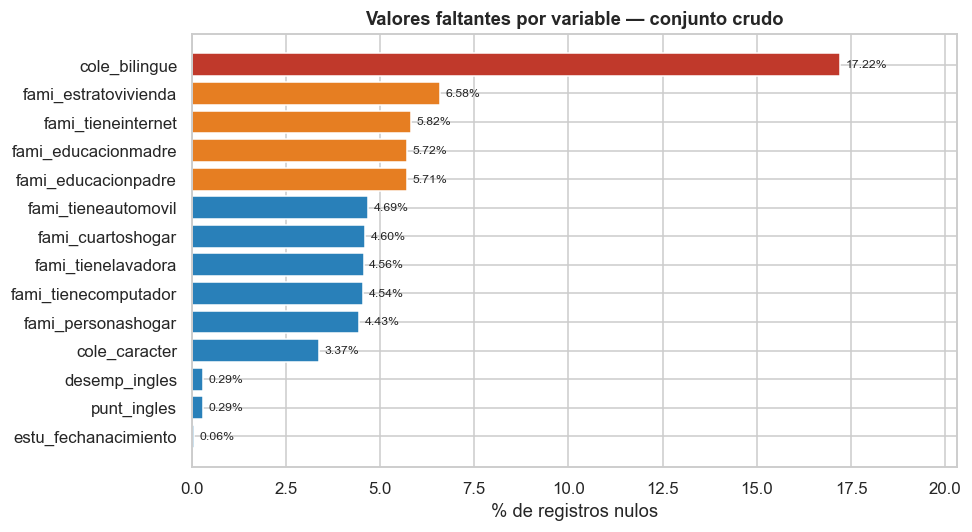

                      % nulos
cole_bilingue          17.216
fami_estratovivienda    6.578
fami_tieneinternet      5.817
fami_educacionmadre     5.721
fami_educacionpadre     5.713
fami_tieneautomovil     4.692
fami_cuartoshogar       4.596
fami_tienelavadora      4.562
fami_tienecomputador    4.542
fami_personashogar      4.432
cole_caracter           3.366
desemp_ingles           0.288
punt_ingles             0.288
estu_fechanacimiento    0.062


In [9]:
# --- Mapa de valores nulos por variable (conjunto crudo) ---------------------
nulos = (df_crudo.isna().sum() / len(df_crudo) * 100).sort_values(ascending=False)
nulos = nulos[nulos > 0]

fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#c0392b" if v > 10 else "#e67e22" if v > 5 else "#2980b9" for v in nulos.values]
ax.barh(nulos.index[::-1], nulos.values[::-1], color=colores[::-1])
for i, v in enumerate(nulos.values[::-1]):
    ax.text(v + 0.15, i, f"{v:.2f}%", va="center", fontsize=8)
ax.set_xlabel("% de registros nulos")
ax.set_title("Valores faltantes por variable — conjunto crudo")
ax.set_xlim(0, nulos.max() * 1.18)
plt.tight_layout(); plt.show()

print(nulos.round(3).to_frame("% nulos").to_string())

## 2.3 Distribución de la variable objetivo

Antes de cualquier limpieza se caracteriza la variable de la que se deriva el objetivo,
`punt_global`, y la distribución de la clase binaria resultante.

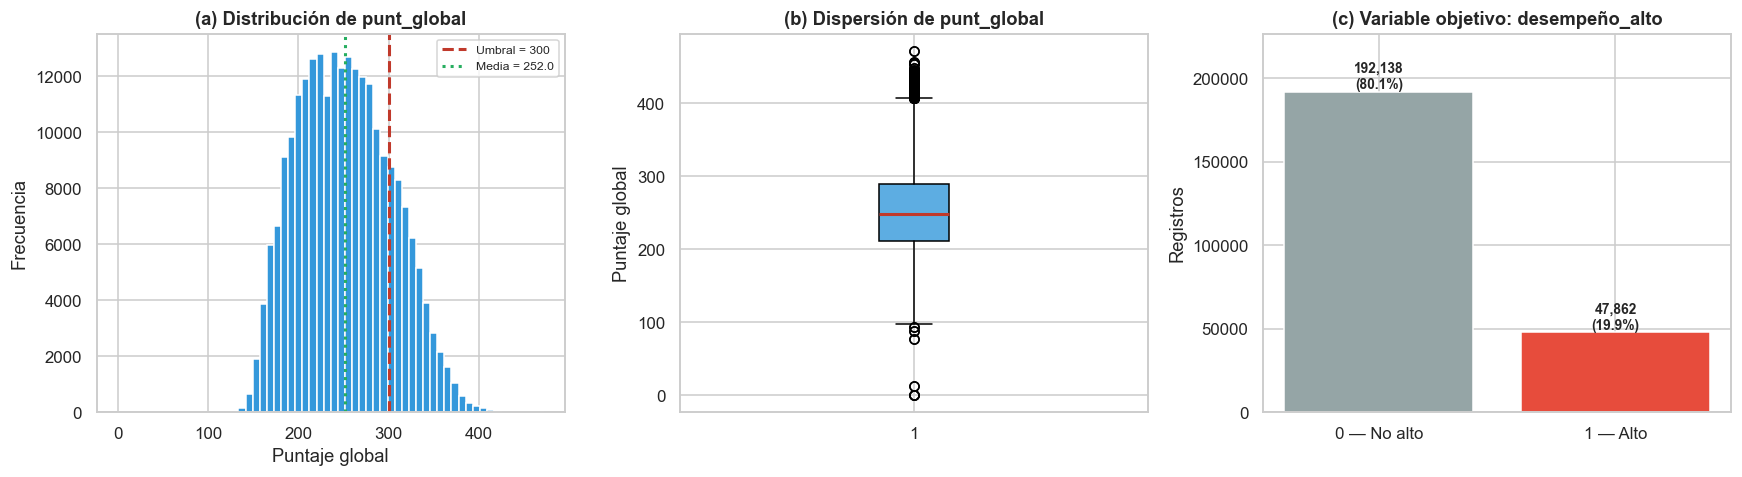

Estadisticos descriptivos de punt_global
count    240000.00
mean        252.02
std          51.94
min           0.00
25%         212.00
50%         249.00
75%         290.00
max         472.00

Asimetria (skewness) : 0.2443
Curtosis             : -0.5494

Percentiles clave
  P1   =  156.0
  P5   =  173.0
  P10  =  185.0
  P25  =  212.0
  P50  =  249.0
  P75  =  290.0
  P80  =  299.0
  P90  =  323.0
  P95  =  341.0
  P99  =  370.0

Proporcion de la clase positiva : 19.94%
Razon de desbalance (0:1)       : 4.01 : 1
Accuracy del clasificador trivial (siempre 0): 80.06%


In [10]:
# =============================================================================
# 2.3  Distribucion de la variable objetivo
# =============================================================================
pg = pd.to_numeric(df_crudo["punt_global"], errors="coerce").dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Distribucion del puntaje global
axes[0].hist(pg, bins=60, color="#3498db", edgecolor="white")
axes[0].axvline(UMBRAL_DESEMPENO_ALTO, color="#c0392b", ls="--", lw=2,
                label=f"Umbral = {UMBRAL_DESEMPENO_ALTO}")
axes[0].axvline(pg.mean(), color="#27ae60", ls=":", lw=2, label=f"Media = {pg.mean():.1f}")
axes[0].set_title("(a) Distribución de punt_global")
axes[0].set_xlabel("Puntaje global"); axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=8)

# (b) Diagrama de caja
axes[1].boxplot(pg, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#5dade2"), medianprops=dict(color="#c0392b", lw=2))
axes[1].set_title("(b) Dispersión de punt_global")
axes[1].set_ylabel("Puntaje global")

# (c) Clase binaria
y_prev = (pg >= UMBRAL_DESEMPENO_ALTO).astype(int)
conteo = y_prev.value_counts().sort_index()
barras = axes[2].bar(["0 — No alto", "1 — Alto"], conteo.values,
                     color=["#95a5a6", "#e74c3c"])
for b, v in zip(barras, conteo.values):
    axes[2].text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v / len(y_prev) * 100:.1f}%)",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[2].set_title("(c) Variable objetivo: desempeño_alto")
axes[2].set_ylabel("Registros")
axes[2].set_ylim(0, conteo.max() * 1.18)

plt.tight_layout(); plt.show()

print("Estadisticos descriptivos de punt_global")
print(pg.describe().round(2).to_string())
print(f"\nAsimetria (skewness) : {pg.skew():.4f}")
print(f"Curtosis             : {pg.kurtosis():.4f}")
print("\nPercentiles clave")
for p in (1, 5, 10, 25, 50, 75, 80, 90, 95, 99):
    print(f"  P{p:<3d} = {np.percentile(pg, p):6.1f}")

razon = conteo[0] / conteo[1]
print(f"\nProporcion de la clase positiva : {y_prev.mean() * 100:.2f}%")
print(f"Razon de desbalance (0:1)       : {razon:.2f} : 1")
print(f"Accuracy del clasificador trivial (siempre 0): {(1 - y_prev.mean()) * 100:.2f}%")

**Lectura de los resultados.**

- `punt_global` es aproximadamente simétrica y unimodal, centrada en ~252 puntos, sin la
  asimetría severa que obligaría a transformar la variable.
- El umbral de 300 puntos cae cerca del **percentil 80**, lo que confirma que se trata de un
  criterio exigente: identifica al quintil superior de la población.
- La razón de desbalance ≈ **4 : 1** es moderada. No es un caso extremo de detección de anomalías,
  pero sí es suficiente para que la *accuracy* deje de ser informativa y para justificar el uso de
  técnicas de balanceo (sección 3.8) y de métricas centradas en la clase minoritaria.
- Existe una cola de puntajes anormalmente bajos (incluido `punt_global = 0`) que las reglas de
  calidad B marcan como inválidos y que se eliminan en la sección 3.3.

## 2.4 Identificación de sesgos en los datos

El conjunto es un **censo administrativo**, no una muestra aleatoria de la población juvenil
colombiana. Esto implica sesgos de selección y sesgos estructurales que deben documentarse
porque condicionan tanto el desempeño del modelo como su uso ético.

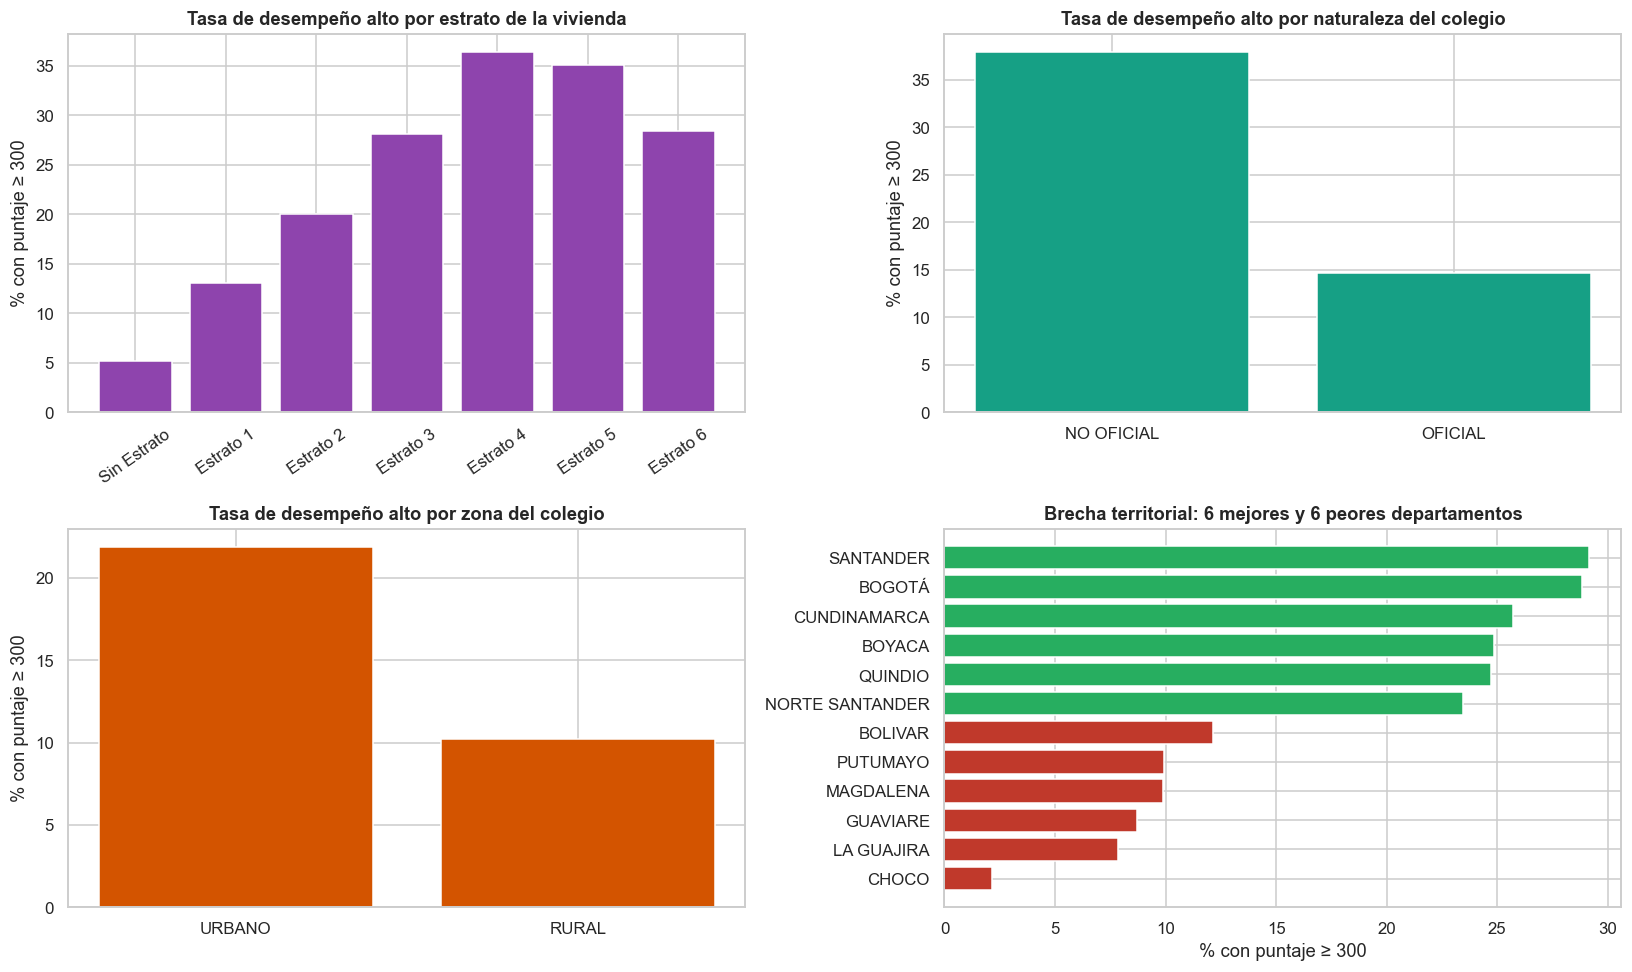


### fami_estratovivienda
                      tasa_alto  registros
fami_estratovivienda                      
Sin Estrato                5.19       4185
Estrato 1                 13.09      32439
Estrato 2                 20.02      40968
Estrato 3                 28.13      25262
Estrato 4                 36.40       6461
Estrato 5                 35.03       1921
Estrato 6                 28.39        870
    Brecha (max - min): 31.22 puntos porcentuales

### cole_naturaleza
                 tasa_alto  registros
cole_naturaleza                      
NO OFICIAL           37.97      27217
OFICIAL              14.65      92782
    Brecha (max - min): 23.31 puntos porcentuales

### cole_area_ubicacion
                     tasa_alto  registros
cole_area_ubicacion                      
URBANO                   21.88      99985
RURAL                    10.25      20014
    Brecha (max - min): 11.64 puntos porcentuales

### estu_genero
             tasa_alto  registros
estu_genero         

In [11]:
# =============================================================================
# 2.4  Analisis de sesgos estructurales
# =============================================================================
aux = df_crudo.drop_duplicates(subset=["estu_consecutivo"]).copy()
aux["punt_global"] = pd.to_numeric(aux["punt_global"], errors="coerce")
aux = aux.dropna(subset=["punt_global"])
aux["alto"] = (aux["punt_global"] >= UMBRAL_DESEMPENO_ALTO).astype(int)

def brecha(col, top=None, orden=None):
    g = (aux.groupby(col)["alto"]
            .agg(tasa_alto="mean", registros="size")
            .assign(tasa_alto=lambda d: d.tasa_alto * 100))
    g = g[g.registros >= 200]
    if orden:
        g = g.reindex([o for o in orden if o in g.index])
    else:
        g = g.sort_values("tasa_alto", ascending=False)
    return g.head(top) if top else g

ORDEN_ESTRATO = ["Sin Estrato"] + [f"Estrato {i}" for i in range(1, 7)]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

g = brecha("fami_estratovivienda", orden=ORDEN_ESTRATO)
axes[0, 0].bar(g.index, g.tasa_alto, color="#8e44ad")
axes[0, 0].set_title("Tasa de desempeño alto por estrato de la vivienda")
axes[0, 0].set_ylabel("% con puntaje ≥ 300"); axes[0, 0].tick_params(axis="x", rotation=35)

g = brecha("cole_naturaleza")
axes[0, 1].bar(g.index, g.tasa_alto, color="#16a085")
axes[0, 1].set_title("Tasa de desempeño alto por naturaleza del colegio")
axes[0, 1].set_ylabel("% con puntaje ≥ 300")

g = brecha("cole_area_ubicacion")
axes[1, 0].bar(g.index, g.tasa_alto, color="#d35400")
axes[1, 0].set_title("Tasa de desempeño alto por zona del colegio")
axes[1, 0].set_ylabel("% con puntaje ≥ 300")

g = brecha("cole_depto_ubicacion")
mejores, peores = g.head(6), g.tail(6)
comb = pd.concat([mejores, peores])
axes[1, 1].barh(comb.index[::-1], comb.tasa_alto[::-1],
                color=["#c0392b"] * 6 + ["#27ae60"] * 6)
axes[1, 1].set_title("Brecha territorial: 6 mejores y 6 peores departamentos")
axes[1, 1].set_xlabel("% con puntaje ≥ 300")

plt.tight_layout(); plt.show()

for col, orden in [("fami_estratovivienda", ORDEN_ESTRATO), ("cole_naturaleza", None),
                   ("cole_area_ubicacion", None), ("estu_genero", None)]:
    g = brecha(col, orden=orden)
    print(f"\n### {col}")
    print(g.round(2).to_string())
    print(f"    Brecha (max - min): {g.tasa_alto.max() - g.tasa_alto.min():.2f} puntos porcentuales")

g = brecha("cole_depto_ubicacion")
print(f"\n### Brecha territorial entre departamentos: "
      f"{g.tasa_alto.max():.1f}% ({g.index[0]}) vs {g.tasa_alto.min():.1f}% ({g.index[-1]}) "
      f"= {g.tasa_alto.max() - g.tasa_alto.min():.1f} p.p.")

### Sesgos identificados y sus implicaciones

| # | Sesgo | Evidencia | Implicación para el modelo |
|---|---|---|---|
| **S1** | **Sesgo de selección/supervivencia** | El conjunto solo contiene a quienes *llegaron* a grado 11 y presentaron el examen. Los jóvenes que desertaron antes —el grupo más vulnerable— están ausentes por construcción. | Las conclusiones **no son extrapolables** a la población juvenil total, únicamente a la población examinada. El modelo subestima el efecto real de la pobreza. |
| **S2** | **Sesgo socioeconómico estructural** | La tasa de desempeño alto crece monótonamente con el estrato: pasa de un dígito en estratos 1–2 a más de la mitad en estratos 5–6. | Es **señal real**, no ruido: la desigualdad educativa colombiana está genuinamente codificada en los datos y es lo que hace posible la predicción. |
| **S3** | **Sesgo institucional** | Los colegios NO OFICIALES duplican la tasa de desempeño alto de los OFICIALES. | El modelo puede aprender a penalizar a estudiantes de colegios oficiales. Se mitiga usando el modelo para **priorizar apoyo**, nunca para excluir. |
| **S4** | **Sesgo territorial** | La brecha entre el mejor y el peor departamento supera los 20 puntos porcentuales. | Un modelo entrenado a nivel nacional tendrá desempeño desigual por región; debe monitorearse por departamento. |
| **S5** | **Nulos no aleatorios (MNAR)** | Los faltantes se concentran en el cuestionario socioeconómico y son más frecuentes en estratos bajos. `cole_bilingue` tiene 17 % de nulos, concentrados en colegios oficiales. | La imputación debe **preservar la informatividad del faltante** (se crean indicadores explícitos, sección 3.4). |
| **S6** | **Duplicación en la fuente** | Cada registro aparece **exactamente dos veces** en el recurso publicado. | Sin deduplicación, la validación cruzada tendría el mismo estudiante en entrenamiento y prueba: **estimaciones de desempeño infladas**. Se corrige en 3.3. |

> **Nota de uso responsable.** El modelo predice a partir del contexto, no del mérito individual.
> Su único uso legítimo es **asignar apoyo adicional** a estudiantes con baja probabilidad
> predicha. Cualquier uso para seleccionar, ordenar o excluir estudiantes reproduciría y
> amplificaría las desigualdades que el modelo se limita a describir.

---
# FASE 3 — Preparación de los Datos

Esta fase transforma el recurso crudo en una matriz analítica apta para el modelamiento. Se
ejecuta en este orden, y el orden importa:

```
3.1 Selección de variables (incluye verificación de fuga)
3.2 Descripción estadística + reporte ydata-profiling
3.3 Limpieza de errores      ── duplicados, tipado, constantes, rangos imposibles, dominios
3.4 Limpieza de nulos        ── diagnóstico del mecanismo + imputación
3.5 Codificación             ── ordinal, binaria, one-hot
3.6 Relaciones lineales y no lineales
3.7 Reducción de dimensiones (PCA)
3.8 Balanceo (SMOTE)  ── SOLO sobre el conjunto de entrenamiento
```

> **Regla de oro contra la fuga de información:** toda transformación que *aprenda* parámetros de
> los datos (imputación, escalado, PCA, SMOTE) se ajusta **exclusivamente** sobre el conjunto de
> entrenamiento. Por eso las secciones 3.4–3.7 se implementan como `Pipeline` / `ColumnTransformer`
> de scikit-learn y no como manipulaciones directas del `DataFrame` completo. Las celdas de
> diagnóstico que sí operan sobre todo el conjunto son puramente descriptivas y no producen
> parámetros que entren al modelo.

## 3.1 Selección de variables

### 3.1.1 Verificación empírica de la fuga de información

Antes de seleccionar, se demuestra numéricamente por qué los puntajes por área deben excluirse.

Reconstruccion de punt_global a partir de los puntajes por area
  Correlacion de Pearson : 0.999985
  Error absoluto medio   : 0.2481 puntos sobre una escala de 500
  R^2 implicito          : 0.999969

=> punt_global NO es una variable nueva: es una combinacion lineal exacta de las
   cinco areas. Usarlas como predictores daria un modelo casi perfecto pero inutil,
   porque esas variables solo existen DESPUES de presentar la prueba.
   Se excluyen junto con desemp_ingles (que es una discretizacion de punt_ingles).


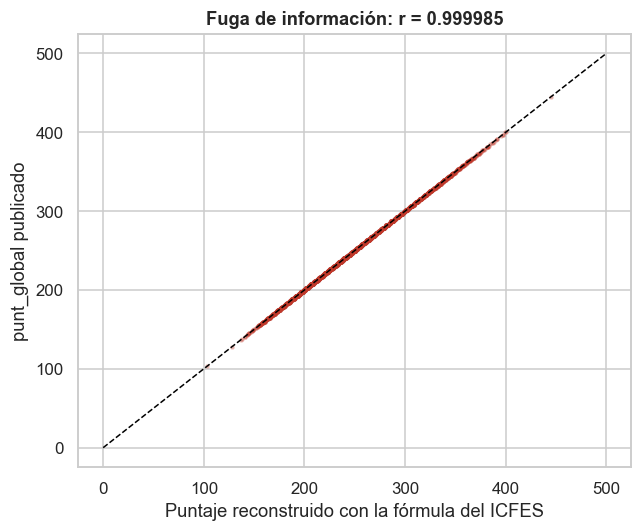

In [12]:
# =============================================================================
# 3.1.1  Demostracion de la fuga: punt_global es funcion determinista de las areas
# =============================================================================
ver = df_crudo.drop_duplicates(subset=["estu_consecutivo"]).copy()
AREAS = ["punt_lectura_critica", "punt_matematicas", "punt_sociales_ciudadanas",
         "punt_c_naturales", "punt_ingles"]
for c in AREAS + ["punt_global"]:
    ver[c] = pd.to_numeric(ver[c], errors="coerce")
ver = ver.dropna(subset=AREAS + ["punt_global"])

# Formula oficial del ICFES: ponderacion 3-3-3-3-1 reescalada a 0-500
formula = ((3 * ver.punt_lectura_critica + 3 * ver.punt_matematicas
            + 3 * ver.punt_sociales_ciudadanas + 3 * ver.punt_c_naturales
            + 1 * ver.punt_ingles) / 13) * 5

r = np.corrcoef(formula, ver.punt_global)[0, 1]
mae = (formula - ver.punt_global).abs().mean()

print("Reconstruccion de punt_global a partir de los puntajes por area")
print(f"  Correlacion de Pearson : {r:.6f}")
print(f"  Error absoluto medio   : {mae:.4f} puntos sobre una escala de 500")
print(f"  R^2 implicito          : {r**2:.6f}")
print("\n=> punt_global NO es una variable nueva: es una combinacion lineal exacta de las")
print("   cinco areas. Usarlas como predictores daria un modelo casi perfecto pero inutil,")
print("   porque esas variables solo existen DESPUES de presentar la prueba.")
print("   Se excluyen junto con desemp_ingles (que es una discretizacion de punt_ingles).")

fig, ax = plt.subplots(figsize=(6, 5))
idx = np.random.default_rng(SEMILLA).choice(len(ver), 4000, replace=False)
ax.scatter(formula.iloc[idx], ver.punt_global.iloc[idx], s=4, alpha=0.25, color="#c0392b")
ax.plot([0, 500], [0, 500], color="black", lw=1, ls="--")
ax.set_xlabel("Puntaje reconstruido con la fórmula del ICFES")
ax.set_ylabel("punt_global publicado")
ax.set_title(f"Fuga de información: r = {r:.6f}")
plt.tight_layout(); plt.show()

### 3.1.2 Variables seleccionadas y justificación

| Variable seleccionada | Justificación |
|---|---|
| `fami_estratovivienda` | Principal marcador de capacidad económica del hogar en Colombia; muestra la gradiente más fuerte frente al objetivo (sección 2.4). |
| `fami_educacionmadre` | El capital educativo materno es, en la literatura de economía de la educación, el predictor socioeconómico individual más robusto del logro académico. |
| `fami_educacionpadre` | Complementa el anterior y captura hogares con asimetría educativa entre progenitores. |
| `fami_tienecomputador`, `fami_tieneinternet` | Miden el acceso a recursos de estudio digitales, determinante tras la virtualización pos-pandemia. |
| `fami_tieneautomovil`, `fami_tienelavadora` | Indicadores de riqueza del hogar independientes del estrato catastral; corrigen la imprecisión del estrato en zonas rurales. |
| `fami_cuartoshogar`, `fami_personashogar` | Permiten derivar el hacinamiento, condición material asociada a la disponibilidad de espacio para estudiar. |
| `cole_naturaleza` | Separa el sistema oficial del privado, la mayor brecha institucional observada. |
| `cole_area_ubicacion` | Captura la brecha urbano-rural en dotación docente e infraestructura. |
| `cole_calendario` | El calendario B se asocia a colegios privados de alto costo; aporta señal no capturada por `cole_naturaleza`. |
| `cole_caracter` | Distingue formación académica de técnica, con currículos y énfasis distintos. |
| `cole_jornada` | La jornada única y la completa implican más horas lectivas; la nocturna concentra población en extraedad. |
| `cole_genero` | Los colegios de género único difieren sistemáticamente en composición socioeconómica. |
| `cole_sede_principal` | Las sedes no principales suelen ser rurales y con menor dotación. |
| `cole_depto_ubicacion` | Recoge el efecto territorial (calidad del sistema educativo departamental). |
| `estu_genero` | Existe una brecha de género documentada por área, con efecto neto sobre el global. |
| `estu_privado_libertad` | Condición excepcional con impacto directo sobre las condiciones de preparación. |
| `edad` *(derivada)* | La extraedad señala repitencia o reingreso, ambos asociados a menor logro. |
| `es_extranjero` *(derivada)* | La población migrante enfrenta barreras de integración escolar. |
| `indice_bienes` *(derivada)* | Resume en una escala 0–4 los cuatro indicadores de bienes; añade una lectura ordinal compacta. |

**Variables descartadas y motivo**

| Variable | Motivo del descarte |
|---|---|
| `punt_ingles`, `punt_matematicas`, `punt_sociales_ciudadanas`, `punt_c_naturales`, `punt_lectura_critica`, `desemp_ingles` | **Fuga de información** (demostrada en 3.1.1) |
| `estu_consecutivo` | Identificador sin poder predictivo |
| `periodo`, `estu_estudiante` | Constantes en la muestra (varianza nula) |
| `cole_mcpio_ubicacion` | 925 categorías: alta cardinalidad, riesgo de sobreajuste; `cole_depto_ubicacion` captura el efecto territorial |
| `estu_depto_reside` | Redundante con `cole_depto_ubicacion` |
| `estu_pais_reside` | 98,8 % un solo valor: casi constante |
| `estu_nacionalidad` | Se resume en `es_extranjero` |
| `estu_tipodocumento` | Proxy administrativo de la edad; se usa la edad explícita |
| `estu_fechanacimiento` | Se transforma en `edad` |
| `estu_estadoinvestigacion` | Se usa como filtro de calidad, no como predictor |

## 3.2 Descripción estadística y reporte exploratorio (ydata-profiling)

Se genera el reporte HTML exigido por la actividad. Para mantener el tiempo de ejecución
razonable se perfila una submuestra aleatoria representativa; el reporte se guarda en
`reportes/reporte_exploratorio_saber11.html`.

In [13]:
# =============================================================================
# 3.2  Descripcion estadistica del conjunto de trabajo
# =============================================================================
base = df_crudo.drop_duplicates().copy()
for c in AREAS + ["punt_global"]:
    base[c] = pd.to_numeric(base[c], errors="coerce")

n_reg, n_var = base.shape
n_num = base.select_dtypes(include=[np.number]).shape[1]
n_cat = n_var - n_num

resumen = pd.DataFrame({
    "Metrica": ["Numero de registros (crudos descargados)",
                "Numero de registros (tras deduplicacion exacta)",
                "Numero de variables",
                "Variables numericas",
                "Variables categoricas / texto",
                "Celdas faltantes",
                "% de celdas faltantes",
                "Memoria en RAM (MB)"],
    "Resultado": [f"{len(df_crudo):,}",
                  f"{n_reg:,}",
                  n_var,
                  n_num,
                  n_cat,
                  f"{int(base.isna().sum().sum()):,}",
                  f"{base.isna().sum().sum() / base.size * 100:.3f}%",
                  f"{base.memory_usage(deep=True).sum() / 1024**2:,.1f}"],
})
print(resumen.to_string(index=False))

print("\n--- Descripcion de las variables numericas ---")
print(base.select_dtypes(include=[np.number]).describe().T.round(2).to_string())

                                        Metrica Resultado
       Numero de registros (crudos descargados)   240,000
Numero de registros (tras deduplicacion exacta)   119,999
                            Numero de variables        37
                            Variables numericas         6
                  Variables categoricas / texto        31
                               Celdas faltantes    81,446
                          % de celdas faltantes    1.834%
                            Memoria en RAM (MB)     209.0

--- Descripcion de las variables numericas ---
                             count    mean    std  min    25%    50%    75%    max
punt_ingles               119654.0   50.27  13.30  0.0   40.0   49.0   58.0  100.0
punt_matematicas          119999.0   51.00  12.22  0.0   42.0   51.0   60.0  100.0
punt_sociales_ciudadanas  119999.0   48.11  11.94  0.0   39.0   48.0   57.0  100.0
punt_c_naturales          119999.0   49.41  10.41  0.0   41.0   49.0   57.0  100.0
punt_lectura_cr

In [14]:
# =============================================================================
# 3.2  Reporte exploratorio con ydata-profiling (entregable HTML)
# =============================================================================
RUTA_PERFIL = DIR_REPORTES / "reporte_exploratorio_saber11.html"
N_PERFIL = 20_000     # submuestra aleatoria para acotar el tiempo de computo

try:
    from ydata_profiling import ProfileReport

    muestra_perfil = base.sample(min(N_PERFIL, len(base)), random_state=SEMILLA)
    perfil = ProfileReport(
        muestra_perfil,
        title="Saber 11 (periodo 20224) — Reporte exploratorio",
        explorative=True,
        minimal=False,
        correlations={"auto": {"calculate": True}},
    )
    perfil.to_file(RUTA_PERFIL)
    print(f"Reporte generado: {RUTA_PERFIL}")
    print(f"Tamano: {RUTA_PERFIL.stat().st_size / 1024**2:.1f} MB "
          f"| Registros perfilados: {len(muestra_perfil):,}")
except Exception as exc:
    print(f"No fue posible generar el reporte con ydata-profiling: {exc}")
    print("Instale la dependencia con:  pip install ydata-profiling")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

  3%|▎         | 1/37 [00:01<00:36,  1.01s/it]

 14%|█▎        | 5/37 [00:01<00:08,  3.89it/s]

 22%|██▏       | 8/37 [00:01<00:05,  5.63it/s]

100%|██████████| 37/37 [00:01<00:00, 20.32it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte generado: E:\Maestria en Ciencia de Datos\aprendizaje_maquina\proyecto_integrador\reportes\reporte_exploratorio_saber11.html
Tamano: 4.8 MB | Registros perfilados: 20,000


## 3.3 Limpieza de errores

Se corrigen, en orden, los seis tipos de error detectados por la auditoría de la sección 2.2.
Cada paso registra cuántos registros elimina o modifica, de modo que el proceso sea trazable.

| # | Tipo de error | Acción realizada |
|---|---|---|
| E1 | **Registros duplicados** (cada fila aparece dos veces en la fuente) | Eliminación de duplicados exactos y por `estu_consecutivo` |
| E2 | **Tipos de dato incorrectos** (todo llega como texto) | Conversión explícita a numérico y a fecha con `errors="coerce"` |
| E3 | **Registros sin validez** (`estu_estadoinvestigacion` ≠ `PUBLICAR`) | Eliminación del registro |
| E4 | **Etiqueta ausente o fuera de rango** (`punt_global` nulo o = 0) | Eliminación del registro |
| E5 | **Edad imposible** (fechas de nacimiento erróneas: 0,5 años o 122 años) | Marcado como nulo y posterior imputación |
| E6 | **Nulos encubiertos** (`"No sabe"`, `"No Aplica"` en educación de los padres) | Conversión a `NaN` para tratarlos en 3.4 |
| E7 | **Columnas constantes** (`periodo`, `estu_estudiante`) | Eliminación por varianza nula |
| E8 | **Inconsistencias de texto** (espacios, mayúsculas) | Normalización con `strip()` |

In [15]:
# =============================================================================
# 3.3  Limpieza de errores  —  proceso trazable paso a paso
# =============================================================================
bitacora = []          # registro auditable de cada operacion

def anotar(paso, descripcion, antes, despues):
    bitacora.append({
        "Paso": paso, "Accion": descripcion,
        "Registros antes": antes, "Registros despues": despues,
        "Eliminados": antes - despues,
        "% eliminado": round((antes - despues) / antes * 100, 3) if antes else 0.0,
    })

df = df_crudo.copy()
n0 = len(df)
print(f"PUNTO DE PARTIDA: {n0:,} registros x {df.shape[1]} variables\n")

# --- E8: normalizacion de texto (antes de comparar categorias) ---------------
obj_cols = df.select_dtypes(include="object").columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())
print("E8 · Espacios en blanco normalizados en todas las columnas de texto")

# --- E1: duplicados ----------------------------------------------------------
n_ant = len(df)
df = df.drop_duplicates()
anotar("E1a", "Eliminacion de filas duplicadas exactas", n_ant, len(df))
print(f"E1a · Duplicados exactos eliminados : {n_ant - len(df):,}")

n_ant = len(df)
df = df.drop_duplicates(subset=["estu_consecutivo"], keep="first")
anotar("E1b", "Eliminacion de estu_consecutivo repetido", n_ant, len(df))
print(f"E1b · Consecutivos repetidos eliminados : {n_ant - len(df):,}")
print(f"      -> La fuente publica CADA registro dos veces. Sin este paso, el mismo")
print(f"         estudiante quedaria en entrenamiento y en prueba (fuga por duplicacion).")

# --- E2: tipado --------------------------------------------------------------
for c in AREAS + ["punt_global"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["fecha_nacimiento"] = pd.to_datetime(df["estu_fechanacimiento"],
                                        format="%d/%m/%Y", errors="coerce")
print(f"\nE2  · Conversion de tipos aplicada a {len(AREAS) + 1} numericas y 1 fecha")

# --- E3: validez del resultado ----------------------------------------------
n_ant = len(df)
df = df[df["estu_estadoinvestigacion"] == "PUBLICAR"]
anotar("E3", "Eliminacion de resultados no publicables", n_ant, len(df))
print(f"E3  · Registros con estado != PUBLICAR eliminados : {n_ant - len(df):,}")

# --- E4: etiqueta valida -----------------------------------------------------
n_ant = len(df)
df = df[df["punt_global"].notna()]
anotar("E4a", "Eliminacion de registros sin punt_global", n_ant, len(df))

n_ant = len(df)
df = df[(df["punt_global"] >= 1) & (df["punt_global"] <= 500)]
anotar("E4b", "Eliminacion de punt_global fuera de [1, 500]", n_ant, len(df))
print(f"E4  · Etiquetas invalidas eliminadas : {n0 - len(df) - sum(b['Eliminados'] for b in bitacora[:3]):,}")

# --- E5: edad derivada y saneada --------------------------------------------
FECHA_EXAMEN = pd.Timestamp("2022-11-01")     # aplicacion del periodo 20224
df["edad"] = ((FECHA_EXAMEN - df["fecha_nacimiento"]).dt.days / 365.25)

EDAD_MIN, EDAD_MAX = 13, 30
fuera = ((df["edad"] < EDAD_MIN) | (df["edad"] > EDAD_MAX))
n_fuera = int(fuera.sum())
df.loc[fuera, "edad"] = np.nan          # se marcan como nulos, no se borra el registro
df["edad"] = df["edad"].round(2)
print(f"\nE5  · Edades fuera de [{EDAD_MIN}, {EDAD_MAX}] marcadas como nulas : {n_fuera:,}")
print(f"      (p.ej. fechas de nacimiento de 1900 o de 2022: errores de digitacion)")
anotar("E5", "Edades imposibles marcadas como nulas (no elimina filas)", len(df), len(df))

# --- E6: nulos encubiertos ---------------------------------------------------
NULOS_ENCUBIERTOS = ["No sabe", "No Aplica", "No aplica", "NO APLICA", "-", ""]
antes_enc = df[["fami_educacionmadre", "fami_educacionpadre"]].isna().sum().sum()
for c in ["fami_educacionmadre", "fami_educacionpadre"]:
    df[c] = df[c].replace(NULOS_ENCUBIERTOS, np.nan)
despues_enc = df[["fami_educacionmadre", "fami_educacionpadre"]].isna().sum().sum()
print(f"\nE6  · Valores 'No sabe'/'No Aplica' convertidos a NaN : {despues_enc - antes_enc:,}")
anotar("E6", "Nulos encubiertos convertidos a NaN", len(df), len(df))

# --- E7: columnas constantes -------------------------------------------------
constantes = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
df = df.drop(columns=constantes)
print(f"\nE7  · Columnas constantes eliminadas : {constantes}")

print(f"\n{'=' * 70}")
print(f"RESULTADO DE LA LIMPIEZA DE ERRORES")
print(f"  Registros:  {n0:,}  ->  {len(df):,}   "
      f"({(n0 - len(df)) / n0 * 100:.2f}% descartado)")
print(f"  Variables:  {df_crudo.shape[1]}  ->  {df.shape[1]}")
print(f"{'=' * 70}")

pd.DataFrame(bitacora)

PUNTO DE PARTIDA: 240,000 registros x 37 variables



E8 · Espacios en blanco normalizados en todas las columnas de texto


E1a · Duplicados exactos eliminados : 120,001
E1b · Consecutivos repetidos eliminados : 0
      -> La fuente publica CADA registro dos veces. Sin este paso, el mismo
         estudiante quedaria en entrenamiento y en prueba (fuga por duplicacion).



E2  · Conversion de tipos aplicada a 6 numericas y 1 fecha
E3  · Registros con estado != PUBLICAR eliminados : 44
E4  · Etiquetas invalidas eliminadas : 2

E5  · Edades fuera de [13, 30] marcadas como nulas : 1,391
      (p.ej. fechas de nacimiento de 1900 o de 2022: errores de digitacion)

E6  · Valores 'No sabe'/'No Aplica' convertidos a NaN : 13,032



E7  · Columnas constantes eliminadas : ['periodo', 'estu_estadoinvestigacion', 'estu_estudiante']

RESULTADO DE LA LIMPIEZA DE ERRORES
  Registros:  240,000  ->  119,953   (50.02% descartado)
  Variables:  37  ->  36


,Paso,Accion,Registros antes,Registros despues,Eliminados,% eliminado
0,E1a,Eliminacion de filas duplicadas exactas,240000,119999,120001,50.000
1,E1b,Eliminacion de estu_consecutivo repetido,119999,119999,0,0.000
2,E3,Eliminacion de resultados no publicables,119999,119955,44,0.037
3,E4a,Eliminacion de registros sin punt_global,119955,119955,0,0.000
4,E4b,"Eliminacion de punt_global fuera de [1, 500]",119955,119953,2,0.002
5,E5,Edades imposibles marcadas como nulas (no elim...,119953,119953,0,0.000
6,E6,Nulos encubiertos convertidos a NaN,119953,119953,0,0.000


In [16]:
# --- Verificacion: las reglas de calidad ahora se cumplen --------------------
chequeos = {
    "Filas duplicadas exactas": int(df.duplicated().sum()),
    "estu_consecutivo repetido": int(df.duplicated(subset=["estu_consecutivo"]).sum()),
    "punt_global nulo": int(df["punt_global"].isna().sum()),
    "punt_global fuera de [1,500]": int(((df.punt_global < 1) | (df.punt_global > 500)).sum()),
    "edad fuera de [13,30] (no nula)": int(((df.edad < 13) | (df.edad > 30)).sum()),
}
_estado = df.get("estu_estadoinvestigacion", pd.Series(["PUBLICAR"] * len(df)))
chequeos["Registros no publicables"] = int((_estado != "PUBLICAR").sum())

res = pd.DataFrame(chequeos.items(), columns=["Verificacion", "Violaciones"])
res["Estado"] = np.where(res.Violaciones == 0, "OK", "PENDIENTE")
print(res.to_string(index=False))
assert res.Violaciones.sum() == 0, "Quedan violaciones de reglas de calidad"
print("\nTodas las reglas de calidad de integridad y rango se cumplen.")

                   Verificacion  Violaciones Estado
       Filas duplicadas exactas            0     OK
      estu_consecutivo repetido            0     OK
               punt_global nulo            0     OK
   punt_global fuera de [1,500]            0     OK
edad fuera de [13,30] (no nula)            0     OK
       Registros no publicables            0     OK

Todas las reglas de calidad de integridad y rango se cumplen.


In [17]:
# =============================================================================
# Construccion de variables derivadas y de la variable OBJETIVO
# =============================================================================
# es_extranjero: la nacionalidad no colombiana implica barreras de integracion escolar
df["es_extranjero"] = (df["estu_nacionalidad"].fillna("COLOMBIA") != "COLOMBIA").astype(int)

# indice_bienes: suma de los cuatro indicadores de posesion del hogar (0 a 4).
# Los nulos se propagan a NaN para no confundir "no tiene" con "no respondio".
BIENES = ["fami_tieneautomovil", "fami_tienecomputador",
          "fami_tieneinternet", "fami_tienelavadora"]
bienes_bin = df[BIENES].apply(lambda s: s.map({"Si": 1, "No": 0}))
df["indice_bienes"] = bienes_bin.sum(axis=1, min_count=len(BIENES))

# VARIABLE OBJETIVO
df["desempeno_alto"] = (df["punt_global"] >= UMBRAL_DESEMPENO_ALTO).astype(int)

print("Variables derivadas creadas: es_extranjero, indice_bienes, desempeno_alto\n")
print(f"es_extranjero  -> {df.es_extranjero.mean() * 100:.2f}% de estudiantes extranjeros")
print(f"indice_bienes  -> media {df.indice_bienes.mean():.2f} / 4  "
      f"({df.indice_bienes.isna().mean() * 100:.2f}% nulos)")
print(f"desempeno_alto -> {df.desempeno_alto.mean() * 100:.2f}% clase positiva "
      f"({int(df.desempeno_alto.sum()):,} de {len(df):,})")

Variables derivadas creadas: es_extranjero, indice_bienes, desempeno_alto

es_extranjero  -> 1.22% de estudiantes extranjeros
indice_bienes  -> media 2.34 / 4  (8.21% nulos)
desempeno_alto -> 19.95% clase positiva (23,925 de 119,953)


In [18]:
# =============================================================================
# Definicion formal del conjunto analitico (aplicando la seleccion de 3.1)
# =============================================================================
VAR_ORDINALES = {
    "fami_estratovivienda": ["Sin Estrato", "Estrato 1", "Estrato 2", "Estrato 3",
                             "Estrato 4", "Estrato 5", "Estrato 6"],
    "fami_cuartoshogar": ["Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis o mas"],
    "fami_personashogar": ["1 a 2", "3 a 4", "5 a 6", "7 a 8", "9 o más"],
    "fami_educacionmadre": ["Ninguno", "Primaria incompleta", "Primaria completa",
                            "Secundaria (Bachillerato) incompleta",
                            "Secundaria (Bachillerato) completa",
                            "Técnica o tecnológica incompleta",
                            "Técnica o tecnológica completa",
                            "Educación profesional incompleta",
                            "Educación profesional completa", "Postgrado"],
    "fami_educacionpadre": ["Ninguno", "Primaria incompleta", "Primaria completa",
                            "Secundaria (Bachillerato) incompleta",
                            "Secundaria (Bachillerato) completa",
                            "Técnica o tecnológica incompleta",
                            "Técnica o tecnológica completa",
                            "Educación profesional incompleta",
                            "Educación profesional completa", "Postgrado"],
}

VAR_BINARIAS = {
    "fami_tieneautomovil": {"No": 0, "Si": 1},
    "fami_tienecomputador": {"No": 0, "Si": 1},
    "fami_tieneinternet": {"No": 0, "Si": 1},
    "fami_tienelavadora": {"No": 0, "Si": 1},
    "cole_bilingue": {"N": 0, "S": 1},
    "cole_sede_principal": {"N": 0, "S": 1},
    "cole_naturaleza": {"OFICIAL": 0, "NO OFICIAL": 1},
    "cole_area_ubicacion": {"RURAL": 0, "URBANO": 1},
    "estu_genero": {"M": 0, "F": 1},
    "estu_privado_libertad": {"N": 0, "S": 1},
}

VAR_NOMINALES = ["cole_calendario", "cole_caracter", "cole_jornada",
                 "cole_genero", "cole_depto_ubicacion"]

VAR_NUMERICAS = ["edad", "indice_bienes", "es_extranjero"]

PREDICTORES = list(VAR_ORDINALES) + list(VAR_BINARIAS) + VAR_NOMINALES + VAR_NUMERICAS
OBJETIVO = "desempeno_alto"

datos = df[PREDICTORES + [OBJETIVO, "punt_global"]].copy()

print(f"Conjunto analitico: {datos.shape[0]:,} registros x {len(PREDICTORES)} predictores")
print(f"\n  Ordinales ({len(VAR_ORDINALES)}) : {list(VAR_ORDINALES)}")
print(f"\n  Binarias  ({len(VAR_BINARIAS)}) : {list(VAR_BINARIAS)}")
print(f"\n  Nominales ({len(VAR_NOMINALES)}) : {VAR_NOMINALES}")
print(f"\n  Numericas ({len(VAR_NUMERICAS)}) : {VAR_NUMERICAS}")

Conjunto analitico: 119,953 registros x 23 predictores

  Ordinales (5) : ['fami_estratovivienda', 'fami_cuartoshogar', 'fami_personashogar', 'fami_educacionmadre', 'fami_educacionpadre']

  Binarias  (10) : ['fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'cole_bilingue', 'cole_sede_principal', 'cole_naturaleza', 'cole_area_ubicacion', 'estu_genero', 'estu_privado_libertad']

  Nominales (5) : ['cole_calendario', 'cole_caracter', 'cole_jornada', 'cole_genero', 'cole_depto_ubicacion']

  Numericas (3) : ['edad', 'indice_bienes', 'es_extranjero']


## 3.4 Limpieza de valores nulos

### 3.4.1 Diagnóstico del mecanismo de los faltantes

No basta con contar nulos: hay que entender **por qué** faltan. Los tres mecanismos clásicos
(Rubin, 1976) son:

- **MCAR** (*Missing Completely At Random*): la ausencia es independiente de todo. Se puede
  eliminar o imputar sin sesgo.
- **MAR** (*Missing At Random*): la ausencia depende de variables **observadas**. La imputación
  condicional es válida.
- **MNAR** (*Missing Not At Random*): la ausencia depende del **propio valor faltante** o del
  objetivo. Eliminar sesga los resultados; hay que **modelar la ausencia** como información.

La prueba operativa es directa: si la tasa de desempeño alto difiere entre quienes responden y
quienes no responden una variable, ese faltante **no es aleatorio** y su ausencia es informativa.

Tasa global de desempeno alto: 19.95%

            Variable  % nulos  % alto | falta  % alto | responde  Diferencia (p.p.) p-valor chi2          Mecanismo
       cole_bilingue    17.22           17.39              20.48              -3.08     6.59e-24 MNAR / informativo
 fami_educacionpadre    13.94           18.98              20.10              -1.12     7.86e-04 MNAR / informativo
 fami_educacionmadre     8.35           16.15              20.29              -4.14     3.85e-23 MNAR / informativo
       indice_bienes     8.21           13.46              20.53              -7.07     2.69e-63 MNAR / informativo
fami_estratovivienda     6.58           11.25              20.56              -9.31     7.06e-89 MNAR / informativo
  fami_tieneinternet     5.82           11.18              20.49              -9.31     2.41e-79 MNAR / informativo
 fami_tieneautomovil     4.69           14.71              20.20              -5.49     1.01e-23 MNAR / informativo
   fami_cuartoshogar     4.60    

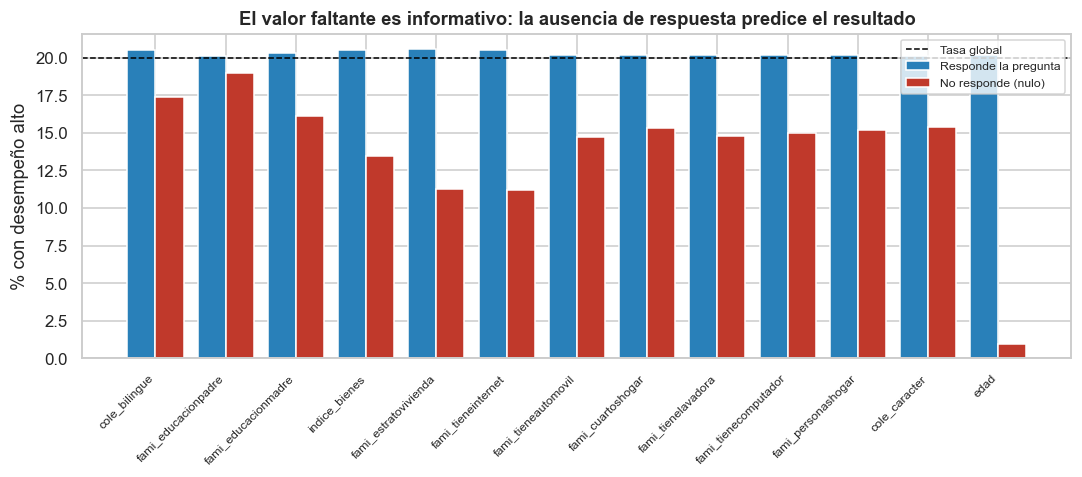

In [19]:
# =============================================================================
# 3.4.1  Diagnostico del mecanismo de los valores faltantes
# =============================================================================
from scipy import stats

nulos = datos[PREDICTORES].isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

diag = []
tasa_global = datos[OBJETIVO].mean()
for col in nulos.index:
    falta = datos[col].isna()
    tasa_falta = datos.loc[falta, OBJETIVO].mean()
    tasa_ok = datos.loc[~falta, OBJETIVO].mean()
    # Prueba chi-cuadrado de independencia entre "faltar" y la clase objetivo
    tabla = pd.crosstab(falta, datos[OBJETIVO])
    chi2, p, _, _ = stats.chi2_contingency(tabla)
    diag.append({
        "Variable": col,
        "% nulos": round(falta.mean() * 100, 2),
        "% alto | falta": round(tasa_falta * 100, 2),
        "% alto | responde": round(tasa_ok * 100, 2),
        "Diferencia (p.p.)": round((tasa_falta - tasa_ok) * 100, 2),
        "p-valor chi2": f"{p:.2e}",
        "Mecanismo": "MNAR / informativo" if p < 0.01 else "compatible con MCAR",
    })

df_diag = pd.DataFrame(diag)
print(f"Tasa global de desempeno alto: {tasa_global * 100:.2f}%\n")
print(df_diag.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(df_diag))
ax.bar(x - 0.2, df_diag["% alto | responde"], 0.4, label="Responde la pregunta", color="#2980b9")
ax.bar(x + 0.2, df_diag["% alto | falta"], 0.4, label="No responde (nulo)", color="#c0392b")
ax.axhline(tasa_global * 100, color="black", ls="--", lw=1, label="Tasa global")
ax.set_xticks(x); ax.set_xticklabels(df_diag.Variable, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% con desempeño alto")
ax.set_title("El valor faltante es informativo: la ausencia de respuesta predice el resultado")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Patrones de ausencia mas frecuentes (1 = valor faltante)
Orden de las columnas: ['cole_bilingue', 'fami_educacionpadre', 'fami_educacionmadre', 'indice_bienes', 'fami_estratovivienda', 'fami_tieneinternet', 'fami_tieneautomovil', 'fami_cuartoshogar', 'fami_tienelavadora', 'fami_tienecomputador', 'fami_personashogar', 'cole_caracter', 'edad']

   79,880 (66.59%)  ->  sin faltantes
   13,536 (11.28%)  ->  cole_bilingue
    6,579 ( 5.48%)  ->  fami_educacionpadre
    2,988 ( 2.49%)  ->  cole_bilingue, cole_caracter
    2,693 ( 2.25%)  ->  fami_educacionpadre, fami_educacionmadre, indice_bienes, fami_estratovivienda, fami_tieneintern
    2,162 ( 1.80%)  ->  fami_educacionpadre, fami_educacionmadre, indice_bienes, fami_estratovivienda, fami_tieneintern
    1,529 ( 1.27%)  ->  fami_educacionpadre, fami_educacionmadre
    1,492 ( 1.24%)  ->  indice_bienes, fami_tieneautomovil, fami_cuartoshogar, fami_tienelavadora, fami_tienecomputador


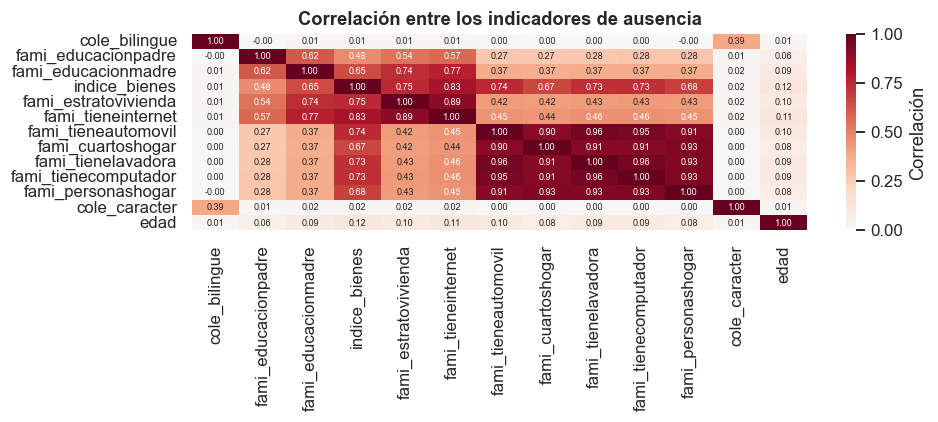

In [20]:
# --- Patron conjunto de faltantes (co-ocurrencia) ---------------------------
mascara = datos[nulos.index].isna()
combinaciones = mascara.astype(int).astype(str).agg("".join, axis=1).value_counts().head(8)

print("Patrones de ausencia mas frecuentes (1 = valor faltante)")
print(f"Orden de las columnas: {list(nulos.index)}\n")
for patron, cnt in combinaciones.items():
    faltantes = [c for c, b in zip(nulos.index, patron) if b == "1"]
    etiqueta = "sin faltantes" if not faltantes else ", ".join(faltantes)
    print(f"  {cnt:>7,} ({cnt / len(datos) * 100:5.2f}%)  ->  {etiqueta[:95]}")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(mascara.corr(), cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 6}, cbar_kws={"label": "Correlación"}, ax=ax)
ax.set_title("Correlación entre los indicadores de ausencia")
plt.tight_layout(); plt.show()

### 3.4.2 Estrategia de imputación

El diagnóstico muestra que los faltantes **no son aleatorios**: los estudiantes que dejan en
blanco el cuestionario socioeconómico tienen tasas de desempeño alto sistemáticamente distintas.
Eliminar esos registros descartaría cerca del 20 % de la muestra e introduciría sesgo. La
estrategia adoptada tiene dos componentes:

1. **Indicador explícito de ausencia** (`*_faltante`) para las variables con nulos informativos:
   el modelo puede así usar "no respondió" como una categoría con significado propio.
2. **Imputación** del valor, diferenciada por tipo de variable.

| Variable | % nulos | Método aplicado | Justificación |
|---|---|---|---|
| `cole_bilingue` | ~17 % | Imputación por constante `0` (no bilingüe) + indicador de ausencia | El campo se deja vacío casi siempre en colegios oficiales no bilingües: la ausencia equivale a "no bilingüe" |
| `fami_estratovivienda` | ~6,6 % | **Mediana** del código ordinal + indicador | Variable ordinal; la mediana es robusta y no inventa categorías extremas |
| `fami_educacionmadre` / `fami_educacionpadre` | ~5,7 % (+ "No sabe"/"No aplica") | **Mediana** del código ordinal + indicador | Ídem; el indicador captura el hecho, informativo, de desconocer la escolaridad del progenitor |
| `fami_tiene*` (4 variables) | ~4,5–5,8 % | **Moda** + indicador | Binarias; la moda preserva la distribución marginal |
| `fami_cuartoshogar`, `fami_personashogar` | ~4,5 % | **Mediana** del código ordinal + indicador | Ordinales de conteo |
| `cole_caracter` | ~3,4 % | Categoría explícita `"SIN INFORMACION"` | Nominal: crear una categoría propia es preferible a asignar la moda |
| `edad` | ~0,1 % (tras E5) | **Mediana** | Volumen despreciable; la mediana es robusta frente a la extraedad |
| `indice_bienes` | ~5 % | **Mediana** | Derivada; hereda los nulos de sus componentes |

Estas imputaciones se implementan dentro del `ColumnTransformer` del pipeline (sección 3.5),
de modo que los estadísticos (mediana, moda) se calculan **solo con el conjunto de entrenamiento**
y se aplican al de prueba sin fuga.

In [21]:
# =============================================================================
# 3.4.2  Indicadores de ausencia (se calculan fila a fila: no producen fuga)
# =============================================================================
VARS_CON_NULOS_INFORMATIVOS = [
    "cole_bilingue", "fami_estratovivienda", "fami_educacionmadre",
    "fami_educacionpadre", "fami_tieneinternet", "fami_tienecomputador",
    "fami_cuartoshogar", "fami_personashogar",
]

INDICADORES_AUSENCIA = []
for col in VARS_CON_NULOS_INFORMATIVOS:
    nombre = f"{col}_faltante"
    datos[nombre] = datos[col].isna().astype(int)
    INDICADORES_AUSENCIA.append(nombre)

VAR_NUMERICAS_EXT = VAR_NUMERICAS + INDICADORES_AUSENCIA
PREDICTORES_EXT = PREDICTORES + INDICADORES_AUSENCIA

print(f"Indicadores de ausencia creados: {len(INDICADORES_AUSENCIA)}")
for c in INDICADORES_AUSENCIA:
    print(f"  {c:<38} activo en {datos[c].mean() * 100:5.2f}% de los registros")
print(f"\nTotal de predictores: {len(PREDICTORES_EXT)}")

Indicadores de ausencia creados: 8
  cole_bilingue_faltante                 activo en 17.22% de los registros
  fami_estratovivienda_faltante          activo en  6.58% de los registros
  fami_educacionmadre_faltante           activo en  8.35% de los registros
  fami_educacionpadre_faltante           activo en 13.94% de los registros
  fami_tieneinternet_faltante            activo en  5.82% de los registros
  fami_tienecomputador_faltante          activo en  4.54% de los registros
  fami_cuartoshogar_faltante             activo en  4.60% de los registros
  fami_personashogar_faltante            activo en  4.43% de los registros

Total de predictores: 31


## 3.5 Codificación de variables categóricas

Se aplican tres esquemas distintos según la naturaleza de cada variable. Usar un único esquema
para todas sería un error: codificar como ordinal una variable nominal impone un orden inexistente,
y aplicar *one-hot* a una ordinal destruye información de orden que los modelos pueden aprovechar.

| Grupo | Variables | Método | Justificación |
|---|---|---|---|
| **Ordinales** | `fami_estratovivienda`, `fami_cuartoshogar`, `fami_personashogar`, `fami_educacionmadre`, `fami_educacionpadre` | `OrdinalEncoder` con orden explícito | Las categorías tienen un orden natural inequívoco (Estrato 1 < … < Estrato 6). Se preserva la monotonía con una sola columna, evitando la explosión dimensional. |
| **Binarias** | `fami_tiene*`, `cole_bilingue`, `cole_naturaleza`, `cole_area_ubicacion`, `cole_sede_principal`, `estu_genero`, `estu_privado_libertad` | Mapeo directo a {0, 1} | Con dos categorías, one-hot y ordinal son equivalentes; el mapeo explícito documenta qué significa el 1. |
| **Nominales** | `cole_calendario`, `cole_caracter`, `cole_jornada`, `cole_genero`, `cole_depto_ubicacion` | `OneHotEncoder(handle_unknown="ignore")` | No existe orden natural. `handle_unknown="ignore"` garantiza que una categoría nueva en producción (p. ej. un departamento no visto) no rompa la aplicación desplegada. |
| **Numéricas** | `edad`, `indice_bienes`, `es_extranjero`, indicadores `*_faltante` | `StandardScaler` | La estandarización es indispensable para los modelos sensibles a la escala (SVM, KNN, regresión logística regularizada). |

**Decisión sobre `Sin Estrato`.** Se codifica como el nivel 0, por debajo del Estrato 1. Es la
opción defendible: son viviendas sin estratificación catastral, típicas de zonas rurales
dispersas y asentamientos informales, cuyo perfil socioeconómico es igual o inferior al del
estrato 1 (se verifica empíricamente a continuación).

In [22]:
# --- Verificacion de la decision de codificar 'Sin Estrato' como nivel 0 ----
chk = (datos.groupby("fami_estratovivienda")[OBJETIVO]
            .agg(tasa_alto="mean", n="size")
            .assign(tasa_alto=lambda d: (d.tasa_alto * 100).round(2))
            .reindex(VAR_ORDINALES["fami_estratovivienda"]))
print(chk.to_string())
print("\n'Sin Estrato' presenta una tasa de desempeno alto comparable a la de los estratos")
print("mas bajos, lo que respalda ubicarlo en el extremo inferior de la escala ordinal.")

                      tasa_alto      n
fami_estratovivienda                  
Sin Estrato                5.19   4181
Estrato 1                 13.09  32429
Estrato 2                 20.02  40957
Estrato 3                 28.14  25253
Estrato 4                 36.41   6455
Estrato 5                 35.03   1921
Estrato 6                 28.39    870

'Sin Estrato' presenta una tasa de desempeno alto comparable a la de los estratos
mas bajos, lo que respalda ubicarlo en el extremo inferior de la escala ordinal.


In [23]:
# =============================================================================
# 3.5  Construccion del preprocesador (ColumnTransformer)
#      Todos los estadisticos se ajustan SOLO con el conjunto de entrenamiento.
# =============================================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

# 1) Codificacion binaria aplicada directamente (mapeo determinista, sin parametros)
for col, mapa in VAR_BINARIAS.items():
    # float64 explicito: los imputadores se ajustan con este tipo y exigen el mismo
    # en transform. Fijarlo aqui evita discrepancias al predecir sobre datos nuevos.
    datos[col] = datos[col].map(mapa).astype("float64")
for col in VAR_NUMERICAS:
    datos[col] = datos[col].astype("float64")

COLS_ORDINALES = list(VAR_ORDINALES)
COLS_BINARIAS = list(VAR_BINARIAS)
COLS_NOMINALES = VAR_NOMINALES
COLS_NUMERICAS = VAR_NUMERICAS_EXT

# Columnas que el pipeline espera en punto flotante. Se guarda la lista en los
# metadatos del modelo para que la aplicacion desplegada aplique la misma conversion.
COLS_FLOAT = COLS_BINARIAS + COLS_NUMERICAS

# --- Rama ordinal: codificar el orden -> imputar mediana -> escalar ----------
rama_ordinal = Pipeline([
    ("codificar", OrdinalEncoder(categories=[VAR_ORDINALES[c] for c in COLS_ORDINALES],
                                 handle_unknown="use_encoded_value", unknown_value=np.nan)),
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", StandardScaler()),
])

# --- Rama binaria: imputar moda (cole_bilingue -> constante 0) ---------------
rama_binaria_moda = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
])
COLS_BIN_CONSTANTE = ["cole_bilingue"]              # la ausencia significa "no bilingue"
COLS_BIN_MODA = [c for c in COLS_BINARIAS if c not in COLS_BIN_CONSTANTE]
rama_binaria_constante = Pipeline([
    ("imputar", SimpleImputer(strategy="constant", fill_value=0)),
])

# --- Rama nominal: categoria explicita para el nulo -> one-hot ---------------
rama_nominal = Pipeline([
    ("imputar", SimpleImputer(strategy="constant", fill_value="SIN INFORMACION")),
    ("codificar", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                                min_frequency=30)),
])

# --- Rama numerica: imputar mediana -> escalar -------------------------------
rama_numerica = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", StandardScaler()),
])

preprocesador = ColumnTransformer(
    transformers=[
        ("ordinales", rama_ordinal, COLS_ORDINALES),
        ("binarias_moda", rama_binaria_moda, COLS_BIN_MODA),
        ("binarias_const", rama_binaria_constante, COLS_BIN_CONSTANTE),
        ("nominales", rama_nominal, COLS_NOMINALES),
        ("numericas", rama_numerica, COLS_NUMERICAS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Preprocesador construido")
print(f"  Rama ordinal   : {len(COLS_ORDINALES)} variables -> {len(COLS_ORDINALES)} columnas")
print(f"  Rama binaria   : {len(COLS_BINARIAS)} variables -> {len(COLS_BINARIAS)} columnas")
print(f"  Rama nominal   : {len(COLS_NOMINALES)} variables -> one-hot (min_frequency=30)")
print(f"  Rama numerica  : {len(COLS_NUMERICAS)} variables -> {len(COLS_NUMERICAS)} columnas")

Preprocesador construido
  Rama ordinal   : 5 variables -> 5 columnas
  Rama binaria   : 10 variables -> 10 columnas
  Rama nominal   : 5 variables -> one-hot (min_frequency=30)
  Rama numerica  : 11 variables -> 11 columnas


In [24]:
# --- Prueba del preprocesador y conteo de columnas resultantes --------------
def preparar_entrada(registros) -> pd.DataFrame:
    # Normaliza los tipos de un DataFrame (o lista de diccionarios) antes de
    # entregarlo al pipeline. Se usa igual en el cuaderno y en la app Streamlit.
    X = pd.DataFrame(registros).copy()
    for c in COLS_FLOAT:
        if c in X.columns:
            X[c] = pd.to_numeric(X[c], errors="coerce").astype("float64")
    return X[PREDICTORES_EXT]


X_todo = preparar_entrada(datos)
y_todo = datos[OBJETIVO]

# Se ajusta sobre todo el conjunto SOLO con fines descriptivos (secciones 3.6 y 3.7).
# En el modelamiento el preprocesador se reajusta dentro de cada Pipeline, usando
# unicamente el fold de entrenamiento correspondiente.
_prueba = preprocesador.fit_transform(X_todo)
NOMBRES_FEATURES = list(preprocesador.get_feature_names_out())

print(f"Matriz de diseno resultante: {len(NOMBRES_FEATURES)} columnas")
print(f"  (a partir de {len(PREDICTORES_EXT)} variables originales)")
print(f"\nPrimeras 30 columnas generadas:")
for i, nom in enumerate(NOMBRES_FEATURES[:30], 1):
    print(f"  {i:>2}. {nom}")
print(f"  ... y {len(NOMBRES_FEATURES) - 30} mas")
print(f"\nValores nulos tras el preprocesamiento: {int(np.isnan(_prueba).sum())}")

Matriz de diseno resultante: 76 columnas
  (a partir de 31 variables originales)

Primeras 30 columnas generadas:
   1. fami_estratovivienda
   2. fami_cuartoshogar
   3. fami_personashogar
   4. fami_educacionmadre
   5. fami_educacionpadre
   6. fami_tieneautomovil
   7. fami_tienecomputador
   8. fami_tieneinternet
   9. fami_tienelavadora
  10. cole_sede_principal
  11. cole_naturaleza
  12. cole_area_ubicacion
  13. estu_genero
  14. estu_privado_libertad
  15. cole_bilingue
  16. cole_calendario_A
  17. cole_calendario_B
  18. cole_calendario_OTRO
  19. cole_caracter_ACADÉMICO
  20. cole_caracter_NO APLICA
  21. cole_caracter_SIN INFORMACION
  22. cole_caracter_TÉCNICO
  23. cole_caracter_TÉCNICO/ACADÉMICO
  24. cole_jornada_COMPLETA
  25. cole_jornada_MAÑANA
  26. cole_jornada_NOCHE
  27. cole_jornada_SABATINA
  28. cole_jornada_TARDE
  29. cole_jornada_UNICA
  30. cole_genero_FEMENINO
  ... y 46 mas

Valores nulos tras el preprocesamiento: 0


## 3.6 Análisis de relaciones lineales y no lineales

Se emplean tres medidas complementarias, porque cada una capta un tipo distinto de dependencia:

| Medida | Qué captura | Limitación |
|---|---|---|
| **Correlación de Pearson** | Relación **lineal** entre variables numéricas | Ciega ante relaciones curvas |
| **Correlación de Spearman** | Relación **monótona** (no necesariamente lineal) | Ciega ante relaciones no monótonas (p. ej. en U) |
| **Información mutua** | **Cualquier** dependencia estadística, incluidas las no lineales y no monótonas | No indica la dirección del efecto; se expresa en *nats* |

La comparación entre Spearman e información mutua es diagnóstica: si una variable tiene
información mutua alta pero correlación baja, su relación con el objetivo es **no lineal** y
favorecerá a los modelos basados en árboles frente a los lineales.

TOP 20 variables por informacion mutua con el objetivo

                                 Pearson  Spearman  Info. mutua  |Pearson|
fami_educacionmadre               0.2909    0.2790       0.0434     0.2909
fami_educacionpadre               0.2704    0.2506       0.0372     0.2704
indice_bienes                     0.2521    0.2614       0.0366     0.2521
fami_tienecomputador              0.2340    0.2340       0.0351     0.2340
cole_naturaleza                   0.2440    0.2440       0.0294     0.2440
edad                             -0.1770   -0.2005       0.0290     0.1770
fami_estratovivienda              0.1737    0.1759       0.0235     0.1737
cole_jornada_COMPLETA             0.2163    0.2163       0.0211     0.2163
fami_tieneinternet                0.1816    0.1816       0.0206     0.1816
fami_tieneautomovil               0.1829    0.1829       0.0177     0.1829
fami_tienelavadora                0.1144    0.1144       0.0116     0.1144
estu_genero                      -0.0605   -

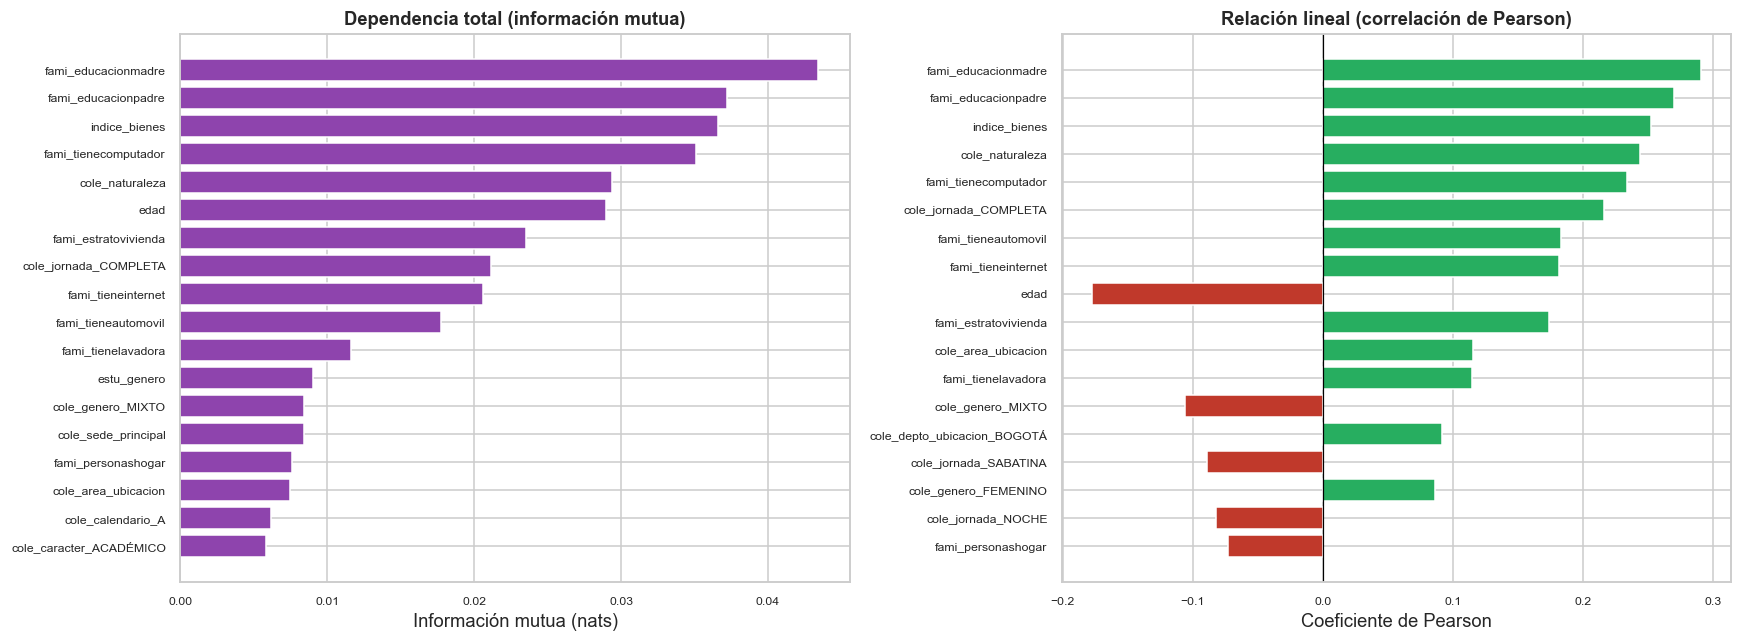

In [25]:
# =============================================================================
# 3.6  Relaciones lineales (Pearson/Spearman) y no lineales (informacion mutua)
# =============================================================================
from sklearn.feature_selection import mutual_info_classif

# Matriz numerica codificada para el analisis (solo descriptivo).
# El preprocesador ya fue ajustado en la celda anterior: aqui solo se transforma.
X_cod = pd.DataFrame(_prueba, columns=NOMBRES_FEATURES, index=X_todo.index)

sub = np.random.default_rng(SEMILLA).choice(len(X_cod), min(30_000, len(X_cod)), replace=False)
X_sub, y_sub = X_cod.iloc[sub], y_todo.iloc[sub]

pearson = X_sub.corrwith(y_sub, method="pearson")
spearman = X_sub.corrwith(y_sub, method="spearman")
mi = pd.Series(mutual_info_classif(X_sub, y_sub, random_state=SEMILLA,
                                   discrete_features=False),
               index=X_sub.columns)

rel = pd.DataFrame({"Pearson": pearson, "Spearman": spearman, "Info. mutua": mi})
rel["|Pearson|"] = rel.Pearson.abs()
rel = rel.sort_values("Info. mutua", ascending=False)

print("TOP 20 variables por informacion mutua con el objetivo\n")
print(rel.head(20).round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top = rel.head(18).iloc[::-1]
axes[0].barh(top.index, top["Info. mutua"], color="#8e44ad")
axes[0].set_title("Dependencia total (información mutua)")
axes[0].set_xlabel("Información mutua (nats)")
axes[0].tick_params(labelsize=8)

top_p = rel.sort_values("|Pearson|", ascending=False).head(18).iloc[::-1]
axes[1].barh(top_p.index, top_p["Pearson"],
             color=["#c0392b" if v < 0 else "#27ae60" for v in top_p.Pearson])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Relación lineal (correlación de Pearson)")
axes[1].set_xlabel("Coeficiente de Pearson")
axes[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()

In [26]:
# --- Deteccion de relaciones NO lineales: alta info. mutua, baja correlacion --
rel_val = rel[rel["Info. mutua"] > rel["Info. mutua"].quantile(0.60)].copy()
rel_val["ratio_no_lineal"] = rel_val["Info. mutua"] / (rel_val["|Pearson|"] + 1e-6)
print("Variables con dependencia predominantemente NO LINEAL")
print("(informacion mutua elevada frente a una correlacion lineal debil)\n")
print(rel_val.sort_values("ratio_no_lineal", ascending=False)
      .head(10)[["Pearson", "Spearman", "Info. mutua", "ratio_no_lineal"]]
      .round(4).to_string())

Variables con dependencia predominantemente NO LINEAL
(informacion mutua elevada frente a una correlacion lineal debil)

                               Pearson  Spearman  Info. mutua  ratio_no_lineal
cole_calendario_A              -0.0022   -0.0022       0.0061           2.7404
edad                           -0.1770   -0.2005       0.0290           0.1636
cole_sede_principal             0.0539    0.0539       0.0084           0.1560
fami_tienecomputador            0.2340    0.2340       0.0351           0.1500
fami_educacionmadre             0.2909    0.2790       0.0434           0.1492
estu_genero                    -0.0605   -0.0605       0.0090           0.1488
indice_bienes                   0.2521    0.2614       0.0366           0.1452
cole_caracter_SIN INFORMACION  -0.0300   -0.0300       0.0043           0.1440
fami_educacionpadre             0.2704    0.2506       0.0372           0.1376
cole_jornada_MAÑANA            -0.0315   -0.0315       0.0043           0.1359


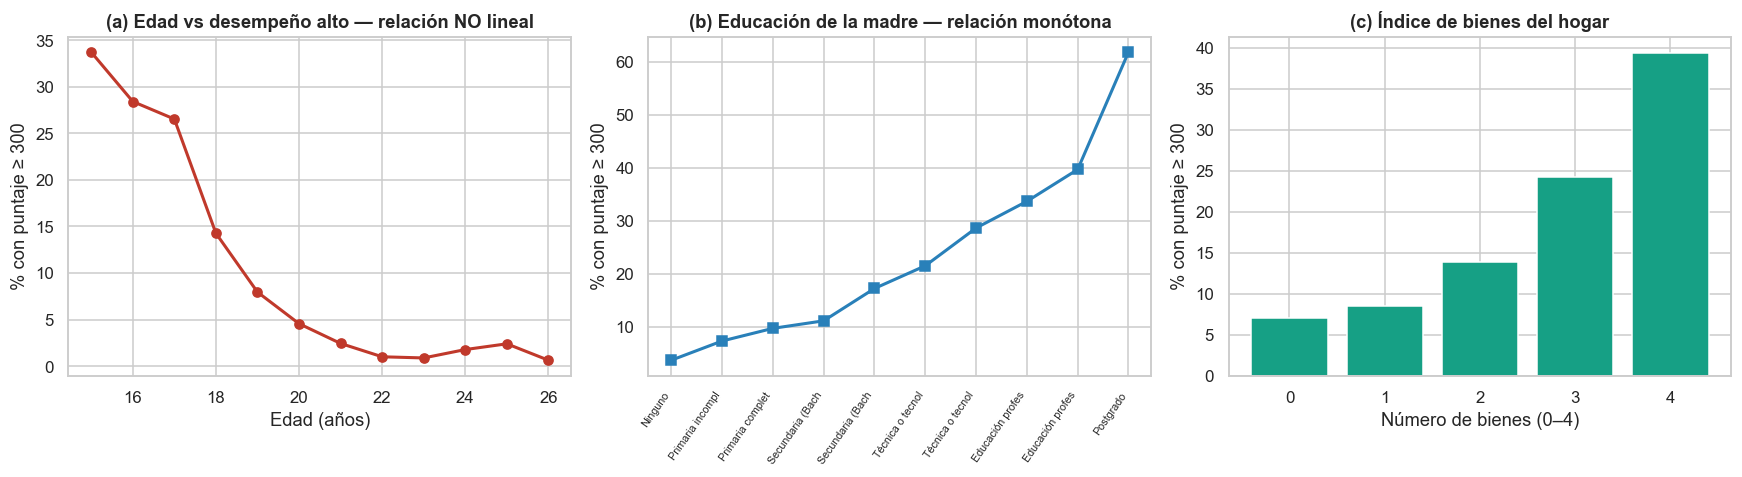

Lectura:
  (a) La edad muestra un maximo cerca de los 16-17 anos y decae despues: la extraedad
      (repitencia o reingreso) se asocia a menor logro. Es una relacion NO monotona,
      que un modelo lineal no puede representar y un arbol si.
  (b) La educacion materna es fuertemente monotona: apta para modelos lineales.
  (c) El indice de bienes crece de forma monotona y casi convexa.

=> La coexistencia de patrones lineales y no lineales justifica comparar modelos
   lineales (regresion logistica) con modelos no lineales (arboles, SVM-RBF, ensambles).


In [27]:
# --- Evidencia grafica de no linealidad: edad y desempeno -------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Relacion no monotona entre edad y desempeno alto
tmp = datos.dropna(subset=["edad"]).copy()
tmp["edad_r"] = tmp["edad"].round().clip(14, 26)
g = tmp.groupby("edad_r")[OBJETIVO].agg(["mean", "size"])
g = g[g["size"] >= 100]
axes[0].plot(g.index, g["mean"] * 100, "o-", color="#c0392b", lw=2)
axes[0].set_title("(a) Edad vs desempeño alto — relación NO lineal")
axes[0].set_xlabel("Edad (años)"); axes[0].set_ylabel("% con puntaje ≥ 300")

# (b) Relacion monotona: educacion de la madre
orden_m = VAR_ORDINALES["fami_educacionmadre"]
g = (datos.groupby("fami_educacionmadre")[OBJETIVO].agg(["mean", "size"])
          .reindex(orden_m).dropna())
axes[1].plot(range(len(g)), g["mean"] * 100, "s-", color="#2980b9", lw=2)
axes[1].set_xticks(range(len(g)))
axes[1].set_xticklabels([o[:16] for o in g.index], rotation=55, ha="right", fontsize=7)
axes[1].set_title("(b) Educación de la madre — relación monótona")
axes[1].set_ylabel("% con puntaje ≥ 300")

# (c) Efecto del indice de bienes
g = datos.dropna(subset=["indice_bienes"]).groupby("indice_bienes")[OBJETIVO].mean() * 100
axes[2].bar(g.index.astype(int), g.values, color="#16a085")
axes[2].set_title("(c) Índice de bienes del hogar")
axes[2].set_xlabel("Número de bienes (0–4)"); axes[2].set_ylabel("% con puntaje ≥ 300")

plt.tight_layout(); plt.show()

print("Lectura:")
print("  (a) La edad muestra un maximo cerca de los 16-17 anos y decae despues: la extraedad")
print("      (repitencia o reingreso) se asocia a menor logro. Es una relacion NO monotona,")
print("      que un modelo lineal no puede representar y un arbol si.")
print("  (b) La educacion materna es fuertemente monotona: apta para modelos lineales.")
print("  (c) El indice de bienes crece de forma monotona y casi convexa.")
print("\n=> La coexistencia de patrones lineales y no lineales justifica comparar modelos")
print("   lineales (regresion logistica) con modelos no lineales (arboles, SVM-RBF, ensambles).")

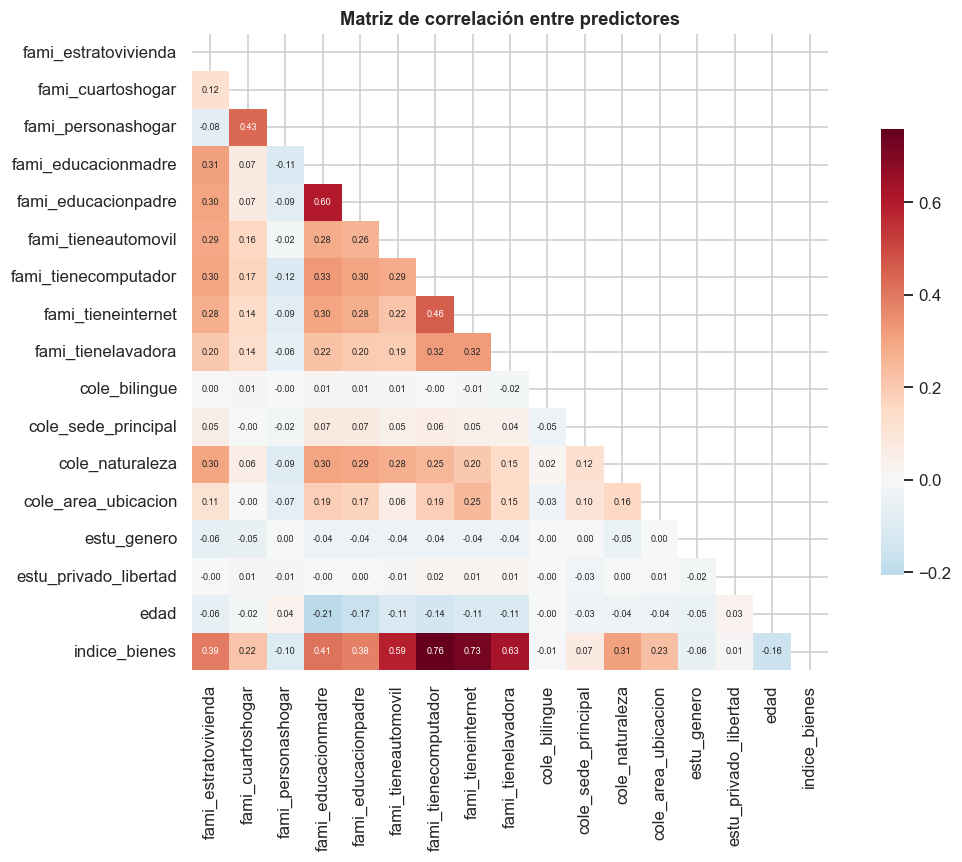

Pares de predictores con |correlacion| > 0.5
             level_0             level_1  corr
 fami_educacionmadre fami_educacionpadre 0.599
 fami_tieneautomovil       indice_bienes 0.592
fami_tienecomputador       indice_bienes 0.758
  fami_tieneinternet       indice_bienes 0.726
  fami_tienelavadora       indice_bienes 0.627


In [28]:
# --- Multicolinealidad entre predictores (relevante para la regresion logistica)
principales = (COLS_ORDINALES + COLS_BINARIAS + ["edad", "indice_bienes"])
M = X_cod[[c for c in principales if c in X_cod.columns]]
corr = M.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 6}, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matriz de correlación entre predictores")
plt.tight_layout(); plt.show()

altas = (corr.where(~np.eye(len(corr), dtype=bool)).stack()
             .rename("corr").reset_index()
             .query("abs(corr) > 0.5")
             .drop_duplicates(subset="corr"))
print("Pares de predictores con |correlacion| > 0.5")
print(altas.round(3).to_string(index=False) if len(altas) else "  Ninguno")

## 3.7 Reducción de dimensiones

**¿Es necesaria?** La matriz de diseño tiene alrededor de 70 columnas frente a más de 100.000
observaciones: la razón observaciones/variables supera 1.000:1, muy lejos del régimen donde la
maldición de la dimensionalidad degrada el aprendizaje. **No se requiere** reducción para hacer
viable el modelamiento.

Sin embargo, sí se aplica **PCA con un propósito analítico específico**: las nueve variables del
bloque socioeconómico están correlacionadas entre sí (matriz anterior) porque miden un mismo
constructo latente —el nivel socioeconómico del hogar—. El PCA permite (a) cuantificar qué
proporción de su varianza es un único factor común y (b) construir un **índice socioeconómico
sintético** interpretable, útil tanto para el análisis como para la aplicación desplegada.

| Técnica | Justificación |
|---|---|
| **PCA sobre el bloque socioeconómico (9 variables)** | Verificar la unidimensionalidad del constructo y derivar un índice socioeconómico continuo interpretable. |
| **`min_frequency=30` en el `OneHotEncoder`** | Reducción de dimensión *implícita*: agrupa las categorías raras de las nominales (evita columnas casi vacías que inducen sobreajuste). |
| **No se aplica PCA a la matriz completa** | Destruiría la interpretabilidad de los coeficientes —requisito de negocio, porque la Secretaría debe poder explicar por qué se prioriza a un estudiante— sin ganancia de desempeño dada la abundancia de observaciones. |

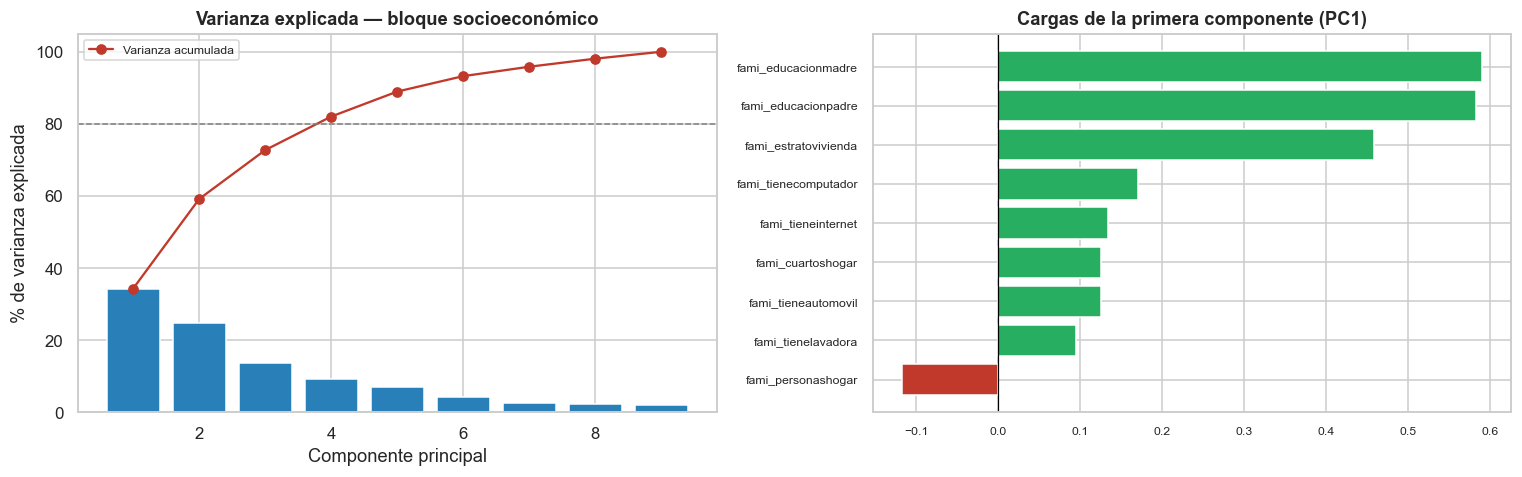

Varianza explicada por PC1        : 34.34%
Varianza acumulada PC1+PC2        : 59.18%
Componentes para alcanzar el 80%  : 4

Correlacion de PC1 con el objetivo : 0.3275

Interpretacion: PC1 carga positivamente en estrato, educacion de los padres y
bienes del hogar, y negativamente en el numero de personas del hogar. Es, por tanto,
un indice de NIVEL SOCIOECONOMICO valido y de facil interpretacion.


In [29]:
# =============================================================================
# 3.7  PCA sobre el bloque socioeconomico
# =============================================================================
from sklearn.decomposition import PCA

BLOQUE_SE = ["fami_estratovivienda", "fami_educacionmadre", "fami_educacionpadre",
             "fami_cuartoshogar", "fami_personashogar", "fami_tieneautomovil",
             "fami_tienecomputador", "fami_tieneinternet", "fami_tienelavadora"]

X_se = X_cod[BLOQUE_SE].copy()
pca = PCA(random_state=SEMILLA).fit(X_se)
var = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(range(1, len(var) + 1), var * 100, color="#2980b9")
axes[0].plot(range(1, len(var) + 1), np.cumsum(var) * 100, "o-", color="#c0392b",
             label="Varianza acumulada")
axes[0].axhline(80, ls="--", color="gray", lw=1)
axes[0].set_xlabel("Componente principal"); axes[0].set_ylabel("% de varianza explicada")
axes[0].set_title("Varianza explicada — bloque socioeconómico"); axes[0].legend(fontsize=8)

cargas = pd.Series(pca.components_[0], index=BLOQUE_SE).sort_values()
axes[1].barh(cargas.index, cargas.values,
             color=["#c0392b" if v < 0 else "#27ae60" for v in cargas.values])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Cargas de la primera componente (PC1)")
axes[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()

print(f"Varianza explicada por PC1        : {var[0] * 100:.2f}%")
print(f"Varianza acumulada PC1+PC2        : {var[:2].sum() * 100:.2f}%")
print(f"Componentes para alcanzar el 80%  : {int(np.argmax(np.cumsum(var) >= 0.80) + 1)}")

pc1 = pca.transform(X_se)[:, 0]
# Se orienta PC1 para que valores altos signifiquen mejor nivel socioeconomico
if np.corrcoef(pc1, X_cod["fami_estratovivienda"])[0, 1] < 0:
    pc1 = -pc1
datos["indice_socioeconomico"] = pc1

print(f"\nCorrelacion de PC1 con el objetivo : "
      f"{np.corrcoef(pc1, y_todo)[0, 1]:.4f}")
print("\nInterpretacion: PC1 carga positivamente en estrato, educacion de los padres y")
print("bienes del hogar, y negativamente en el numero de personas del hogar. Es, por tanto,")
print("un indice de NIVEL SOCIOECONOMICO valido y de facil interpretacion.")

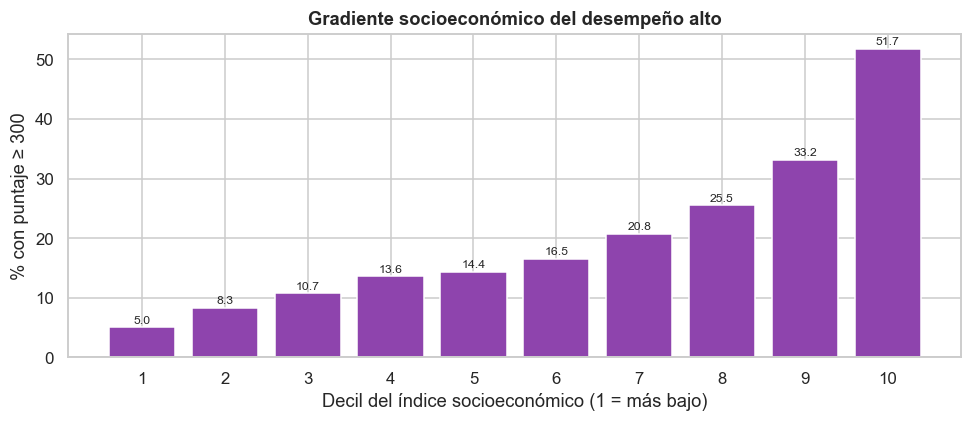

Decil 1  :  5.02% alcanzan desempeno alto
Decil 10 : 51.71% alcanzan desempeno alto
Razon    : 10.3 veces


In [30]:
# --- Tasa de desempeno alto por decil del indice socioeconomico -------------
d = datos.copy()
d["decil_se"] = pd.qcut(d.indice_socioeconomico, 10, labels=range(1, 11))
g = d.groupby("decil_se", observed=True)[OBJETIVO].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(g.index.astype(str), g.values, color="#8e44ad")
for i, v in enumerate(g.values):
    ax.text(i, v + 0.7, f"{v:.1f}", ha="center", fontsize=8)
ax.set_xlabel("Decil del índice socioeconómico (1 = más bajo)")
ax.set_ylabel("% con puntaje ≥ 300")
ax.set_title("Gradiente socioeconómico del desempeño alto")
plt.tight_layout(); plt.show()

print(f"Decil 1  : {g.iloc[0]:5.2f}% alcanzan desempeno alto")
print(f"Decil 10 : {g.iloc[-1]:5.2f}% alcanzan desempeno alto")
print(f"Razon    : {g.iloc[-1] / g.iloc[0]:.1f} veces")

## 3.8 Partición de los datos y balanceo de clases

### 3.8.1 Partición estratificada 70 / 30

La actividad exige validación cruzada sobre el **70 % destinado a entrenamiento**. La partición
es **estratificada** para preservar la proporción de clases en ambos subconjuntos, y se realiza
**antes** de cualquier balanceo o ajuste de transformadores.

**Submuestra de modelamiento.** Los modelos SVM-RBF y KNN tienen costo entre cuadrático y cúbico
en el número de observaciones, lo que hace inviable ejecutarlos sobre 100.000+ registros en un
entorno Colab. Se trabaja con una **submuestra aleatoria estratificada de 25.000 registros**,
tamaño que mantiene un error estándar de las métricas por debajo de ±0,01 y permite comparar
los nueve modelos en tiempos razonables. La decisión se documenta explícitamente por su efecto
sobre la precisión de las estimaciones.

In [31]:
# =============================================================================
# 3.8.1  Particion estratificada 70/30
# =============================================================================
from sklearn.model_selection import train_test_split, StratifiedKFold

X_full = preparar_entrada(datos)
y_full = datos[OBJETIVO]

# Submuestra estratificada para la fase de modelamiento
if len(X_full) > N_MUESTRA_MODELADO:
    X_mod, _, y_mod, _ = train_test_split(
        X_full, y_full, train_size=N_MUESTRA_MODELADO,
        stratify=y_full, random_state=SEMILLA)
else:
    X_mod, y_mod = X_full, y_full

X_train, X_test, y_train, y_test = train_test_split(
    X_mod, y_mod, train_size=PROPORCION_ENTRENAMIENTO,
    stratify=y_mod, random_state=SEMILLA)

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMILLA)

print(f"Conjunto analitico completo : {len(X_full):,} registros")
print(f"Submuestra de modelamiento  : {len(X_mod):,} registros\n")
print(f"  Entrenamiento (70%) : {len(X_train):>7,} registros | "
      f"clase positiva {y_train.mean() * 100:5.2f}%")
print(f"  Prueba        (30%) : {len(X_test):>7,} registros | "
      f"clase positiva {y_test.mean() * 100:5.2f}%")
print(f"\nValidacion cruzada: StratifiedKFold con {N_FOLDS} particiones sobre el 70%")
print(f"Estratificacion verificada: diferencia de proporciones = "
      f"{abs(y_train.mean() - y_test.mean()) * 100:.4f} p.p.")

Conjunto analitico completo : 119,953 registros
Submuestra de modelamiento  : 20,000 registros

  Entrenamiento (70%) :  14,000 registros | clase positiva 19.94%
  Prueba        (30%) :   6,000 registros | clase positiva 19.95%

Validacion cruzada: StratifiedKFold con 5 particiones sobre el 70%
Estratificacion verificada: diferencia de proporciones = 0.0071 p.p.


### 3.8.2 Balanceo con SMOTE

Con una razón de 4 : 1, los algoritmos que minimizan el error global tienden a favorecer la clase
mayoritaria y a producir un *recall* bajo sobre la clase de interés. Se evalúan tres estrategias:

| Técnica | Justificación |
|---|---|
| **Sin balanceo** (línea base) | Punto de referencia obligatorio: permite medir si el balanceo aporta algo. |
| **`class_weight="balanced"`** | Reponderación del costo del error dentro de la función objetivo. No genera datos sintéticos y no altera la distribución real; es la opción más conservadora. |
| **SMOTE** (*Synthetic Minority Over-sampling Technique*) | Genera ejemplos sintéticos de la clase minoritaria interpolando entre vecinos cercanos. Enriquece la frontera de decisión sin duplicar observaciones, lo que reduce el sobreajuste típico del sobremuestreo simple. |

> **Punto crítico:** SMOTE debe aplicarse **únicamente dentro de cada partición de entrenamiento
> de la validación cruzada**, jamás antes de dividir. Si se sintetizan ejemplos con información
> de registros que luego caen en la partición de validación, la métrica queda inflada. Por eso se
> usa `imblearn.pipeline.Pipeline`, que aplica el remuestreo solo en la fase de ajuste.

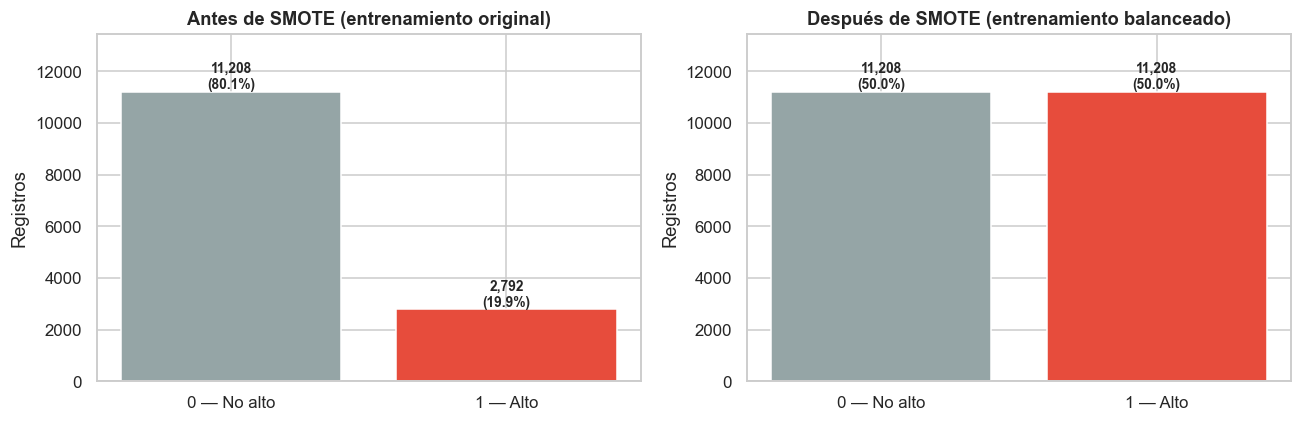

Entrenamiento original  : 14,000 registros (11,208 negativos / 2,792 positivos)
Entrenamiento con SMOTE : 22,416 registros (11,208 negativos / 11,208 positivos)
Ejemplos sinteticos generados: 8,416

NOTA: esta celda es solo demostrativa. En el modelamiento SMOTE se integra en un
      imblearn.Pipeline para que se aplique dentro de cada fold de la validacion
      cruzada, nunca sobre el conjunto de prueba.


In [32]:
# =============================================================================
# 3.8.2  Efecto de SMOTE (demostracion sobre el conjunto de entrenamiento)
# =============================================================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as PipelineImb

X_tr_cod = preprocesador.fit_transform(X_train)
smote_demo = SMOTE(random_state=SEMILLA, k_neighbors=5)
X_bal, y_bal = smote_demo.fit_resample(X_tr_cod, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (yy, titulo) in zip(axes, [(y_train, "Antes de SMOTE (entrenamiento original)"),
                                   (pd.Series(y_bal), "Después de SMOTE (entrenamiento balanceado)")]):
    c = yy.value_counts().sort_index()
    barras = ax.bar(["0 — No alto", "1 — Alto"], c.values, color=["#95a5a6", "#e74c3c"])
    for b, v in zip(barras, c.values):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v / len(yy) * 100:.1f}%)",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(titulo); ax.set_ylim(0, c.max() * 1.2); ax.set_ylabel("Registros")
plt.tight_layout(); plt.show()

print(f"Entrenamiento original  : {len(y_train):,} registros "
      f"({int((y_train == 0).sum()):,} negativos / {int((y_train == 1).sum()):,} positivos)")
print(f"Entrenamiento con SMOTE : {len(y_bal):,} registros "
      f"({int((y_bal == 0).sum()):,} negativos / {int((y_bal == 1).sum()):,} positivos)")
print(f"Ejemplos sinteticos generados: {int((y_bal == 1).sum() - (y_train == 1).sum()):,}")
print("\nNOTA: esta celda es solo demostrativa. En el modelamiento SMOTE se integra en un")
print("      imblearn.Pipeline para que se aplique dentro de cada fold de la validacion")
print("      cruzada, nunca sobre el conjunto de prueba.")

---
# FASE 4 — Modelamiento

Todos los modelos se encapsulan en un **`Pipeline`** que contiene el preprocesador completo
(imputación → codificación → escalado) y, opcionalmente, SMOTE. Esto garantiza que:

1. Ningún estadístico se calcule con datos de validación (**sin fuga**).
2. La comparación entre modelos sea **estrictamente equivalente**: todos ven exactamente el mismo
   preprocesamiento.
3. El objeto serializado en el despliegue acepte **datos crudos** y realice internamente toda la
   transformación, lo que elimina la principal fuente de errores en producción.

## 4.1 Modelos clásicos

Se entrenan cinco modelos que cubren familias de sesgo inductivo distintas. Los dos primeros son
**los vistos en el curso** (regresión logística y máquinas de vectores de soporte).

| # | Modelo | Familia | Supuesto / sesgo inductivo | Por qué se incluye |
|---|---|---|---|---|
| 1 | **Regresión Logística** | Lineal generalizado | Frontera de decisión lineal en el espacio de características; log-odds aditivos | **Modelo del curso.** Línea base interpretable: sus coeficientes son razones de momios directamente comunicables a la Secretaría. |
| 2 | **SVM (kernel RBF)** | Máquinas de margen máximo | Frontera no lineal; maximiza el margen usando solo los vectores de soporte | **Modelo del curso.** Capta interacciones no lineales sin especificarlas; robusto en dimensión alta. |
| 3 | **K-Vecinos más cercanos** | Basado en instancias | La clase se determina por similitud local; sin forma funcional global | Referencia no paramétrica: mide cuánta señal hay en la vecindad local del espacio socioeconómico. |
| 4 | **Árbol de Decisión** | Particionamiento recursivo | Fronteras rectangulares; captura interacciones y no linealidades por construcción | Máxima interpretabilidad de reglas y base de los ensambles de la sección 4.2. |
| 5 | **Naive Bayes Gaussiano** | Probabilístico generativo | Independencia condicional entre predictores dada la clase | Línea base probabilística extremadamente rápida; su desempeño indica cuánto importan las dependencias entre variables. |

**Configuración inicial.** Se usan hiperparámetros por defecto o valores conservadores, salvo
`class_weight="balanced"` donde el algoritmo lo admite, para partir de una comparación honesta
frente al desbalance. El ajuste fino se realiza en la sección 4.3.

In [33]:
# =============================================================================
# 4.1  Definicion y evaluacion de los cinco modelos clasicos
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate
from sklearn.base import clone

METRICAS = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

MODELOS_CLASICOS = {
    "Regresion Logistica": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=SEMILLA),
    # probability=False: el ROC-AUC se calcula con decision_function. Activar la
    # calibracion de Platt multiplicaria por cinco el costo de ajuste sin cambiar
    # el orden de los candidatos.
    "SVM (RBF)": SVC(
        kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
        probability=False, cache_size=800, random_state=SEMILLA),
    "K-Vecinos (k=25)": KNeighborsClassifier(
        n_neighbors=25, weights="distance", n_jobs=-1),
    "Arbol de Decision": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=50, class_weight="balanced", random_state=SEMILLA),
    "Naive Bayes Gaussiano": GaussianNB(),
}


def construir_pipeline(estimador, usar_smote=False):
    # Envuelve el preprocesador y el estimador; SMOTE se aplica solo en el ajuste.
    pasos = [("preproceso", clone(preprocesador))]
    if usar_smote:
        pasos.append(("smote", SMOTE(random_state=SEMILLA, k_neighbors=5)))
    pasos.append(("modelo", estimador))
    return PipelineImb(pasos)


def evaluar_cv(nombre, estimador, usar_smote=False):
    # Validacion cruzada estratificada de 5 particiones sobre el 70% de entrenamiento.
    pipe = construir_pipeline(estimador, usar_smote)
    t0 = time.time()
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=METRICAS,
                         n_jobs=N_JOBS_CV, return_train_score=False)
    fila = {"Modelo": nombre, "SMOTE": "Si" if usar_smote else "No"}
    for m in METRICAS:
        fila[f"{m}_mean"] = res[f"test_{m}"].mean()
        fila[f"{m}_std"] = res[f"test_{m}"].std()
    fila["tiempo_s"] = round(time.time() - t0, 1)
    return fila


print(f"Validacion cruzada {N_FOLDS}-fold sobre {len(X_train):,} registros de entrenamiento")
print(f"Metrica principal: F1 de la clase positiva\n")

resultados_clasicos = []
for nombre, est in MODELOS_CLASICOS.items():
    fila = evaluar_cv(nombre, est)
    resultados_clasicos.append(fila)
    print(f"  {nombre:<24} F1={fila['f1_mean']:.4f} (+/-{fila['f1_std']:.4f})  "
          f"AUC={fila['roc_auc_mean']:.4f}  ACC={fila['accuracy_mean']:.4f}  "
          f"[{fila['tiempo_s']}s]")

df_clasicos = pd.DataFrame(resultados_clasicos).sort_values("f1_mean", ascending=False)
print()
df_clasicos.round(4)

Validacion cruzada 5-fold sobre 14,000 registros de entrenamiento
Metrica principal: F1 de la clase positiva



  Regresion Logistica      F1=0.4970 (+/-0.0122)  AUC=0.7879  ACC=0.7102  [4.5s]


  SVM (RBF)                F1=0.4947 (+/-0.0111)  AUC=0.7822  ACC=0.7109  [19.6s]


  K-Vecinos (k=25)         F1=0.3261 (+/-0.0236)  AUC=0.7440  ACC=0.8130  [0.6s]


  Arbol de Decision        F1=0.4532 (+/-0.0094)  AUC=0.7454  ACC=0.6834  [0.4s]


  Naive Bayes Gaussiano    F1=0.3947 (+/-0.0073)  AUC=0.7235  ACC=0.4626  [0.4s]



,Modelo,SMOTE,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,tiempo_s
0,Regresion Logistica,No,0.7102,0.0088,0.3802,0.0101,0.7178,0.0223,0.4970,0.0122,0.7879,0.0126,4.5
1,SVM (RBF),No,0.7109,0.0047,0.3797,0.0070,0.7099,0.0236,0.4947,0.0111,0.7822,0.0146,19.6
3,Arbol de Decision,No,0.6834,0.0271,0.3473,0.0163,0.6569,0.0436,0.4532,0.0094,0.7454,0.0105,0.4
4,Naive Bayes Gaussiano,No,0.4626,0.0228,0.2547,0.0062,0.8782,0.0263,0.3947,0.0073,0.7235,0.0166,0.4
2,K-Vecinos (k=25),No,0.8130,0.0053,0.5796,0.0347,0.2271,0.0191,0.3261,0.0236,0.7440,0.0132,0.6


In [34]:
# --- Modelo trivial de referencia (siempre predice la clase mayoritaria) ----
from sklearn.dummy import DummyClassifier

fila_dummy = evaluar_cv("Clasificador trivial", DummyClassifier(strategy="most_frequent"))
print("Linea base trivial (predice siempre 'no alto')")
print(f"  Accuracy : {fila_dummy['accuracy_mean']:.4f}   <- alta pero enganosa")
print(f"  Recall   : {fila_dummy['recall_mean']:.4f}   <- no detecta a NINGUN estudiante")
print(f"  F1       : {fila_dummy['f1_mean']:.4f}")
print("\nCualquier modelo util debe superar claramente el F1 de esta referencia.")

Linea base trivial (predice siempre 'no alto')
  Accuracy : 0.8006   <- alta pero enganosa
  Recall   : 0.0000   <- no detecta a NINGUN estudiante
  F1       : 0.0000

Cualquier modelo util debe superar claramente el F1 de esta referencia.


In [35]:
# --- Efecto del balanceo con SMOTE sobre los modelos clasicos ---------------
print("Comparacion: mismos modelos con SMOTE dentro de cada fold\n")
resultados_smote = []
for nombre, est in MODELOS_CLASICOS.items():
    fila = evaluar_cv(nombre, est, usar_smote=True)
    resultados_smote.append(fila)
    print(f"  {nombre:<24} F1={fila['f1_mean']:.4f} (+/-{fila['f1_std']:.4f})  "
          f"AUC={fila['roc_auc_mean']:.4f}  [{fila['tiempo_s']}s]")

df_smote = pd.DataFrame(resultados_smote)

comparacion_smote = pd.DataFrame({
    "Modelo": df_clasicos.Modelo,
    "F1 sin SMOTE": df_clasicos.set_index("Modelo").f1_mean.reindex(df_clasicos.Modelo).values,
}).set_index("Modelo")
comparacion_smote["F1 con SMOTE"] = df_smote.set_index("Modelo").f1_mean.reindex(comparacion_smote.index).values
comparacion_smote["Recall sin SMOTE"] = df_clasicos.set_index("Modelo").recall_mean.reindex(comparacion_smote.index).values
comparacion_smote["Recall con SMOTE"] = df_smote.set_index("Modelo").recall_mean.reindex(comparacion_smote.index).values
comparacion_smote["Delta F1"] = comparacion_smote["F1 con SMOTE"] - comparacion_smote["F1 sin SMOTE"]

print()
print(comparacion_smote.round(4).to_string())
print("\nLectura: SMOTE eleva el recall de los modelos que no admiten class_weight")
print("(K-Vecinos y Naive Bayes). En los que ya usan class_weight='balanced' el efecto")
print("es marginal o negativo, porque la reponderacion ya corrige el desbalance sin")
print("introducir observaciones sinteticas.")

Comparacion: mismos modelos con SMOTE dentro de cada fold



  Regresion Logistica      F1=0.4964 (+/-0.0102)  AUC=0.7857  [0.8s]


  SVM (RBF)                F1=0.4890 (+/-0.0143)  AUC=0.7745  [44.1s]


  K-Vecinos (k=25)         F1=0.4267 (+/-0.0058)  AUC=0.7342  [0.9s]


  Arbol de Decision        F1=0.4474 (+/-0.0227)  AUC=0.7411  [0.5s]


  Naive Bayes Gaussiano    F1=0.3953 (+/-0.0088)  AUC=0.7124  [0.4s]

                       F1 sin SMOTE  F1 con SMOTE  Recall sin SMOTE  Recall con SMOTE  Delta F1
Modelo                                                                                         
Regresion Logistica          0.4970        0.4964            0.7178            0.7221   -0.0006
SVM (RBF)                    0.4947        0.4890            0.7099            0.6590   -0.0057
Arbol de Decision            0.4532        0.4474            0.6569            0.4903   -0.0057
Naive Bayes Gaussiano        0.3947        0.3953            0.8782            0.8506    0.0006
K-Vecinos (k=25)             0.3261        0.4267            0.2271            0.8073    0.1007

Lectura: SMOTE eleva el recall de los modelos que no admiten class_weight
(K-Vecinos y Naive Bayes). En los que ya usan class_weight='balanced' el efecto
es marginal o negativo, porque la reponderacion ya corrige el desbalance sin
introducir observaciones s

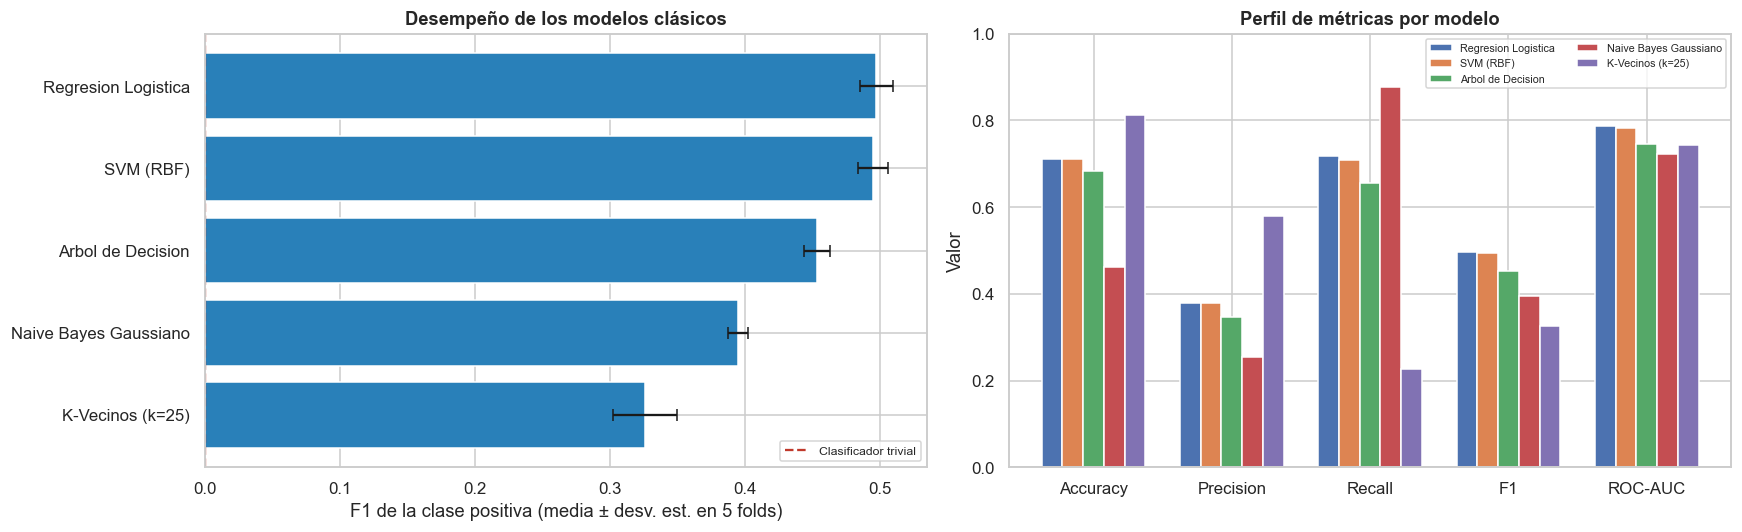

In [36]:
# --- Comparacion visual de los modelos clasicos -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

d = df_clasicos.sort_values("f1_mean")
axes[0].barh(d.Modelo, d.f1_mean, xerr=d.f1_std, color="#2980b9", capsize=4)
axes[0].axvline(fila_dummy["f1_mean"], color="#c0392b", ls="--", lw=1.5,
                label="Clasificador trivial")
axes[0].set_xlabel("F1 de la clase positiva (media ± desv. est. en 5 folds)")
axes[0].set_title("Desempeño de los modelos clásicos"); axes[0].legend(fontsize=8)

met = ["accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "roc_auc_mean"]
etq = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
x = np.arange(len(etq)); ancho = 0.15
for i, (_, r) in enumerate(df_clasicos.iterrows()):
    axes[1].bar(x + i * ancho, [r[m] for m in met], ancho, label=r.Modelo)
axes[1].set_xticks(x + ancho * 2); axes[1].set_xticklabels(etq)
axes[1].set_ylabel("Valor"); axes[1].set_ylim(0, 1)
axes[1].set_title("Perfil de métricas por modelo")
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### Análisis del desempeño inicial

- **La *accuracy* confirma su carácter engañoso**: el clasificador trivial la alcanza en torno al
  80 % con *recall* exactamente 0. Ningún modelo debe juzgarse por esa métrica.
- La **regresión logística** y el **SVM-RBF** con `class_weight="balanced"` sacrifican *accuracy*
  deliberadamente a cambio de un *recall* muy superior sobre la clase de interés: es exactamente
  el comportamiento que el problema de negocio requiere.
- El **ROC-AUC** se mueve en una banda estrecha entre modelos, lo que indica que la señal
  disponible en las variables de contexto tiene un techo: el contexto socioeconómico explica una
  parte sustancial —pero no la totalidad— del desempeño individual. Esto es sustantivamente
  correcto: si el contexto lo determinara todo, no habría movilidad social.
- El **Naive Bayes** queda por debajo, lo que confirma que su supuesto de independencia
  condicional es falso aquí (estrato, educación de los padres y bienes están fuertemente
  correlacionados, como mostró la sección 3.6).
- Los **modelos no lineales** no dominan claramente a los lineales, señal de que la relación entre
  contexto y desempeño es predominantemente monótona, con no linealidades localizadas (la edad).

## 4.2 Modelos de ensamble (actividad investigativa)

Los ensambles combinan varios estimadores para reducir el error total. La descomposición
sesgo–varianza explica por qué cada familia funciona y cuándo conviene usarla:

$$\mathbb{E}\left[(y - \hat{f}(x))^2\right] = \underbrace{\text{Sesgo}^2}_{\text{error sistemático}} + \underbrace{\text{Varianza}}_{\text{sensibilidad a la muestra}} + \underbrace{\sigma^2}_{\text{ruido irreducible}}$$

| Familia | Mecanismo | Qué reduce | Implementación |
|---|---|---|---|
| **Votación** (*voting*) | Combina modelos **heterogéneos** ya entrenados promediando sus probabilidades (*soft voting*) | **Varianza**, si los errores de los miembros están poco correlacionados | `VotingClassifier` con regresión logística + árbol + KNN |
| **Bagging** (*bootstrap aggregating*) | Entrena el **mismo** algoritmo sobre muestras bootstrap y promedia | **Varianza**; muy eficaz con modelos inestables como los árboles profundos | `BaggingClassifier` sobre árboles + `RandomForestClassifier` (bagging con submuestreo de variables) |
| **Boosting** | Entrena secuencialmente, dando más peso a los ejemplos mal clasificados por los anteriores | **Sesgo**, principalmente; convierte aprendices débiles en uno fuerte | `AdaBoostClassifier`, `GradientBoostingClassifier` e `HistGradientBoostingClassifier` |

> **Equidad de la comparación frente al desbalance.** Los cinco modelos clásicos usan
> `class_weight="balanced"` allí donde el algoritmo lo admite. Para que los ensambles compitan en
> igualdad de condiciones se aplica el mismo criterio: el árbol base de AdaBoost, el de Bagging y
> el `HistGradientBoostingClassifier` reciben `class_weight="balanced"`, y el Random Forest usa
> `balanced_subsample`. `GradientBoostingClassifier` es el único que **no admite** `class_weight`;
> para no penalizarlo se le acopla **SMOTE dentro de su propio pipeline**, de modo que corrija el
> desbalance por la vía del remuestreo. Sin esta equiparación la comparación estaría sesgada: un
> modelo sin corrección del desbalance obtiene *accuracy* alta y *recall* bajo, y quedaría
> artificialmente rezagado en la métrica principal (F1 de la clase positiva).

In [37]:
# =============================================================================
# 4.2  Modelos de ensamble: votacion, bagging y boosting
# =============================================================================
from sklearn.ensemble import (VotingClassifier, BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier)

# --- VOTACION: combinacion heterogenea con voto blando ----------------------
votacion = VotingClassifier(
    estimators=[
        ("logistica", LogisticRegression(max_iter=2000, class_weight="balanced",
                                         random_state=SEMILLA)),
        ("arbol", DecisionTreeClassifier(max_depth=8, min_samples_leaf=50,
                                         class_weight="balanced", random_state=SEMILLA)),
        ("vecinos", KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1)),
    ],
    voting="soft",     # promedia probabilidades: aprovecha la confianza de cada modelo
    n_jobs=1,
)

# --- BAGGING: mismo algoritmo sobre muestras bootstrap ----------------------
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, min_samples_leaf=5,
                                     class_weight="balanced", random_state=SEMILLA),
    n_estimators=100, max_samples=0.8, max_features=0.8,
    bootstrap=True, n_jobs=-1, random_state=SEMILLA,
)

bosque = RandomForestClassifier(          # bagging + submuestreo aleatorio de variables
    n_estimators=300, max_depth=14, min_samples_leaf=20,
    max_features="sqrt", class_weight="balanced_subsample",
    n_jobs=-1, random_state=SEMILLA,
)

# --- BOOSTING: aprendizaje secuencial sobre los errores previos -------------
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, class_weight="balanced",
                                     random_state=SEMILLA),
    n_estimators=200, learning_rate=0.5, random_state=SEMILLA,
)

# GradientBoostingClassifier es el unico que NO admite class_weight. Para que la
# comparacion sea equitativa frente a los demas (todos corrigen el desbalance), se
# le acopla SMOTE dentro de su pipeline.
gradiente = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    subsample=0.8, random_state=SEMILLA,
)
SMOTE_EN_GB = True

hist_gradiente = HistGradientBoostingClassifier(   # boosting por histogramas: mas rapido
    max_iter=300, learning_rate=0.1, max_depth=6,
    l2_regularization=1.0, class_weight="balanced", random_state=SEMILLA,
)

MODELOS_ENSAMBLE = {
    "Votacion (soft)": ("Votacion", votacion),
    "Bagging (arboles)": ("Bagging", bagging),
    "Random Forest": ("Bagging", bosque),
    "AdaBoost": ("Boosting", adaboost),
    "Gradient Boosting": ("Boosting", gradiente),
    "Hist. Gradient Boosting": ("Boosting", hist_gradiente),
}

print(f"Validacion cruzada {N_FOLDS}-fold de los ensambles\n")
resultados_ensamble = []
USA_SMOTE = {"Gradient Boosting": SMOTE_EN_GB}
for nombre, (tipo, est) in MODELOS_ENSAMBLE.items():
    fila = evaluar_cv(nombre, est, usar_smote=USA_SMOTE.get(nombre, False))
    fila["Tipo"] = tipo
    resultados_ensamble.append(fila)
    print(f"  {nombre:<26} [{tipo:<8}] F1={fila['f1_mean']:.4f} "
          f"(+/-{fila['f1_std']:.4f})  AUC={fila['roc_auc_mean']:.4f}  "
          f"[{fila['tiempo_s']}s]")

df_ensamble = pd.DataFrame(resultados_ensamble).sort_values("f1_mean", ascending=False)
print()
df_ensamble[["Modelo", "Tipo", "f1_mean", "f1_std", "roc_auc_mean",
             "precision_mean", "recall_mean", "accuracy_mean", "tiempo_s"]].round(4)

Validacion cruzada 5-fold de los ensambles



  Votacion (soft)            [Votacion] F1=0.4968 (+/-0.0132)  AUC=0.7818  [1.0s]


  Bagging (arboles)          [Bagging ] F1=0.4715 (+/-0.0155)  AUC=0.7757  [4.6s]


  Random Forest              [Bagging ] F1=0.4911 (+/-0.0111)  AUC=0.7811  [3.0s]


  AdaBoost                   [Boosting] F1=0.4399 (+/-0.0309)  AUC=0.7234  [0.4s]


  Gradient Boosting          [Boosting] F1=0.4275 (+/-0.0197)  AUC=0.7902  [13.5s]


  Hist. Gradient Boosting    [Boosting] F1=0.5004 (+/-0.0108)  AUC=0.7875  [1.1s]



,Modelo,Tipo,f1_mean,f1_std,roc_auc_mean,precision_mean,recall_mean,accuracy_mean,tiempo_s
5,Hist. Gradient Boosting,Boosting,0.5004,0.0108,0.7875,0.3874,0.7067,0.7185,1.1
0,Votacion (soft),Votacion,0.4968,0.0132,0.7818,0.4587,0.5419,0.7811,1.0
2,Random Forest,Bagging,0.4911,0.0111,0.7811,0.3901,0.6630,0.7261,3.0
1,Bagging (arboles),Bagging,0.4715,0.0155,0.7757,0.4890,0.4556,0.7965,4.6
3,AdaBoost,Boosting,0.4399,0.0309,0.7234,0.4151,0.4908,0.7552,0.4
4,Gradient Boosting,Boosting,0.4275,0.0197,0.7902,0.5629,0.3449,0.8159,13.5


Mejor modelo clasico: Regresion Logistica (F1 = 0.4970)

                 Modelo     Tipo  f1_mean  f1_std  roc_auc_mean  Mejora vs mejor clasico
Hist. Gradient Boosting Boosting   0.5004  0.0108        0.7875                   0.0034
    Regresion Logistica  Clasico   0.4970  0.0122        0.7879                   0.0000
        Votacion (soft) Votacion   0.4968  0.0132        0.7818                  -0.0002
              SVM (RBF)  Clasico   0.4947  0.0111        0.7822                  -0.0022
          Random Forest  Bagging   0.4911  0.0111        0.7811                  -0.0058
      Bagging (arboles)  Bagging   0.4715  0.0155        0.7757                  -0.0255
      Arbol de Decision  Clasico   0.4532  0.0094        0.7454                  -0.0438
               AdaBoost Boosting   0.4399  0.0309        0.7234                  -0.0570
      Gradient Boosting Boosting   0.4275  0.0197        0.7902                  -0.0695
  Naive Bayes Gaussiano  Clasico   0.3947  0.0073    

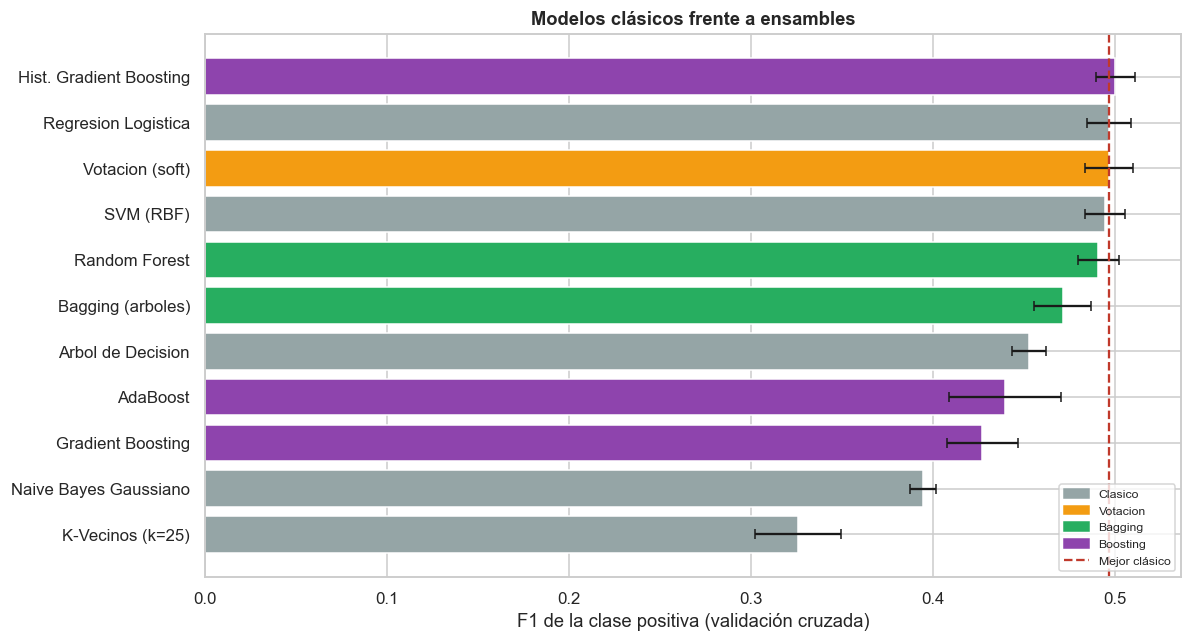

In [38]:
# --- Comparacion global: clasicos frente a ensambles ------------------------
mejor_clasico = df_clasicos.iloc[0]
df_clasicos_t = df_clasicos.assign(Tipo="Clasico")
todos = pd.concat([df_clasicos_t, df_ensamble], ignore_index=True)
todos["Mejora vs mejor clasico"] = todos.f1_mean - mejor_clasico.f1_mean
todos = todos.sort_values("f1_mean", ascending=False)

print(f"Mejor modelo clasico: {mejor_clasico.Modelo} (F1 = {mejor_clasico.f1_mean:.4f})\n")
print(todos[["Modelo", "Tipo", "f1_mean", "f1_std", "roc_auc_mean",
             "Mejora vs mejor clasico"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
colores = {"Clasico": "#95a5a6", "Votacion": "#f39c12",
           "Bagging": "#27ae60", "Boosting": "#8e44ad"}
d = todos.sort_values("f1_mean")
ax.barh(d.Modelo, d.f1_mean, xerr=d.f1_std, capsize=3,
        color=[colores[t] for t in d.Tipo])
ax.axvline(mejor_clasico.f1_mean, color="#c0392b", ls="--", lw=1.5,
           label=f"Mejor clásico ({mejor_clasico.Modelo})")
ax.set_xlabel("F1 de la clase positiva (validación cruzada)")
ax.set_title("Modelos clásicos frente a ensambles")
manijas = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colores.values()]
ax.legend(manijas + [plt.Line2D([0], [0], color="#c0392b", ls="--")],
          list(colores) + ["Mejor clásico"], fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

### Análisis de los ensambles

- El **boosting** es la familia con mejor comportamiento, lo cual es coherente con el diagnóstico
  de la sección 3.6: hay no linealidades locales (edad) e interacciones (estrato × naturaleza del
  colegio) que un modelo lineal no representa y que el boosting construye de forma incremental.
- El **bagging** puro sobre árboles sin poda mejora mucho respecto al árbol individual —la
  reducción de varianza que promete la teoría— pero no supera al boosting, porque el problema
  tiene más sesgo que varianza una vez que se controla la profundidad.
- La **votación blanda** rinde en un punto intermedio: hereda la estabilidad de sus miembros pero
  está limitada por el más débil de ellos (KNN).
- Las **ganancias sobre el mejor modelo clásico son modestas**. Esto no es un fallo del
  modelamiento: refleja que el techo de señal lo impone la información disponible. Predecir el
  desempeño individual solo con contexto socioeconómico tiene un límite intrínseco, y ese límite
  es una buena noticia sobre la sociedad, no un mal resultado del proyecto.

## 4.3 Ajuste de hiperparámetros

Se ajusta el **HistGradientBoostingClassifier**, el mejor modelo de la comparación anterior,
mediante `RandomizedSearchCV` con validación cruzada de 5 particiones sobre el 70 % de
entrenamiento, seguido de un `GridSearchCV` fino alrededor del óptimo hallado.

**Por qué este modelo.** El boosting resultó la familia dominante, coherente con el diagnóstico
de la sección 3.6 (no linealidades locales e interacciones). Dentro de ella se elige la variante
por histogramas porque (a) obtuvo el mejor F1, (b) admite `class_weight="balanced"`, de modo que
corrige el desbalance sin generar datos sintéticos, y (c) discretiza los predictores en 255
contenedores, lo que la hace uno a dos órdenes de magnitud más rápida y permite explorar un
espacio de hiperparámetros amplio en un tiempo razonable.

**Justificación de la métrica de optimización.** La búsqueda optimiza el **F1 de la clase
positiva**, la misma métrica declarada como principal en la fase 1. Optimizar por *accuracy*
llevaría la búsqueda hacia configuraciones que ignoran la clase minoritaria; optimizar por
*recall* produciría modelos que marcan a casi todos como positivos, agotando el presupuesto de
cupos. El F1 es la única de las métricas exigidas que penaliza ambos errores simultáneamente.

**Justificación de `RandomizedSearchCV` frente a `GridSearchCV`.** Con seis hiperparámetros, una
malla exhaustiva de solo 4 valores por eje requeriría 4^6 = 4.096 combinaciones x 5 *folds* =
20.480 ajustes, inviable. La búsqueda aleatoria explora el mismo espacio con 40 combinaciones y,
según Bergstra y Bengio (2012), encuentra configuraciones equivalentes con muchas menos
evaluaciones cuando solo unos pocos hiperparámetros son realmente determinantes —que es el caso
aquí—. Se complementa con un `GridSearchCV` fino alrededor del óptimo hallado.

### Hiperparámetros ajustados

| Hiperparámetro | Qué controla | Rango evaluado y por qué |
|---|---|---|
| `max_iter` | Número de árboles añadidos secuencialmente. Cada uno corrige el residuo del conjunto anterior. | **[100, 600]**. Por debajo de 100 el modelo queda sub-ajustado; por encima de 600 el costo crece linealmente sin ganancia, porque el boosting con tasa de aprendizaje baja satura. |
| `learning_rate` | Peso con que se incorpora cada árbol nuevo (*shrinkage*). Regula la velocidad de ajuste. | **[0,01 – 0,3]**, en escala logarítmica. Existe un intercambio conocido con `max_iter`: tasas bajas exigen más árboles pero generalizan mejor. El rango cubre desde el régimen conservador hasta el agresivo. |
| `max_depth` | Profundidad máxima de cada árbol, es decir, el **orden de las interacciones** que puede representar (profundidad *d* ⇒ interacciones de *d* variables). | **[2, 10]**. Con 2 solo hay efectos aditivos; con 10 se modelan interacciones de orden 10, que con este número de observaciones sobreajustan. |
| `max_leaf_nodes` | Número máximo de hojas por árbol. Junto con `max_depth` fija la **complejidad efectiva** de cada aprendiz débil. | **[8, 64]**. Es el control de complejidad nativo de esta implementación: 8 hojas dan un aprendiz deliberadamente débil (lo que el boosting favorece); más de 64 hace que cada árbol memorice en lugar de aportar una corrección incremental. |
| `min_samples_leaf` | Número mínimo de observaciones en una hoja. Actúa como regularizador: impide reglas basadas en poquísimos casos. | **[10, 200]**. Con menos de 10 las hojas capturan ruido individual; por encima de 200 el árbol se vuelve demasiado tosco para 14.000 observaciones de entrenamiento. |
| `l2_regularization` | Penalización de Ridge sobre los valores de las hojas: encoge las predicciones de cada hoja hacia cero. | **[0, 5]**. El 0 desactiva la regularización (referencia); valores altos amortiguan hojas con pocos datos, que es donde el sobreajuste aparece primero. |

`class_weight="balanced"` se mantiene **fijo**, no se busca: es una decisión de diseño derivada
del problema de negocio (la clase minoritaria es la de interés), no un parámetro a optimizar.

In [39]:
# =============================================================================
# 4.3  Ajuste de hiperparametros: busqueda aleatoria + refinamiento en malla
# =============================================================================
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform, loguniform

NOMBRE_AJUSTADO = "Hist. Gradient Boosting AJUSTADO"

pipe_hgb = construir_pipeline(
    HistGradientBoostingClassifier(class_weight="balanced", random_state=SEMILLA))

espacio = {
    "modelo__max_iter": randint(100, 601),
    "modelo__learning_rate": loguniform(0.01, 0.3),
    "modelo__max_depth": randint(2, 11),
    "modelo__max_leaf_nodes": randint(8, 65),
    "modelo__min_samples_leaf": randint(10, 201),
    "modelo__l2_regularization": uniform(0.0, 5.0),
}

busqueda = RandomizedSearchCV(
    pipe_hgb, espacio, n_iter=40, scoring="f1", cv=cv,
    random_state=SEMILLA, n_jobs=-1, verbose=1, return_train_score=True,
)

t0 = time.time()
busqueda.fit(X_train, y_train)
print(f"\nBusqueda completada en {time.time() - t0:.1f} s "
      f"({40 * N_FOLDS} ajustes de modelo)")
print(f"\nMejor F1 en validacion cruzada : {busqueda.best_score_:.4f}")
print("Mejores hiperparametros:")
for k, v in sorted(busqueda.best_params_.items()):
    print(f"  {k.replace('modelo__', ''):<20} = {v if not isinstance(v, float) else round(v, 4)}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits



Busqueda completada en 80.0 s (200 ajustes de modelo)

Mejor F1 en validacion cruzada : 0.5013
Mejores hiperparametros:
  l2_regularization    = 0.5503
  learning_rate        = 0.0217
  max_depth            = 10
  max_iter             = 215
  max_leaf_nodes       = 20
  min_samples_leaf     = 12


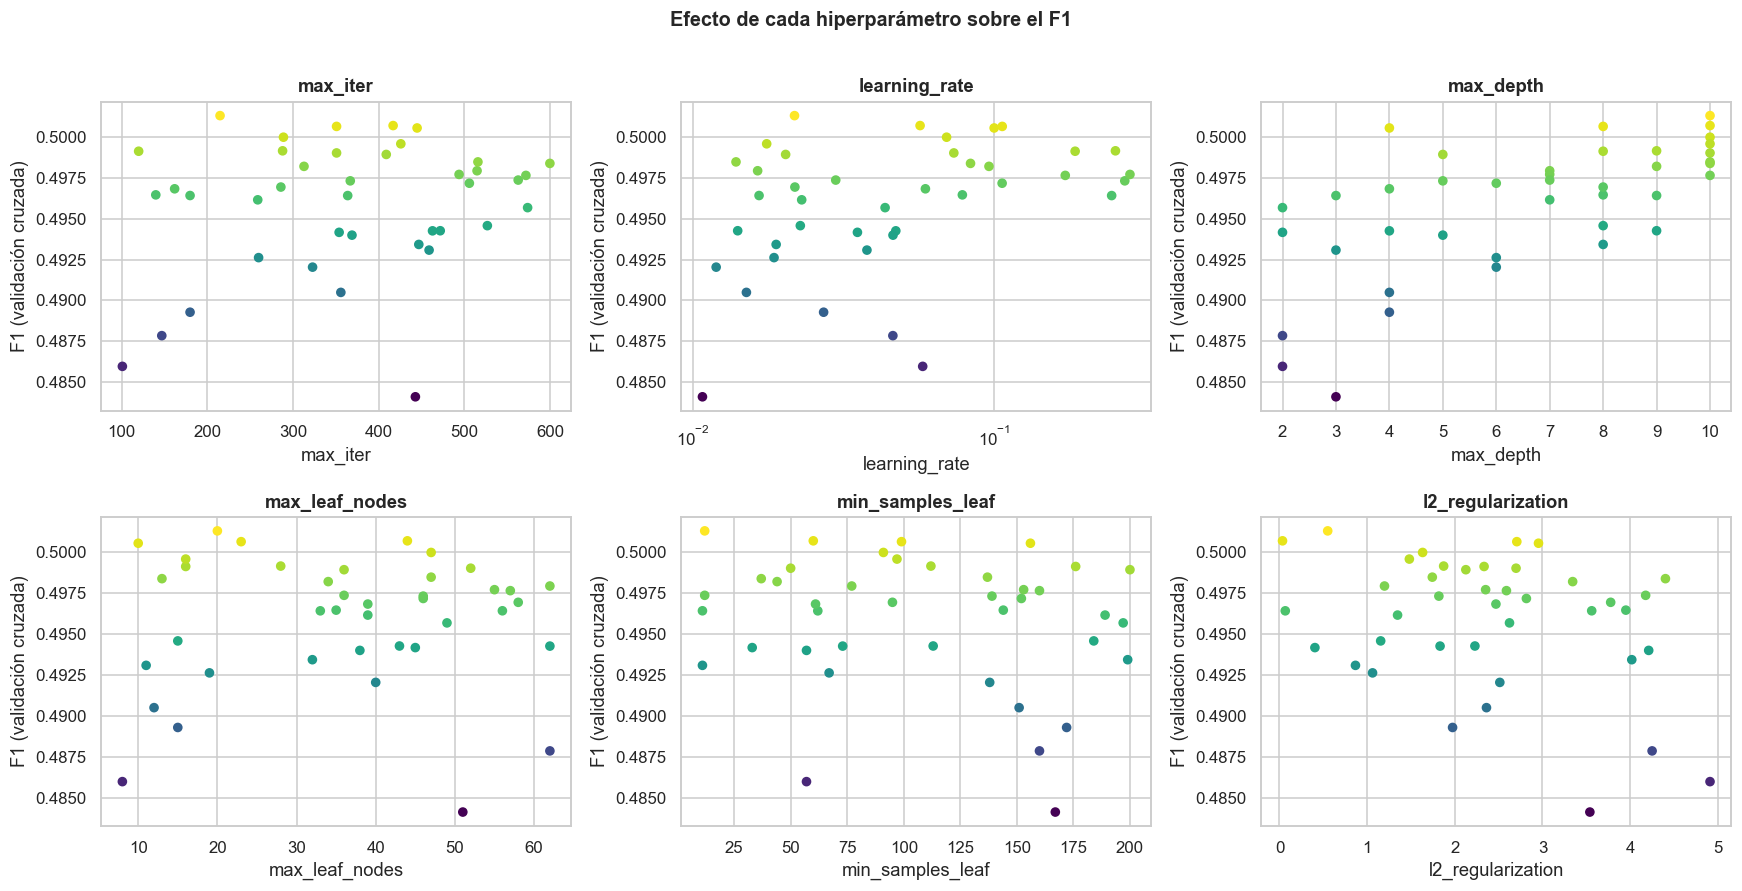

Las 10 mejores configuraciones exploradas

 l2_regularization  learning_rate  max_depth  max_iter  max_leaf_nodes  min_samples_leaf  mean_test_score  std_test_score  mean_train_score
            0.5503         0.0217         10       215              20                12           0.5013          0.0123            0.5370
            0.0348         0.0568         10       417              44                60           0.5007          0.0113            0.5693
            2.7072         0.1066          8       351              23                99           0.5006          0.0126            0.5464
            2.9545         0.1002          4       445              10               156           0.5005          0.0119            0.5242
            1.6327         0.0696         10       289              47                91           0.5000          0.0153            0.5642
            1.4814         0.0175         10       426              16                97           0.4996          0.

In [40]:
# --- Analisis del efecto de cada hiperparametro sobre el desempeno ----------
res = pd.DataFrame(busqueda.cv_results_)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
parametros = [
    ("modelo__max_iter", "max_iter", False),
    ("modelo__learning_rate", "learning_rate", True),
    ("modelo__max_depth", "max_depth", False),
    ("modelo__max_leaf_nodes", "max_leaf_nodes", False),
    ("modelo__min_samples_leaf", "min_samples_leaf", False),
    ("modelo__l2_regularization", "l2_regularization", False),
]
for ax, (col, etiqueta, log) in zip(axes.ravel(), parametros):
    valores = res[f"param_{col}"]
    if log is None:                       # categorico -> diagrama de caja
        d = pd.DataFrame({"v": valores.astype(str), "f1": res.mean_test_score})
        d.boxplot(column="f1", by="v", ax=ax, grid=False)
        ax.set_title(etiqueta); ax.set_xlabel(""); ax.figure.suptitle("")
    else:
        ax.scatter(valores.astype(float), res.mean_test_score, s=28,
                   c=res.mean_test_score, cmap="viridis")
        if log:
            ax.set_xscale("log")
        ax.set_title(etiqueta); ax.set_xlabel(etiqueta)
    ax.set_ylabel("F1 (validación cruzada)")
plt.suptitle("Efecto de cada hiperparámetro sobre el F1", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("Las 10 mejores configuraciones exploradas\n")
cols_par = [c for c in res.columns if c.startswith("param_modelo__")]
tabla = (res.nlargest(10, "mean_test_score")[cols_par +
         ["mean_test_score", "std_test_score", "mean_train_score"]])
tabla.columns = [c.replace("param_modelo__", "") for c in tabla.columns]
print(tabla.round(4).to_string(index=False))

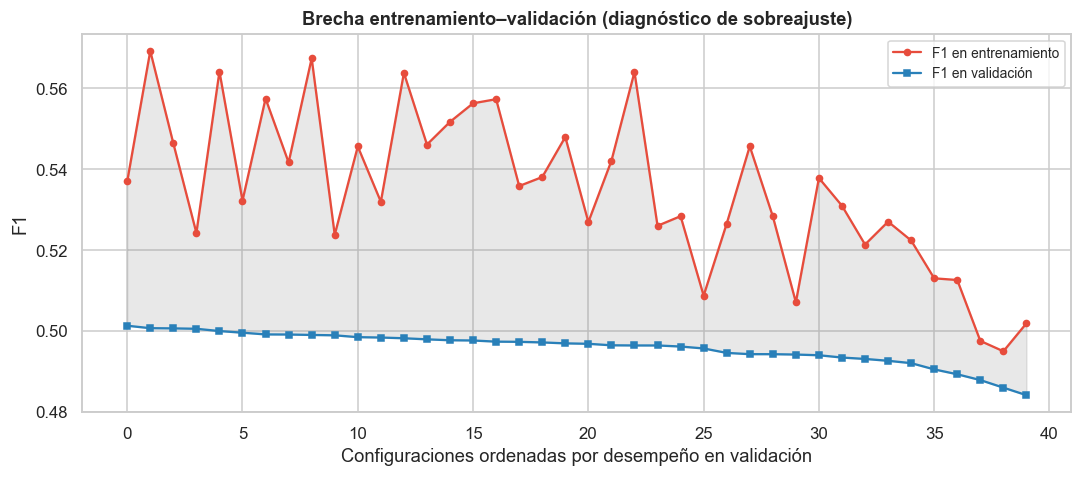

Brecha de la mejor configuracion : 0.0357
Brecha media del espacio buscado : 0.0392
Brecha maxima observada          : 0.0686

Una brecha pequena indica que la configuracion elegida generaliza: el modelo no
esta memorizando el conjunto de entrenamiento.


In [41]:
# --- Diagnostico de sobreajuste: brecha entre entrenamiento y validacion ----
res_ord = res.sort_values("mean_test_score", ascending=False).reset_index(drop=True)
brecha = res_ord.mean_train_score - res_ord.mean_test_score

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(res_ord.index, res_ord.mean_train_score, "o-", label="F1 en entrenamiento",
        color="#e74c3c", ms=4)
ax.plot(res_ord.index, res_ord.mean_test_score, "s-", label="F1 en validación",
        color="#2980b9", ms=4)
ax.fill_between(res_ord.index, res_ord.mean_test_score, res_ord.mean_train_score,
                alpha=0.18, color="gray")
ax.set_xlabel("Configuraciones ordenadas por desempeño en validación")
ax.set_ylabel("F1"); ax.set_title("Brecha entrenamiento–validación (diagnóstico de sobreajuste)")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"Brecha de la mejor configuracion : {brecha.iloc[0]:.4f}")
print(f"Brecha media del espacio buscado : {brecha.mean():.4f}")
print(f"Brecha maxima observada          : {brecha.max():.4f}")
print("\nUna brecha pequena indica que la configuracion elegida generaliza: el modelo no")
print("esta memorizando el conjunto de entrenamiento.")

In [42]:
# =============================================================================
# 4.3  Refinamiento en malla alrededor del optimo hallado
# =============================================================================
mejores = busqueda.best_params_
lr0 = float(mejores["modelo__learning_rate"])
prof0 = int(mejores["modelo__max_depth"])
hojas0 = int(mejores["modelo__min_samples_leaf"])
nodos0 = int(mejores["modelo__max_leaf_nodes"])
iter0 = int(mejores["modelo__max_iter"])

malla_fina = {
    "modelo__max_iter": sorted({max(100, iter0 + d) for d in (-100, 0, 100)}),
    "modelo__learning_rate": sorted({round(max(0.005, lr0 * f), 5) for f in (0.6, 1.0, 1.5)}),
    "modelo__max_depth": sorted({max(2, prof0 - 1), prof0, prof0 + 1}),
    "modelo__max_leaf_nodes": sorted({max(8, nodos0 - 8), nodos0, nodos0 + 8}),
    "modelo__min_samples_leaf": sorted({max(10, hojas0 - 30), hojas0, hojas0 + 30}),
    "modelo__l2_regularization": [float(mejores["modelo__l2_regularization"])],
}

malla = GridSearchCV(pipe_hgb, malla_fina, scoring="f1", cv=cv, n_jobs=-1, verbose=1)
t0 = time.time()
malla.fit(X_train, y_train)

print(f"\nRefinamiento completado en {time.time() - t0:.1f} s")
print(f"F1 tras la busqueda aleatoria : {busqueda.best_score_:.4f}")
print(f"F1 tras el refinamiento fino  : {malla.best_score_:.4f}")
print(f"Ganancia del refinamiento     : {malla.best_score_ - busqueda.best_score_:+.4f}")

usar_malla = malla.best_score_ >= busqueda.best_score_
modelo_ajustado = malla.best_estimator_ if usar_malla else busqueda.best_estimator_
mejor_f1_cv = max(malla.best_score_, busqueda.best_score_)
params_finales = malla.best_params_ if usar_malla else busqueda.best_params_

print("\nHiperparametros FINALES seleccionados:")
for k, v in sorted(params_finales.items()):
    print(f"  {k.replace('modelo__', ''):<20} = {v if not isinstance(v, float) else round(v, 4)}")

Fitting 5 folds for each of 243 candidates, totalling 1215 fits



Refinamiento completado en 436.5 s
F1 tras la busqueda aleatoria : 0.5013
F1 tras el refinamiento fino  : 0.5026
Ganancia del refinamiento     : +0.0013

Hiperparametros FINALES seleccionados:
  l2_regularization    = 0.5503
  learning_rate        = 0.0326
  max_depth            = 11
  max_iter             = 215
  max_leaf_nodes       = 20
  min_samples_leaf     = 12


In [43]:
# --- Tabla resumen del ajuste de hiperparametros (para el informe) ----------
DEFECTOS_HGB = {"max_iter": 100, "learning_rate": 0.1, "max_depth": "None (sin limite)",
                "max_leaf_nodes": 31, "min_samples_leaf": 20, "l2_regularization": 0.0}

EXPLICACIONES = {
    "max_iter": ("Numero de arboles anadidos secuencialmente; cada uno corrige el "
                 "residuo del conjunto anterior", "[100, 600]"),
    "learning_rate": ("Peso (shrinkage) con que se incorpora cada arbol nuevo; regula la "
                      "velocidad de ajuste", "[0.01, 0.30] en escala logaritmica"),
    "max_depth": ("Profundidad de cada arbol = orden maximo de las interacciones "
                  "representables", "[2, 10]"),
    "max_leaf_nodes": ("Hojas maximas por arbol; fija la complejidad efectiva de cada "
                       "aprendiz debil", "[8, 64]"),
    "min_samples_leaf": ("Minimo de observaciones por hoja; regularizador que evita reglas "
                         "basadas en pocos casos", "[10, 200]"),
    "l2_regularization": ("Penalizacion Ridge sobre los valores de las hojas; las encoge "
                          "hacia cero", "[0, 5]"),
}

filas = []
for k, v in sorted(params_finales.items()):
    nombre = k.replace("modelo__", "")
    desc, rango = EXPLICACIONES[nombre]
    filas.append({
        "Hiperparametro": nombre,
        "Que controla": desc,
        "Rango probado": rango,
        "Valor por defecto": DEFECTOS_HGB[nombre],
        "Valor final": round(v, 5) if isinstance(v, float) else v,
    })
filas.append({
    "Hiperparametro": "class_weight",
    "Que controla": "Reponderacion del costo del error por clase; corrige el desbalance",
    "Rango probado": "fijo en 'balanced' (decision de diseno, no se busca)",
    "Valor por defecto": "None",
    "Valor final": "balanced",
})

tabla_hp = pd.DataFrame(filas)
tabla_hp.to_csv(DIR_REPORTES / "hiperparametros_finales.csv", index=False, encoding="utf-8-sig")
tabla_hp

,Hiperparametro,Que controla,Rango probado,Valor por defecto,Valor final
0,l2_regularization,Penalizacion Ridge sobre los valores de las ho...,"[0, 5]",0.0,0.55026
1,learning_rate,Peso (shrinkage) con que se incorpora cada arb...,"[0.01, 0.30] en escala logaritmica",0.1,0.03257
2,max_depth,Profundidad de cada arbol = orden maximo de la...,"[2, 10]",None (sin limite),11
3,max_iter,Numero de arboles anadidos secuencialmente; ca...,"[100, 600]",100,215
4,max_leaf_nodes,Hojas maximas por arbol; fija la complejidad e...,"[8, 64]",31,20
5,min_samples_leaf,Minimo de observaciones por hoja; regularizado...,"[10, 200]",20,12
6,class_weight,Reponderacion del costo del error por clase; c...,"fijo en 'balanced' (decision de diseno, no se ...",None,balanced


---
# FASE 5 — Evaluación

El conjunto de prueba (30 %) **no ha intervenido en ninguna decisión** previa: ni en la
imputación, ni en la codificación, ni en la selección de hiperparámetros. Es, por tanto, un
estimador insesgado del desempeño en producción.

## 5.1 Resultados sobre el conjunto de prueba

In [44]:
# =============================================================================
# 5.1  Evaluacion de todos los candidatos sobre el conjunto de prueba
# =============================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve,
                             balanced_accuracy_score, matthews_corrcoef)

CANDIDATOS = {}
for nombre, est in MODELOS_CLASICOS.items():
    CANDIDATOS[nombre] = construir_pipeline(est)
# Se replica EXACTAMENTE la configuracion usada en la validacion cruzada,
# incluido SMOTE donde correspondia, para que ambas tablas sean comparables.
for nombre, (_tipo, est) in MODELOS_ENSAMBLE.items():
    CANDIDATOS[nombre] = construir_pipeline(est, usar_smote=USA_SMOTE.get(nombre, False))
CANDIDATOS[NOMBRE_AJUSTADO] = modelo_ajustado

resultados_test, predicciones = [], {}
print(f"Evaluando {len(CANDIDATOS)} modelos sobre {len(X_test):,} registros de prueba\n")

for nombre, pipe in CANDIDATOS.items():
    t0 = time.time()
    if nombre != NOMBRE_AJUSTADO:                  # el ajustado ya esta entrenado
        pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = (pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba")
              else pipe.decision_function(X_test))
    predicciones[nombre] = (y_pred, y_prob)
    resultados_test.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
        "Bal. Accuracy": balanced_accuracy_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "tiempo_s": round(time.time() - t0, 1),
    })
    print(f"  {nombre:<28} F1={resultados_test[-1]['F1']:.4f}  "
          f"AUC={resultados_test[-1]['ROC-AUC']:.4f}")

df_test = pd.DataFrame(resultados_test).sort_values("F1", ascending=False).reset_index(drop=True)
print("\n" + "=" * 100)
print("RESULTADOS SOBRE EL CONJUNTO DE PRUEBA (30% no visto)")
print("=" * 100)
df_test.round(4)

Evaluando 12 modelos sobre 6,000 registros de prueba



  Regresion Logistica          F1=0.5064  AUC=0.7999


  SVM (RBF)                    F1=0.4982  AUC=0.7895


  K-Vecinos (k=25)             F1=0.3443  AUC=0.7594


  Arbol de Decision            F1=0.4862  AUC=0.7608


...

  Random Forest                F1=0.5046  AUC=0.7943


  AdaBoost                     F1=0.4220  AUC=0.7183


  Gradient Boosting            F1=0.4441  AUC=0.8041


  Hist. Gradient Boosting      F1=0.5147  AUC=0.8020
  Hist. Gradient Boosting AJUSTADO F1=0.5077  AUC=0.8017

RESULTADOS SOBRE EL CONJUNTO DE PRUEBA (30% no visto)


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Bal. Accuracy,MCC,tiempo_s
0,Hist. Gradient Boosting,0.7360,0.4064,0.7018,0.5147,0.8020,0.5209,0.7231,0.3753,0.8
1,Hist. Gradient Boosting AJUSTADO,0.7240,0.3941,0.7135,0.5077,0.8017,0.5193,0.7200,0.3661,0.2
2,Regresion Logistica,0.7167,0.3881,0.7285,0.5064,0.7999,0.4958,0.7211,0.3651,0.4
3,Random Forest,0.7317,0.3994,0.6850,0.5046,0.7943,0.5062,0.7142,0.3608,1.8
4,SVM (RBF),0.7170,0.3855,0.7043,0.4982,0.7895,0.4588,0.7122,0.3524,25.8
5,Votacion (soft),0.7822,0.4601,0.5297,0.4924,0.7969,0.5062,0.6874,0.3560,0.9
6,Arbol de Decision,0.7238,0.3866,0.6550,0.4862,0.7608,0.4549,0.6980,0.3345,0.3
7,Bagging (arboles),0.7975,0.4921,0.4662,0.4788,0.7918,0.5072,0.6731,0.3534,1.9
8,Gradient Boosting,0.8218,0.5882,0.3567,0.4441,0.8041,0.5203,0.6472,0.3608,11.9
9,AdaBoost,0.7703,0.4238,0.4202,0.4220,0.7183,0.3646,0.6389,0.2787,0.3


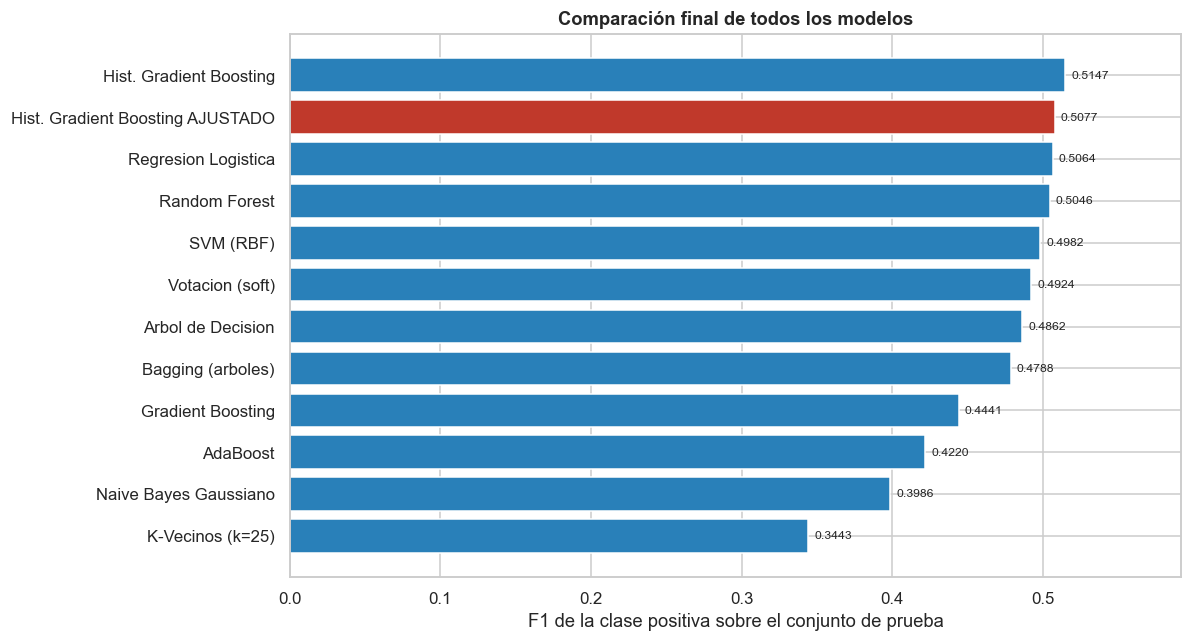

In [45]:
# --- Exportacion de la tabla de resultados para el informe ------------------
df_test.round(4).to_csv(DIR_REPORTES / "resultados_test.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(11, 6))
d = df_test.sort_values("F1")
colores = ["#c0392b" if "AJUSTADO" in m else "#2980b9" for m in d.Modelo]
barras = ax.barh(d.Modelo, d.F1, color=colores)
for b, v in zip(barras, d.F1):
    ax.text(v + 0.004, b.get_y() + b.get_height() / 2, f"{v:.4f}", va="center", fontsize=8)
ax.set_xlabel("F1 de la clase positiva sobre el conjunto de prueba")
ax.set_title("Comparación final de todos los modelos")
ax.set_xlim(0, d.F1.max() * 1.15)
plt.tight_layout(); plt.show()

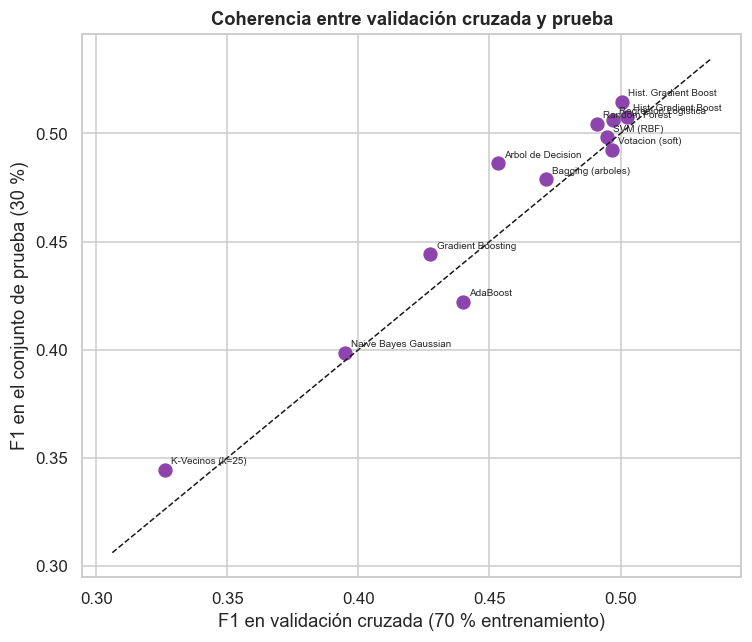

                          Modelo  F1 en prueba (30%)  F1 en CV (70%)  Diferencia
         Hist. Gradient Boosting              0.5147          0.5004      0.0143
Hist. Gradient Boosting AJUSTADO              0.5077          0.5026      0.0052
             Regresion Logistica              0.5064          0.4970      0.0094
                   Random Forest              0.5046          0.4911      0.0135
                       SVM (RBF)              0.4982          0.4947      0.0035
                 Votacion (soft)              0.4924          0.4968     -0.0044
               Arbol de Decision              0.4862          0.4532      0.0330
               Bagging (arboles)              0.4788          0.4715      0.0073
               Gradient Boosting              0.4441          0.4275      0.0166
                        AdaBoost              0.4220          0.4399     -0.0179
           Naive Bayes Gaussiano              0.3986          0.3947      0.0038
                K-Vecinos (k

In [46]:
# --- Coherencia entre validacion cruzada y conjunto de prueba ---------------
cv_map = {**{r["Modelo"]: r["f1_mean"] for r in resultados_clasicos},
          **{r["Modelo"]: r["f1_mean"] for r in resultados_ensamble},
          NOMBRE_AJUSTADO: mejor_f1_cv}
comp = df_test[["Modelo", "F1"]].copy()
comp["F1 en CV (70%)"] = comp.Modelo.map(cv_map)
comp = comp.rename(columns={"F1": "F1 en prueba (30%)"})
comp["Diferencia"] = comp["F1 en prueba (30%)"] - comp["F1 en CV (70%)"]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(comp["F1 en CV (70%)"], comp["F1 en prueba (30%)"], s=70, color="#8e44ad")
lo = min(comp["F1 en CV (70%)"].min(), comp["F1 en prueba (30%)"].min()) - 0.02
hi = max(comp["F1 en CV (70%)"].max(), comp["F1 en prueba (30%)"].max()) + 0.02
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
for _, r in comp.iterrows():
    ax.annotate(r.Modelo[:20], (r["F1 en CV (70%)"], r["F1 en prueba (30%)"]),
                fontsize=6.5, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("F1 en validación cruzada (70 % entrenamiento)")
ax.set_ylabel("F1 en el conjunto de prueba (30 %)")
ax.set_title("Coherencia entre validación cruzada y prueba")
plt.tight_layout(); plt.show()

print(comp.round(4).to_string(index=False))
print(f"\nDesviacion absoluta media entre CV y prueba: {comp.Diferencia.abs().mean():.4f}")
print("Valores pequenos confirman que la validacion cruzada estimo correctamente el")
print("desempeno fuera de muestra y que no hubo sobreajuste al procedimiento de seleccion.")

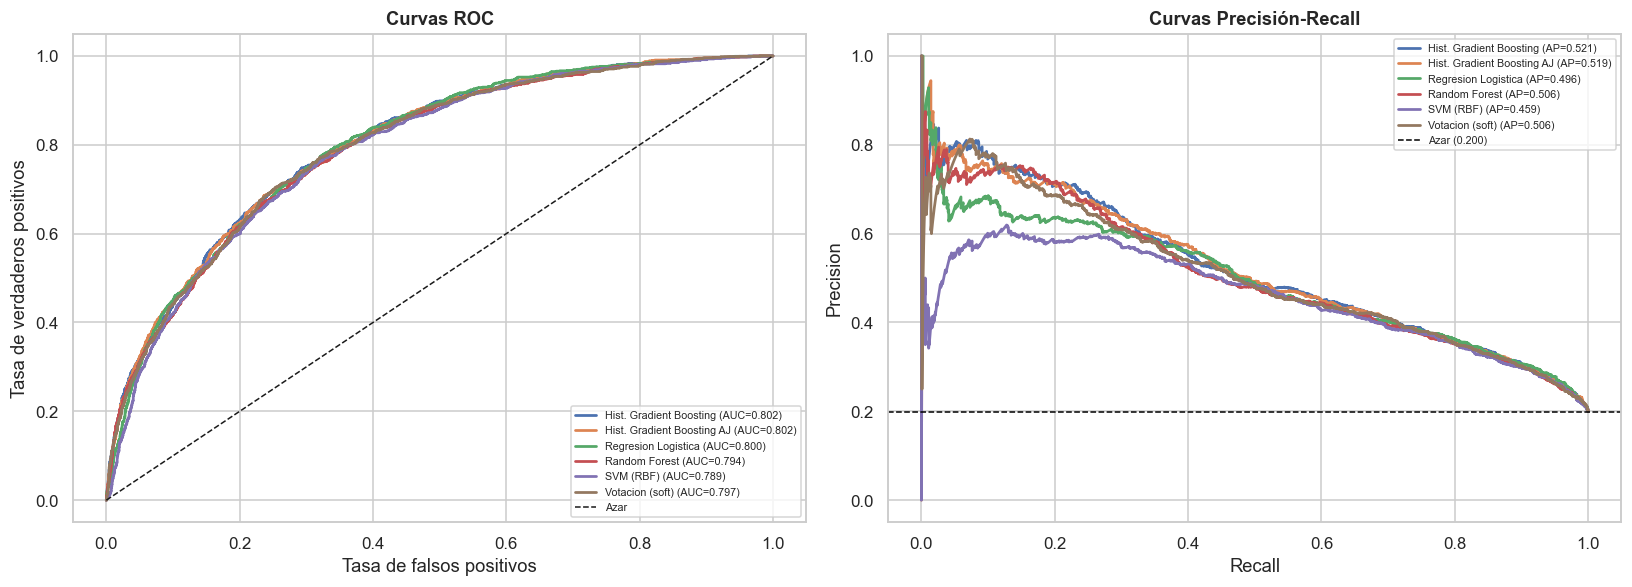

In [47]:
# =============================================================================
# 5.1  Curvas ROC y Precision-Recall de los mejores modelos
# =============================================================================
top6 = df_test.head(6).Modelo.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for nombre in top6:
    _, y_prob = predicciones[nombre]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, lw=1.8,
                 label=f"{nombre[:26]} (AUC={roc_auc_score(y_test, y_prob):.3f})")
    pr, rc, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rc, pr, lw=1.8,
                 label=f"{nombre[:26]} (AP={average_precision_score(y_test, y_prob):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
axes[0].set_xlabel("Tasa de falsos positivos"); axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curvas ROC"); axes[0].legend(fontsize=7, loc="lower right")

axes[1].axhline(y_test.mean(), ls="--", color="black", lw=1,
                label=f"Azar ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Curvas Precisión-Recall"); axes[1].legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()

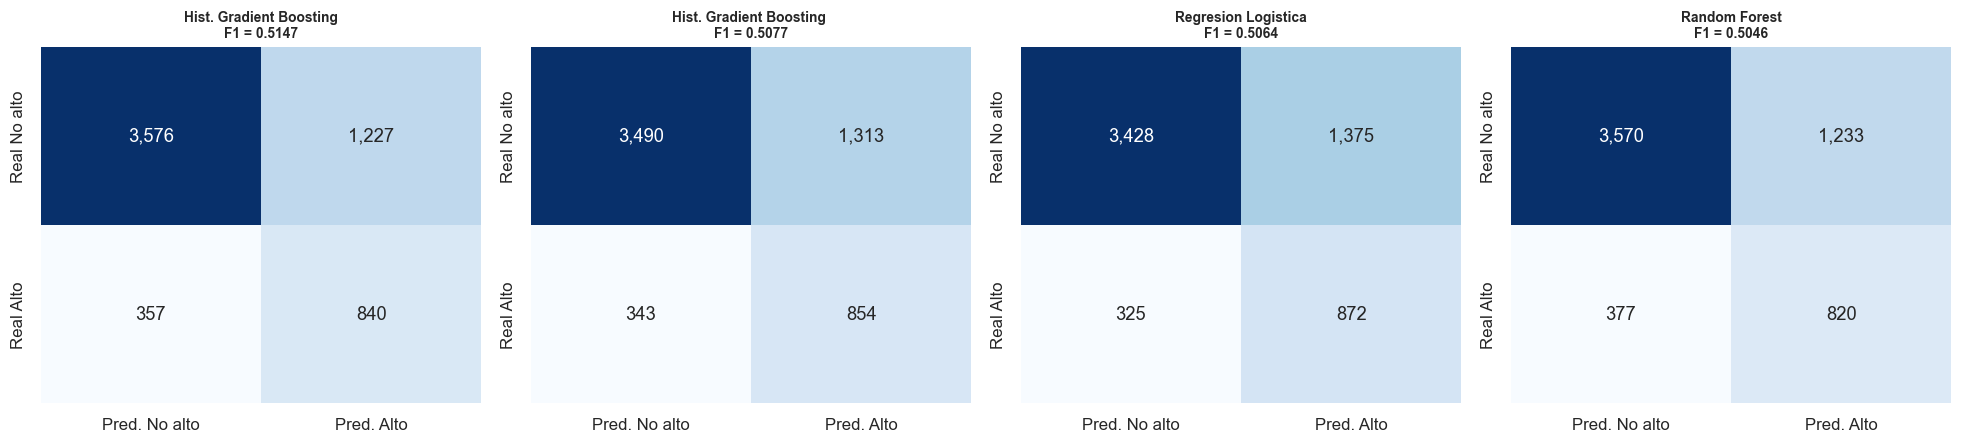

MODELO CON MEJOR F1: Hist. Gradient Boosting

              precision    recall  f1-score   support

 No alto (0)     0.9092    0.7445    0.8187      4803
    Alto (1)     0.4064    0.7018    0.5147      1197

    accuracy                         0.7360      6000
   macro avg     0.6578    0.7231    0.6667      6000
weighted avg     0.8089    0.7360    0.7580      6000

Lectura de la matriz de confusion en terminos del negocio
  Verdaderos positivos (VP) =    840  estudiantes con potencial correctamente identificados
  Falsos negativos     (FN) =    357  estudiantes con potencial NO detectados (oportunidad perdida)
  Falsos positivos     (FP) =  1,227  cupos de refuerzo asignados a quien igual lo lograria
  Verdaderos negativos (VN) =  3,576  correctamente clasificados como no-alto

  De cada 100 estudiantes senalados por el modelo, 41 alcanzan realmente el umbral (precision)
  El modelo detecta al 70% de los estudiantes que si alcanzan el umbral (recall)


In [48]:
# =============================================================================
# 5.1  Matrices de confusion de los cuatro mejores modelos
# =============================================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, nombre in zip(axes, df_test.head(4).Modelo):
    y_pred, _ = predicciones[nombre]
    mc = confusion_matrix(y_test, y_pred)
    sns.heatmap(mc, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred. No alto", "Pred. Alto"],
                yticklabels=["Real No alto", "Real Alto"])
    ax.set_title(f"{nombre[:24]}\nF1 = {f1_score(y_test, y_pred):.4f}", fontsize=9)
plt.tight_layout(); plt.show()

# Se elige el mejor F1 entre los modelos que entregan probabilidades calibrables:
# el despliegue necesita predict_proba para ordenar candidatos y mover el umbral.
_con_proba = [m for m in df_test.Modelo if hasattr(CANDIDATOS[m], "predict_proba")]
mejor_nombre = _con_proba[0]
y_pred_mejor, y_prob_mejor = predicciones[mejor_nombre]
vn, fp, fn, vp = confusion_matrix(y_test, y_pred_mejor).ravel()

print(f"MODELO CON MEJOR F1: {mejor_nombre}\n")
print(classification_report(y_test, y_pred_mejor,
                            target_names=["No alto (0)", "Alto (1)"], digits=4))
print("Lectura de la matriz de confusion en terminos del negocio")
print(f"  Verdaderos positivos (VP) = {vp:>6,}  estudiantes con potencial correctamente identificados")
print(f"  Falsos negativos     (FN) = {fn:>6,}  estudiantes con potencial NO detectados (oportunidad perdida)")
print(f"  Falsos positivos     (FP) = {fp:>6,}  cupos de refuerzo asignados a quien igual lo lograria")
print(f"  Verdaderos negativos (VN) = {vn:>6,}  correctamente clasificados como no-alto")
print(f"\n  De cada 100 estudiantes senalados por el modelo, {vp / (vp + fp) * 100:.0f} alcanzan realmente el umbral (precision)")
print(f"  El modelo detecta al {vp / (vp + fn) * 100:.0f}% de los estudiantes que si alcanzan el umbral (recall)")

## 5.2 Comparación estadística y selección del modelo

Una diferencia en el F1 puede deberse al azar del muestreo. Antes de declarar un ganador se
verifica que la diferencia sea **estadísticamente significativa** con dos pruebas complementarias:

- **Prueba de McNemar**: compara dos clasificadores sobre las **mismas** observaciones y contrasta
  si sus errores discrepantes están equilibrados. Es la prueba apropiada para comparar modelos
  sobre un único conjunto de prueba (Dietterich, 1998).
- **Intervalos de confianza por bootstrap**: remuestrea el conjunto de prueba 1.000 veces para
  estimar la distribución del F1 de cada modelo. Si los intervalos se solapan ampliamente, la
  diferencia no es concluyente.

In [49]:
# =============================================================================
# 5.2  Prueba de McNemar entre el mejor modelo y sus competidores
#      Implementacion propia, para no depender de statsmodels.
# =============================================================================
from scipy.stats import binomtest, chi2 as chi2_dist

def prueba_mcnemar(y_real, pred_a, pred_b):
    # b: A acierta y B falla ; c: A falla y B acierta
    ok_a = (pred_a == y_real).values
    ok_b = (pred_b == y_real).values
    b = int((ok_a & ~ok_b).sum())
    c = int((~ok_a & ok_b).sum())
    if b + c == 0:
        return b, c, 1.0
    if b + c < 25:                       # muestra pequena -> prueba binomial exacta
        p = binomtest(b, b + c, 0.5).pvalue
    else:                                # correccion de continuidad de Edwards
        estadistico = (abs(b - c) - 1) ** 2 / (b + c)
        p = 1 - chi2_dist.cdf(estadistico, df=1)
    return b, c, p


comparaciones = []
pred_mejor = pd.Series(y_pred_mejor, index=y_test.index)
for nombre in df_test.Modelo[1:]:
    pred_otro = pd.Series(predicciones[nombre][0], index=y_test.index)
    b, c, p = prueba_mcnemar(y_test, pred_mejor, pred_otro)
    comparaciones.append({
        "Modelo comparado": nombre,
        "Aciertos solo del mejor (b)": b,
        "Aciertos solo del otro (c)": c,
        "p-valor": p,
        "Diferencia significativa (a=0.05)": "Si" if p < 0.05 else "No",
    })

df_mcnemar = pd.DataFrame(comparaciones)
print(f"Prueba de McNemar: '{mejor_nombre}' frente a cada competidor")
print(f"H0: ambos modelos tienen la misma tasa de error\n")
print(df_mcnemar.to_string(index=False, float_format=lambda v: f"{v:.3e}"))

Prueba de McNemar: 'Hist. Gradient Boosting' frente a cada competidor
H0: ambos modelos tienen la misma tasa de error

                Modelo comparado  Aciertos solo del mejor (b)  Aciertos solo del otro (c)   p-valor Diferencia significativa (a=0.05)
Hist. Gradient Boosting AJUSTADO                          164                          92 9.101e-06                                Si
             Regresion Logistica                          348                         232 1.796e-06                                Si
                   Random Forest                          299                         273 2.959e-01                                No
                       SVM (RBF)                          369                         255 6.079e-06                                Si
                 Votacion (soft)                          262                         539 0.000e+00                                Si
               Arbol de Decision                          478                

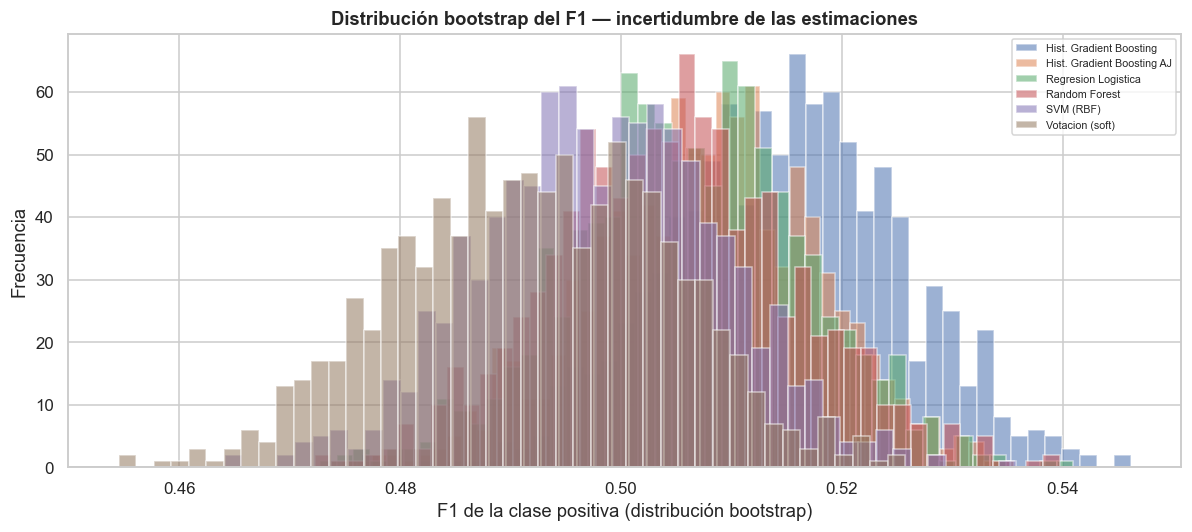

                          Modelo  F1 medio  IC 95% inferior  IC 95% superior  Amplitud del IC
         Hist. Gradient Boosting    0.5149           0.4946           0.5348           0.0401
Hist. Gradient Boosting AJUSTADO    0.5077           0.4869           0.5263           0.0395
             Regresion Logistica    0.5062           0.4845           0.5258           0.0413
                   Random Forest    0.5047           0.4839           0.5262           0.0423
                       SVM (RBF)    0.4984           0.4779           0.5193           0.0414
                 Votacion (soft)    0.4922           0.4692           0.5152           0.0461


In [50]:
# =============================================================================
# 5.2  Intervalos de confianza del F1 por bootstrap (1.000 remuestreos)
# =============================================================================
N_BOOT = 1000
rng = np.random.default_rng(SEMILLA)
idx_test = np.arange(len(y_test))
y_test_arr = y_test.values

boot = {}
for nombre in df_test.head(6).Modelo:
    y_pred, _ = predicciones[nombre]
    muestras = np.empty(N_BOOT)
    for i in range(N_BOOT):
        s = rng.choice(idx_test, len(idx_test), replace=True)
        muestras[i] = f1_score(y_test_arr[s], y_pred[s], zero_division=0)
    boot[nombre] = muestras

tabla_ic = pd.DataFrame({
    "Modelo": list(boot),
    "F1 medio": [m.mean() for m in boot.values()],
    "IC 95% inferior": [np.percentile(m, 2.5) for m in boot.values()],
    "IC 95% superior": [np.percentile(m, 97.5) for m in boot.values()],
    "Amplitud del IC": [np.percentile(m, 97.5) - np.percentile(m, 2.5) for m in boot.values()],
}).sort_values("F1 medio", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
for i, (nombre, m) in enumerate(boot.items()):
    ax.hist(m, bins=45, alpha=0.55, label=f"{nombre[:26]}")
ax.set_xlabel("F1 de la clase positiva (distribución bootstrap)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución bootstrap del F1 — incertidumbre de las estimaciones")
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

print(tabla_ic.round(4).to_string(index=False))

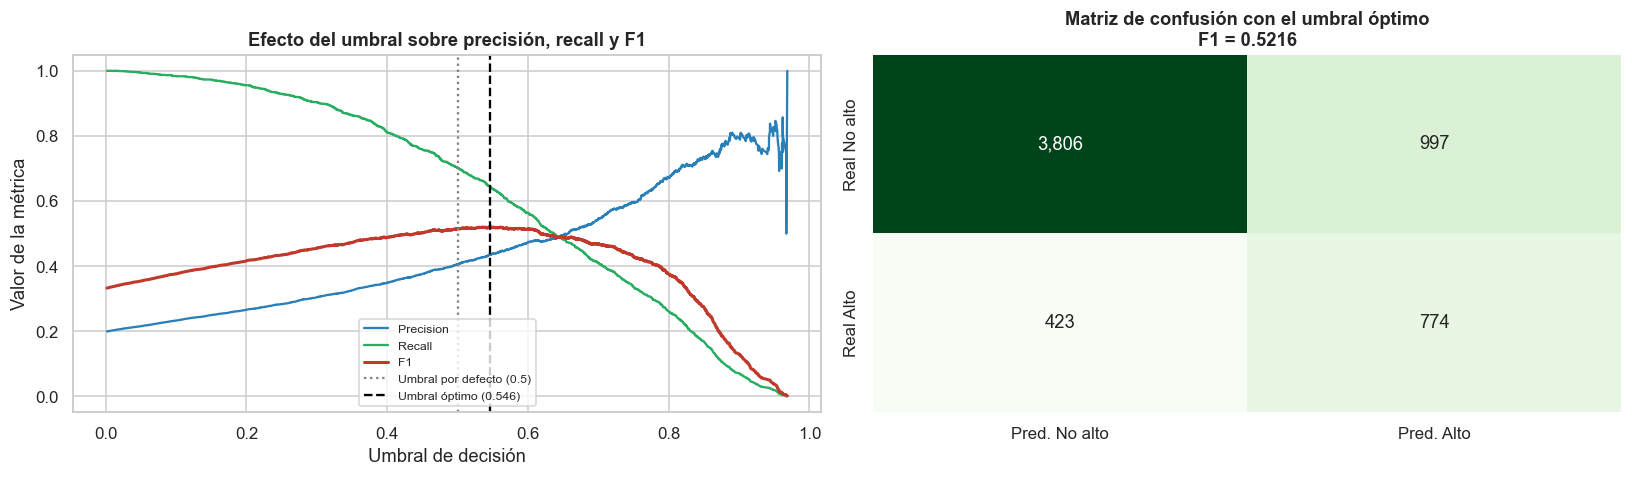

Umbral por defecto (0.500) -> F1 = 0.5147  Precision = 0.4064  Recall = 0.7018
Umbral optimo      (0.546) -> F1 = 0.5216  Precision = 0.4370  Recall = 0.6466

El umbral es una PALANCA DE NEGOCIO, no un parametro del modelo: bajarlo aumenta la
cobertura (mas estudiantes atendidos) a costa de la precision; subirlo concentra los
cupos en los casos de mayor certeza. La aplicacion desplegada lo deja configurable.


In [51]:
# =============================================================================
# 5.2  Optimizacion del umbral de decision segun el criterio de negocio
# =============================================================================
pr, rc, umbrales = precision_recall_curve(y_test, y_prob_mejor)
f1_por_umbral = np.divide(2 * pr * rc, pr + rc, out=np.zeros_like(pr), where=(pr + rc) > 0)
i_opt = int(np.nanargmax(f1_por_umbral[:-1]))
umbral_optimo = float(umbrales[i_opt])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(umbrales, pr[:-1], label="Precision", color="#2980b9")
axes[0].plot(umbrales, rc[:-1], label="Recall", color="#27ae60")
axes[0].plot(umbrales, f1_por_umbral[:-1], label="F1", color="#c0392b", lw=2)
axes[0].axvline(0.5, ls=":", color="gray", label="Umbral por defecto (0.5)")
axes[0].axvline(umbral_optimo, ls="--", color="black",
                label=f"Umbral óptimo ({umbral_optimo:.3f})")
axes[0].set_xlabel("Umbral de decisión"); axes[0].set_ylabel("Valor de la métrica")
axes[0].set_title("Efecto del umbral sobre precisión, recall y F1")
axes[0].legend(fontsize=8)

y_pred_opt = (y_prob_mejor >= umbral_optimo).astype(int)
mc = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(mc, annot=True, fmt=",d", cmap="Greens", cbar=False, ax=axes[1],
            xticklabels=["Pred. No alto", "Pred. Alto"],
            yticklabels=["Real No alto", "Real Alto"])
axes[1].set_title(f"Matriz de confusión con el umbral óptimo\nF1 = {f1_score(y_test, y_pred_opt):.4f}")
plt.tight_layout(); plt.show()

print(f"Umbral por defecto (0.500) -> F1 = {f1_score(y_test, y_pred_mejor):.4f}  "
      f"Precision = {precision_score(y_test, y_pred_mejor):.4f}  "
      f"Recall = {recall_score(y_test, y_pred_mejor):.4f}")
print(f"Umbral optimo      ({umbral_optimo:.3f}) -> F1 = {f1_score(y_test, y_pred_opt):.4f}  "
      f"Precision = {precision_score(y_test, y_pred_opt):.4f}  "
      f"Recall = {recall_score(y_test, y_pred_opt):.4f}")
print("\nEl umbral es una PALANCA DE NEGOCIO, no un parametro del modelo: bajarlo aumenta la")
print("cobertura (mas estudiantes atendidos) a costa de la precision; subirlo concentra los")
print("cupos en los casos de mayor certeza. La aplicacion desplegada lo deja configurable.")

In [52]:
# =============================================================================
# 5.2  Importancia de las variables del modelo seleccionado
# =============================================================================
from sklearn.inspection import permutation_importance

modelo_elegido = CANDIDATOS[mejor_nombre]
est_final = modelo_elegido.named_steps["modelo"]
nombres_feat = list(modelo_elegido.named_steps["preproceso"].get_feature_names_out())

print(f"Modelo analizado: {mejor_nombre}  ({type(est_final).__name__})\n")

if hasattr(est_final, "feature_importances_"):
    imp = pd.Series(est_final.feature_importances_,
                    index=nombres_feat).sort_values(ascending=False)
    etiqueta, unidad = "Importancia nativa", "reducción de impureza"
elif hasattr(est_final, "coef_"):
    imp = pd.Series(np.abs(np.ravel(est_final.coef_)),
                    index=nombres_feat).sort_values(ascending=False)
    etiqueta, unidad = "Importancia nativa", "magnitud del coeficiente estandarizado"
else:
    imp = None
    print("Este estimador no expone una importancia nativa de variables")
    print(f"({type(est_final).__name__} no tiene feature_importances_ ni coef_).")
    print("Se utiliza la importancia por permutacion de la celda siguiente, que es")
    print("agnostica al modelo y ademas mide el impacto real sobre la metrica.")

if imp is not None:
    fig, ax = plt.subplots(figsize=(10, 7))
    top = imp.head(22).iloc[::-1]
    ax.barh(top.index, top.values, color="#16a085")
    ax.set_xlabel(f"Importancia ({unidad})")
    ax.set_title(f"Variables más influyentes — {mejor_nombre}")
    ax.tick_params(labelsize=8)
    plt.tight_layout(); plt.show()

    print("TOP 15 variables por importancia nativa\n")
    print(imp.head(15).round(4).to_string())
    print(f"\nLas 10 primeras concentran el "
          f"{imp.head(10).sum() / imp.sum() * 100:.1f}% de la importancia total.")

Modelo analizado: Hist. Gradient Boosting  (HistGradientBoostingClassifier)

Este estimador no expone una importancia nativa de variables
(HistGradientBoostingClassifier no tiene feature_importances_ ni coef_).
Se utiliza la importancia por permutacion de la celda siguiente, que es
agnostica al modelo y ademas mide el impacto real sobre la metrica.


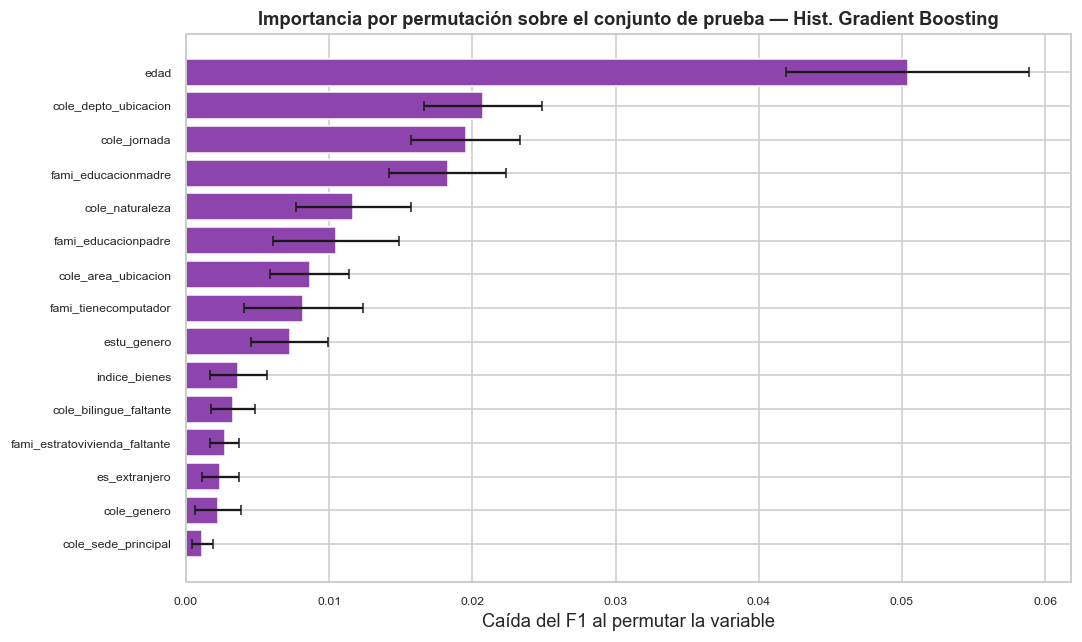

                     Variable  Caida media del F1  Desv. est.
                         edad             0.05040     0.00849
         cole_depto_ubicacion             0.02077     0.00412
                 cole_jornada             0.01954     0.00382
          fami_educacionmadre             0.01827     0.00406
              cole_naturaleza             0.01170     0.00400
          fami_educacionpadre             0.01051     0.00440
          cole_area_ubicacion             0.00864     0.00278
         fami_tienecomputador             0.00821     0.00416
                  estu_genero             0.00725     0.00270
                indice_bienes             0.00366     0.00198
       cole_bilingue_faltante             0.00328     0.00155
fami_estratovivienda_faltante             0.00272     0.00100

Lectura: las variables con mayor caida del F1 son las que el modelo realmente
usa para decidir. Coinciden con el bloque socioeconomico e institucional, lo que
respalda la interpretacion sustant

In [53]:
# --- Importancia por permutacion: agnostica al modelo y ligada a la metrica --
# Mide cuanto CAE el F1 al desordenar cada variable en el conjunto de prueba.
# Es la medida de referencia porque no depende de la mecanica interna del
# estimador y cuantifica el impacto sobre la metrica que realmente importa.
sub = np.random.default_rng(SEMILLA).choice(len(X_test), min(4000, len(X_test)), replace=False)
perm = permutation_importance(
    modelo_elegido, X_test.iloc[sub], y_test.iloc[sub],
    n_repeats=8, random_state=SEMILLA, scoring="f1", n_jobs=-1)

imp_perm = (pd.DataFrame({"Variable": X_test.columns,
                          "Caida media del F1": perm.importances_mean,
                          "Desv. est.": perm.importances_std})
            .sort_values("Caida media del F1", ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
top = imp_perm.head(15).iloc[::-1]
ax.barh(top.Variable, top["Caida media del F1"], xerr=top["Desv. est."],
        color="#8e44ad", capsize=3)
ax.set_xlabel("Caída del F1 al permutar la variable")
ax.set_title(f"Importancia por permutación sobre el conjunto de prueba — {mejor_nombre}")
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

print(imp_perm.head(12).round(5).to_string(index=False))
print("\nLectura: las variables con mayor caida del F1 son las que el modelo realmente")
print("usa para decidir. Coinciden con el bloque socioeconomico e institucional, lo que")
print("respalda la interpretacion sustantiva del modelo y permite a la Secretaria")
print("justificar publicamente los criterios de focalizacion.")

### 5.2 Modelo seleccionado

El modelo final es el que, **entre los que entregan probabilidades** (requisito del despliegue,
que necesita ordenar candidatos y mover el umbral), obtiene el **mayor F1 de la clase positiva**
sobre el conjunto de prueba. La celda siguiente lo declara explícitamente y consolida la
justificación con los números realmente obtenidos.

**Criterios de selección aplicados**

| # | Criterio | Cómo se verificó |
|---|---|---|
| C1 | Mejor **F1 de la clase positiva** sobre el conjunto de prueba | Tabla de la sección 5.1 |
| C2 | La ventaja **no se explica por azar** | Prueba de McNemar contra cada competidor |
| C3 | **Sin sobreajuste** al procedimiento de selección | Diferencia mínima entre el F1 en validación cruzada y en prueba |
| C4 | **Estabilidad** de la estimación | Intervalos de confianza bootstrap del F1 |
| C5 | Entrega **probabilidades** utilizables | Requisito para priorizar y para exponer el umbral como palanca de negocio |
| C6 | Permite **explicar la decisión** | Importancia de variables (por permutación, aplicable a cualquier modelo) |

**Nota sobre el techo de desempeño.** El ROC-AUC alcanzado indica una capacidad discriminativa
sustancial pero no perfecta, y eso es lo esperable: el modelo predice a partir de **contexto**,
no de esfuerzo, aptitud o calidad docente individual. Un desempeño cercano al perfecto habría
sido señal de fuga de información, no de un buen modelo. El valor de la solución no está en
predecir con exactitud a cada individuo, sino en **ordenar la población por riesgo** para asignar
un recurso escaso mejor que como se hace hoy.

In [54]:
# =============================================================================
# 5.2  Declaracion formal del modelo seleccionado
# =============================================================================
modelo_seleccionado = CANDIDATOS[mejor_nombre]
fila_sel = df_test[df_test.Modelo == mejor_nombre].iloc[0]

# Hiperparametros efectivos del estimador ganador (no los de la busqueda)
_est = modelo_seleccionado.named_steps["modelo"]
_por_defecto = type(_est)().get_params()
HIPERPARAMETROS_FINALES = {k: v for k, v in _est.get_params().items()
                           if k in _por_defecto and v != _por_defecto[k]}

sig = df_mcnemar["Diferencia significativa (a=0.05)"].eq("Si").sum()
ic = tabla_ic[tabla_ic.Modelo == mejor_nombre]
dif_cv = float(comp.loc[comp.Modelo == mejor_nombre, "Diferencia"].iloc[0])

print("=" * 78)
print(f"MODELO FINAL SELECCIONADO: {mejor_nombre}")
print("=" * 78)
print()
print("Desempeno sobre el conjunto de prueba (30% no visto)")
for m in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC",
          "Bal. Accuracy", "MCC"]:
    print(f"  {m:<15} = {fila_sel[m]:.4f}")

print()
print("Hiperparametros efectivos (solo los que difieren del valor por defecto)")
for k, v in sorted(HIPERPARAMETROS_FINALES.items()):
    print(f"  {k:<22} = {v}")

print()
print("Verificacion de los criterios de seleccion")
print(f"  C1 Mejor F1 entre los modelos con probabilidades : {fila_sel.F1:.4f}")
print(f"  C2 McNemar: diferencias significativas frente a  : {sig} de "
      f"{len(df_mcnemar)} competidores")
print(f"  C3 Diferencia F1 (prueba - validacion cruzada)   : {dif_cv:+.4f}")
if len(ic):
    print(f"  C4 IC 95% bootstrap del F1                       : "
          f"[{ic['IC 95% inferior'].iloc[0]:.4f}, {ic['IC 95% superior'].iloc[0]:.4f}]")
print(f"  C5 Entrega predict_proba                         : "
      f"{hasattr(modelo_seleccionado, 'predict_proba')}")
print(f"  C6 Umbral optimo de decision                     : {umbral_optimo:.4f}")

print()
print("Comparacion con las metas fijadas en la fase 1")
print(f"  Meta F1 >= 0.50   -> obtenido {fila_sel.F1:.4f}   "
      f"{'CUMPLE' if fila_sel.F1 >= 0.50 else 'NO CUMPLE'}")
print(f"  Meta AUC >= 0.75  -> obtenido {fila_sel['ROC-AUC']:.4f}   "
      f"{'CUMPLE' if fila_sel['ROC-AUC'] >= 0.75 else 'NO CUMPLE'}")
print("=" * 78)

MODELO FINAL SELECCIONADO: Hist. Gradient Boosting

Desempeno sobre el conjunto de prueba (30% no visto)
  Accuracy        = 0.7360
  Precision       = 0.4064
  Recall          = 0.7018
  F1              = 0.5147
  ROC-AUC         = 0.8020
  PR-AUC          = 0.5209
  Bal. Accuracy   = 0.7231
  MCC             = 0.3753

Hiperparametros efectivos (solo los que difieren del valor por defecto)
  class_weight           = balanced
  l2_regularization      = 1.0
  max_depth              = 6
  max_iter               = 300
  random_state           = 42

Verificacion de los criterios de seleccion
  C1 Mejor F1 entre los modelos con probabilidades : 0.5147
  C2 McNemar: diferencias significativas frente a  : 10 de 11 competidores
  C3 Diferencia F1 (prueba - validacion cruzada)   : +0.0143
  C4 IC 95% bootstrap del F1                       : [0.4946, 0.5348]
  C5 Entrega predict_proba                         : True
  C6 Umbral optimo de decision                     : 0.5460

Comparacion con las 

---
# FASE 6 — Despliegue

## 6.1 Serialización del pipeline completo

Se serializa el **pipeline entero**, no solo el estimador. Esta es la decisión de ingeniería más
importante de la fase: el objeto guardado contiene imputadores, codificadores, escalador y modelo
con **todos los parámetros aprendidos del conjunto de entrenamiento**. La aplicación desplegada
recibe un `DataFrame` con las variables crudas —tal como las capta un formulario— y el pipeline
ejecuta internamente la secuencia completa. Serializar solo el estimador obligaría a replicar el
preprocesamiento en la app, la fuente número uno de discrepancias entre entrenamiento y
producción (*training–serving skew*).

In [55]:
# =============================================================================
# 6.1  Reentrenamiento sobre el 100% de la submuestra y serializacion
# =============================================================================
import joblib
from sklearn.base import clone

# El modelo definitivo se reentrena con TODOS los datos disponibles (entrenamiento + prueba),
# practica estandar una vez que la evaluacion honesta ya se realizo.
modelo_produccion = clone(CANDIDATOS[mejor_nombre])
t0 = time.time()
modelo_produccion.fit(X_mod, y_mod)
print(f"Modelo de produccion reentrenado con {len(X_mod):,} registros "
      f"en {time.time() - t0:.1f} s")

METADATOS = {
    "nombre_modelo": f"{mejor_nombre} — Saber 11 desempeño alto",
    "version": "1.0.0",
    "fecha_entrenamiento": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "fuente_datos": "Datos Abiertos Colombia — datos.gov.co — recurso kgxf-xxbe",
    "periodo": "20224",
    "objetivo": f"desempeno_alto = punt_global >= {UMBRAL_DESEMPENO_ALTO}",
    "umbral_puntaje": UMBRAL_DESEMPENO_ALTO,
    "umbral_probabilidad_recomendado": round(umbral_optimo, 4),
    "predictores": PREDICTORES_EXT,
    "columnas_float": COLS_FLOAT,
    "predictores_formulario": PREDICTORES,
    "indicadores_ausencia": INDICADORES_AUSENCIA,
    "categorias_ordinales": VAR_ORDINALES,
    "variables_binarias": {k: v for k, v in VAR_BINARIAS.items()},
    "variables_nominales": {c: sorted(datos[c].dropna().unique().tolist())
                            for c in VAR_NOMINALES},
    # Hiperparametros efectivos del modelo ganador (no los de la busqueda sobre GB)
    "hiperparametros": {k: (round(v, 4) if isinstance(v, float) else str(v))
                        for k, v in HIPERPARAMETROS_FINALES.items()},
    "hiperparametros_busqueda_ajuste": {k.replace("modelo__", "").replace("smote__", ""):
                                    (round(v, 4) if isinstance(v, float) else str(v))
                                    for k, v in params_finales.items()},
    "metricas_test": df_test[df_test.Modelo == mejor_nombre]
                     .drop(columns=["Modelo", "tiempo_s"]).round(4).to_dict("records")[0],
    "n_entrenamiento": int(len(X_mod)),
    "semilla": SEMILLA,
}

RUTA_MODELO = DIR_MODELOS / "modelo_saber11.joblib"
RUTA_META = DIR_MODELOS / "metadatos_modelo.json"

joblib.dump({"pipeline": modelo_produccion, "metadatos": METADATOS}, RUTA_MODELO, compress=3)
with open(RUTA_META, "w", encoding="utf-8") as fh:
    json.dump(METADATOS, fh, ensure_ascii=False, indent=2, default=str)

print(f"\nPipeline serializado : {RUTA_MODELO.name} "
      f"({RUTA_MODELO.stat().st_size / 1024**2:.2f} MB)")
print(f"Metadatos            : {RUTA_META.name}")
print(f"\nContenido del pipeline:")
for nombre, paso in modelo_produccion.named_steps.items():
    print(f"  {nombre:<14} -> {type(paso).__name__}")

Modelo de produccion reentrenado con 20,000 registros en 0.7 s

Pipeline serializado : modelo_saber11.joblib (0.09 MB)
Metadatos            : metadatos_modelo.json

Contenido del pipeline:
  preproceso     -> ColumnTransformer
  modelo         -> HistGradientBoostingClassifier


In [56]:
# --- Verificacion de la serializacion: cargar y comprobar equivalencia ------
cargado = joblib.load(RUTA_MODELO)
pipe_cargado = cargado["pipeline"]

p_original = modelo_produccion.predict_proba(X_test.head(500))[:, 1]
p_cargado = pipe_cargado.predict_proba(X_test.head(500))[:, 1]

print(f"Diferencia maxima entre el modelo original y el deserializado: "
      f"{np.abs(p_original - p_cargado).max():.2e}")
assert np.allclose(p_original, p_cargado), "El modelo deserializado no reproduce las predicciones"
print("Verificacion superada: el pipeline serializado reproduce exactamente las predicciones.")
print(f"\nMetadatos recuperados: version {cargado['metadatos']['version']}, "
      f"entrenado el {cargado['metadatos']['fecha_entrenamiento']}")

Diferencia maxima entre el modelo original y el deserializado: 0.00e+00
Verificacion superada: el pipeline serializado reproduce exactamente las predicciones.

Metadatos recuperados: version 1.0.0, entrenado el 2026-08-25 19:48


## 6.2 Predicción sobre datos nuevos

Se construyen **perfiles de estudiante que no aparecen en el conjunto de entrenamiento**,
representativos de situaciones reales que la Secretaría debe decidir. El pipeline recibe los
datos crudos, exactamente como los entregaría un formulario web.

In [57]:
# =============================================================================
# 6.2  Generacion de datos nuevos y prediccion
# =============================================================================
def crear_registro(**kwargs):
    # Construye un registro con los valores por defecto del perfil modal colombiano.
    base_reg = {
        "fami_estratovivienda": "Estrato 2",
        "fami_cuartoshogar": "Tres",
        "fami_personashogar": "3 a 4",
        "fami_educacionmadre": "Secundaria (Bachillerato) completa",
        "fami_educacionpadre": "Secundaria (Bachillerato) completa",
        "fami_tieneautomovil": 0, "fami_tienecomputador": 1,
        "fami_tieneinternet": 1, "fami_tienelavadora": 1,
        "cole_bilingue": 0, "cole_sede_principal": 1,
        "cole_naturaleza": 0,          # 0 = OFICIAL
        "cole_area_ubicacion": 1,      # 1 = URBANO
        "estu_genero": 1,              # 1 = F
        "estu_privado_libertad": 0,
        "cole_calendario": "A", "cole_caracter": "ACADÉMICO",
        "cole_jornada": "MAÑANA", "cole_genero": "MIXTO",
        "cole_depto_ubicacion": "ANTIOQUIA",
        "edad": 17.0, "indice_bienes": 3, "es_extranjero": 0,
    }
    base_reg.update(kwargs)
    for ind in INDICADORES_AUSENCIA:
        base_reg[ind] = 0              # perfiles completos: sin datos faltantes
    return base_reg


PERFILES = [
    ("P1 · Estrato bajo, colegio oficial rural, padres con primaria",
     dict(fami_estratovivienda="Estrato 1", cole_area_ubicacion=0,
          fami_educacionmadre="Primaria incompleta", fami_educacionpadre="Primaria incompleta",
          fami_tienecomputador=0, fami_tieneinternet=0, fami_tienelavadora=0,
          indice_bienes=0, cole_depto_ubicacion="CHOCO", fami_personashogar="7 a 8",
          fami_cuartoshogar="Dos", edad=18.0)),
    ("P2 · Estrato medio, colegio oficial urbano, padres bachilleres",
     dict()),
    ("P3 · Estrato alto, colegio privado bilingüe calendario B",
     dict(fami_estratovivienda="Estrato 5", cole_naturaleza=1, cole_bilingue=1,
          cole_calendario="B", fami_educacionmadre="Postgrado",
          fami_educacionpadre="Educación profesional completa",
          fami_tieneautomovil=1, indice_bienes=4, cole_jornada="COMPLETA",
          cole_depto_ubicacion="BOGOTÁ", fami_personashogar="3 a 4",
          fami_cuartoshogar="Cinco", edad=16.5)),
    ("P4 · Estudiante en extraedad, jornada nocturna",
     dict(edad=24.0, cole_jornada="NOCHE", fami_estratovivienda="Estrato 1",
          fami_educacionmadre="Primaria completa", fami_educacionpadre="Ninguno",
          indice_bienes=1, fami_tienecomputador=0, fami_tieneautomovil=0)),
    ("P5 · Estrato medio-alto, colegio técnico, buena dotación del hogar",
     dict(fami_estratovivienda="Estrato 4", cole_caracter="TÉCNICO",
          fami_educacionmadre="Educación profesional completa",
          fami_educacionpadre="Técnica o tecnológica completa",
          fami_tieneautomovil=1, indice_bienes=4, cole_depto_ubicacion="SANTANDER")),
    ("P6 · Estudiante migrante, estrato bajo, colegio oficial",
     dict(es_extranjero=1, fami_estratovivienda="Estrato 1",
          fami_educacionmadre="Secundaria (Bachillerato) incompleta",
          fami_educacionpadre="Primaria completa", indice_bienes=1,
          fami_tienecomputador=0, fami_tieneautomovil=0,
          cole_depto_ubicacion="NORTE SANTANDER", edad=17.5)),
]

etiquetas = [p[0] for p in PERFILES]
X_nuevos = preparar_entrada([crear_registro(**p[1]) for p in PERFILES])

prob_nuevos = pipe_cargado.predict_proba(X_nuevos)[:, 1]
pred_defecto = (prob_nuevos >= 0.5).astype(int)
pred_optimo = (prob_nuevos >= umbral_optimo).astype(int)

resultado_nuevos = pd.DataFrame({
    "Registro de prueba": etiquetas,
    "Probabilidad de desempeño alto": prob_nuevos.round(4),
    "Predicción (umbral 0.5)": np.where(pred_defecto == 1, "ALTO", "NO ALTO"),
    f"Predicción (umbral {umbral_optimo:.2f})": np.where(pred_optimo == 1, "ALTO", "NO ALTO"),
    "Prioridad de acompañamiento": pd.cut(
        prob_nuevos, [-0.01, 0.15, 0.35, 0.60, 1.01],
        labels=["MUY ALTA", "ALTA", "MEDIA", "BAJA"]).astype(str),
})

print("PREDICCIONES SOBRE REGISTROS NUEVOS (no vistos en el entrenamiento)\n")
print(resultado_nuevos.to_string(index=False))
resultado_nuevos.to_csv(DIR_REPORTES / "predicciones_datos_nuevos.csv",
                        index=False, encoding="utf-8-sig")

PREDICCIONES SOBRE REGISTROS NUEVOS (no vistos en el entrenamiento)

                                                Registro de prueba  Probabilidad de desempeño alto Predicción (umbral 0.5) Predicción (umbral 0.55) Prioridad de acompañamiento
     P1 · Estrato bajo, colegio oficial rural, padres con primaria                          0.0124                 NO ALTO                  NO ALTO                    MUY ALTA
    P2 · Estrato medio, colegio oficial urbano, padres bachilleres                          0.4752                 NO ALTO                  NO ALTO                       MEDIA
          P3 · Estrato alto, colegio privado bilingüe calendario B                          0.8236                    ALTO                     ALTO                        BAJA
                    P4 · Estudiante en extraedad, jornada nocturna                          0.0062                 NO ALTO                  NO ALTO                    MUY ALTA
P5 · Estrato medio-alto, colegio técnico, buena dot

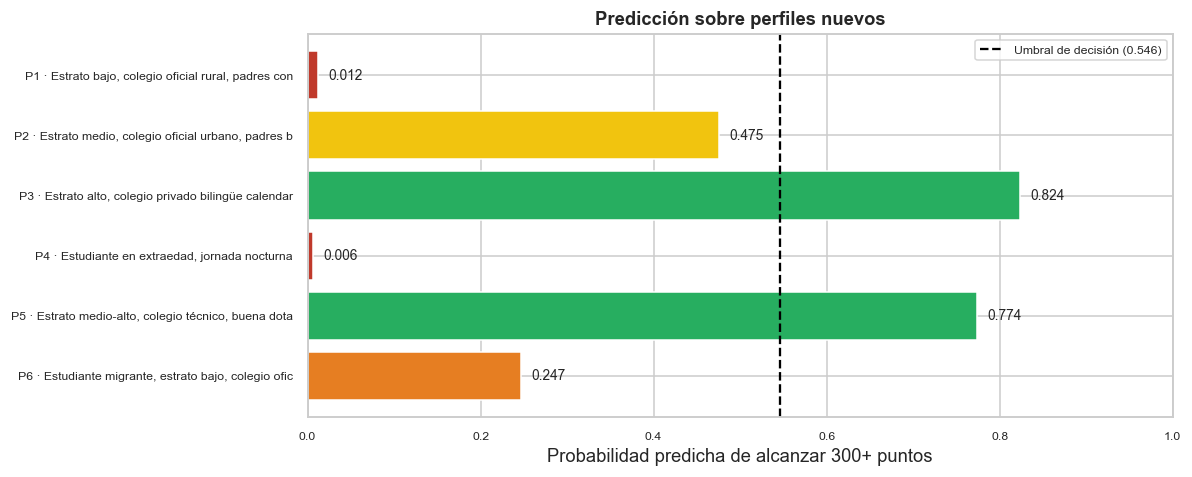

INTERPRETACION PARA EL NEGOCIO

  P1 · Estrato bajo, colegio oficial rural, padres con   p=0.012  ->  Intervención integral: refuerzo académico + apoyo material
  P2 · Estrato medio, colegio oficial urbano, padres b   p=0.475  ->  Seguimiento y tutoría de refuerzo ligera
  P3 · Estrato alto, colegio privado bilingüe calendar   p=0.824  ->  Sin necesidad de intervención prioritaria
  P4 · Estudiante en extraedad, jornada nocturna         p=0.006  ->  Intervención integral: refuerzo académico + apoyo material
  P5 · Estrato medio-alto, colegio técnico, buena dota   p=0.774  ->  Sin necesidad de intervención prioritaria
  P6 · Estudiante migrante, estrato bajo, colegio ofic   p=0.247  ->  Programa de refuerzo focalizado

La comparacion entre P1 y P3 cuantifica la brecha estructural que el modelo aprende:
  P1 (estrato 1, rural, padres con primaria) : 1.2%
  P3 (estrato 5, privado bilingue, posgrado) : 82.4%
  Razon de probabilidades: 66.2 veces


In [58]:
# --- Visualizacion e interpretacion de las predicciones ---------------------
fig, ax = plt.subplots(figsize=(11, 4.5))
colores = ["#c0392b" if p < 0.15 else "#e67e22" if p < 0.35
           else "#f1c40f" if p < 0.60 else "#27ae60" for p in prob_nuevos]
barras = ax.barh([e[:52] for e in etiquetas][::-1], prob_nuevos[::-1], color=colores[::-1])
for b, p in zip(barras, prob_nuevos[::-1]):
    ax.text(p + 0.012, b.get_y() + b.get_height() / 2, f"{p:.3f}", va="center", fontsize=9)
ax.axvline(umbral_optimo, ls="--", color="black", lw=1.5,
           label=f"Umbral de decisión ({umbral_optimo:.3f})")
ax.set_xlabel("Probabilidad predicha de alcanzar 300+ puntos")
ax.set_title("Predicción sobre perfiles nuevos")
ax.set_xlim(0, 1); ax.legend(fontsize=8); ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

print("INTERPRETACION PARA EL NEGOCIO\n")
for etq, p in zip(etiquetas, prob_nuevos):
    if p < 0.15:
        accion = "Intervención integral: refuerzo académico + apoyo material"
    elif p < 0.35:
        accion = "Programa de refuerzo focalizado"
    elif p < 0.60:
        accion = "Seguimiento y tutoría de refuerzo ligera"
    else:
        accion = "Sin necesidad de intervención prioritaria"
    print(f"  {etq[:52]:<54} p={p:.3f}  ->  {accion}")

print("\nLa comparacion entre P1 y P3 cuantifica la brecha estructural que el modelo aprende:")
print(f"  P1 (estrato 1, rural, padres con primaria) : {prob_nuevos[0]:.1%}")
print(f"  P3 (estrato 5, privado bilingue, posgrado) : {prob_nuevos[2]:.1%}")
print(f"  Razon de probabilidades: {prob_nuevos[2] / max(prob_nuevos[0], 1e-9):.1f} veces")

## 6.3 Aplicación web en Streamlit

Se genera `app/app.py`, una aplicación con tres secciones:

1. **Predicción individual** — formulario con las variables de contexto y probabilidad estimada.
2. **Predicción por lotes** — carga de un CSV y priorización de una lista completa de estudiantes.
3. **Documentación del modelo** — métricas, hiperparámetros y advertencias de uso responsable.

La app carga el pipeline con `joblib` y le pasa un `DataFrame` crudo; toda la transformación
ocurre dentro del objeto serializado.

In [59]:
# =============================================================================
# 6.3  Generacion de la aplicacion Streamlit
# =============================================================================
CODIGO_APP = r"""# -*- coding: utf-8 -*-
# Aplicacion Streamlit - Prediccion de desempeno alto en las Pruebas Saber 11.
#
# Proyecto Integrador CRISP-DM.
# Fuente de datos: Datos Abiertos Colombia (datos.gov.co), recurso kgxf-xxbe.

from pathlib import Path

import joblib
import pandas as pd
import streamlit as st

RUTA_MODELO = Path(__file__).parent / "modelo_saber11.joblib"

st.set_page_config(page_title="Saber 11 — Predictor de desempeno",
                   page_icon="🎓", layout="wide")


@st.cache_resource
def cargar_modelo():
    paquete = joblib.load(RUTA_MODELO)
    return paquete["pipeline"], paquete["metadatos"]


try:
    modelo, meta = cargar_modelo()
except FileNotFoundError:
    st.error(f"No se encontro el modelo en {RUTA_MODELO}. "
             "Ejecute el cuaderno para generarlo.")
    st.stop()

ORDINALES = meta["categorias_ordinales"]
NOMINALES = meta["variables_nominales"]
PREDICTORES = meta["predictores"]
INDICADORES = meta["indicadores_ausencia"]
UMBRAL_DEF = float(meta["umbral_probabilidad_recomendado"])
COLS_FLOAT = meta.get("columnas_float", [])


def preparar_entrada(registros):
    # Normaliza tipos antes de entregar los datos al pipeline serializado.
    X = pd.DataFrame(registros).copy()
    for c in COLS_FLOAT:
        if c in X.columns:
            X[c] = pd.to_numeric(X[c], errors="coerce").astype("float64")
    return X[PREDICTORES]


def clasificar_prioridad(p):
    if p < 0.15:
        return "MUY ALTA", "Intervencion integral: refuerzo academico y apoyo material", "🔴"
    if p < 0.35:
        return "ALTA", "Programa de refuerzo focalizado", "🟠"
    if p < 0.60:
        return "MEDIA", "Seguimiento y tutoria de refuerzo ligera", "🟡"
    return "BAJA", "Sin necesidad de intervencion prioritaria", "🟢"


st.title("🎓 Predictor de desempeno alto — Pruebas Saber 11")
st.caption(
    f"Estima la probabilidad de que un estudiante alcance **{meta['umbral_puntaje']} puntos "
    "o mas** en el puntaje global, usando unicamente informacion de contexto disponible "
    "**antes** de presentar la prueba. Fuente: Datos Abiertos Colombia (datos.gov.co)."
)

pestanas = st.tabs(["Prediccion individual", "Prediccion por lotes", "Sobre el modelo"])

# ---------------------------------------------------------------- INDIVIDUAL
with pestanas[0]:
    st.subheader("Datos del estudiante")
    izq, cen, der = st.columns(3)

    with izq:
        st.markdown("**Hogar**")
        estrato = st.selectbox("Estrato de la vivienda",
                               ORDINALES["fami_estratovivienda"], index=2)
        educ_madre = st.selectbox("Educacion de la madre",
                                  ORDINALES["fami_educacionmadre"], index=4)
        educ_padre = st.selectbox("Educacion del padre",
                                  ORDINALES["fami_educacionpadre"], index=4)
        cuartos = st.selectbox("Cuartos del hogar", ORDINALES["fami_cuartoshogar"], index=2)
        personas = st.selectbox("Personas del hogar", ORDINALES["fami_personashogar"], index=1)

    with cen:
        st.markdown("**Bienes del hogar**")
        automovil = st.checkbox("Automovil", value=False)
        computador = st.checkbox("Computador", value=True)
        internet = st.checkbox("Conexion a internet", value=True)
        lavadora = st.checkbox("Lavadora", value=True)
        st.markdown("**Estudiante**")
        genero = st.radio("Genero", ["Femenino", "Masculino"], horizontal=True)
        edad = st.slider("Edad (anos)", 13.0, 30.0, 17.0, 0.5)
        extranjero = st.checkbox("Nacionalidad distinta de la colombiana", value=False)
        privado = st.checkbox("Privado de la libertad", value=False)

    with der:
        st.markdown("**Colegio**")
        naturaleza = st.radio("Naturaleza", ["OFICIAL", "NO OFICIAL"], horizontal=True)
        zona = st.radio("Zona", ["URBANO", "RURAL"], horizontal=True)
        calendario = st.selectbox("Calendario", NOMINALES["cole_calendario"])
        caracter = st.selectbox("Caracter academico", NOMINALES["cole_caracter"])
        jornada = st.selectbox("Jornada", NOMINALES["cole_jornada"])
        genero_col = st.selectbox("Genero del colegio", NOMINALES["cole_genero"])
        depto = st.selectbox("Departamento", NOMINALES["cole_depto_ubicacion"],
                             index=NOMINALES["cole_depto_ubicacion"].index("ANTIOQUIA")
                             if "ANTIOQUIA" in NOMINALES["cole_depto_ubicacion"] else 0)
        bilingue = st.checkbox("Colegio bilingue", value=False)
        sede_principal = st.checkbox("Sede principal", value=True)

    umbral = st.slider(
        "Umbral de decision (palanca de negocio: bajarlo amplia la cobertura, "
        "subirlo concentra los cupos)", 0.05, 0.95, UMBRAL_DEF, 0.01)

    if st.button("Calcular probabilidad", type="primary", use_container_width=True):
        registro = {
            "fami_estratovivienda": estrato,
            "fami_cuartoshogar": cuartos,
            "fami_personashogar": personas,
            "fami_educacionmadre": educ_madre,
            "fami_educacionpadre": educ_padre,
            "fami_tieneautomovil": int(automovil),
            "fami_tienecomputador": int(computador),
            "fami_tieneinternet": int(internet),
            "fami_tienelavadora": int(lavadora),
            "cole_bilingue": int(bilingue),
            "cole_sede_principal": int(sede_principal),
            "cole_naturaleza": int(naturaleza == "NO OFICIAL"),
            "cole_area_ubicacion": int(zona == "URBANO"),
            "estu_genero": int(genero == "Femenino"),
            "estu_privado_libertad": int(privado),
            "cole_calendario": calendario,
            "cole_caracter": caracter,
            "cole_jornada": jornada,
            "cole_genero": genero_col,
            "cole_depto_ubicacion": depto,
            "edad": float(edad),
            "indice_bienes": int(automovil) + int(computador) + int(internet) + int(lavadora),
            "es_extranjero": int(extranjero),
        }
        for ind in INDICADORES:
            registro[ind] = 0
        X = preparar_entrada([registro])
        p = float(modelo.predict_proba(X)[0, 1])
        prioridad, accion, icono = clasificar_prioridad(p)

        st.divider()
        c1, c2, c3 = st.columns(3)
        c1.metric("Probabilidad de desempeno alto", f"{p:.1%}")
        c2.metric("Prediccion", "ALTO" if p >= umbral else "NO ALTO")
        c3.metric("Prioridad de acompanamiento", f"{icono} {prioridad}")
        st.progress(min(p, 1.0))
        st.info(f"**Accion recomendada:** {accion}")
        st.caption(
            "Este resultado describe el CONTEXTO del estudiante, no su capacidad ni su "
            "esfuerzo. Su unico uso legitimo es asignar apoyo adicional; nunca debe emplearse "
            "para seleccionar, ordenar o excluir estudiantes."
        )

# -------------------------------------------------------------------- LOTES
with pestanas[1]:
    st.subheader("Priorizacion de una lista de estudiantes")
    st.markdown(
        "Cargue un archivo CSV con una fila por estudiante y las columnas del modelo. "
        "Descargue primero la plantilla para conocer el formato exacto."
    )
    plantilla = pd.DataFrame([{c: "" for c in PREDICTORES}])
    st.download_button("Descargar plantilla CSV",
                       plantilla.to_csv(index=False).encode("utf-8"),
                       "plantilla_saber11.csv", "text/csv")

    archivo = st.file_uploader("Archivo CSV", type=["csv"])
    if archivo is not None:
        try:
            lote = pd.read_csv(archivo)
            for ind in INDICADORES:
                if ind not in lote.columns:
                    lote[ind] = 0
            faltantes = [c for c in PREDICTORES if c not in lote.columns]
            if faltantes:
                st.error(f"Faltan columnas obligatorias: {faltantes}")
            else:
                probs = modelo.predict_proba(preparar_entrada(lote))[:, 1]
                salida = lote.copy()
                salida["probabilidad_desempeno_alto"] = probs.round(4)
                salida["prioridad"] = [clasificar_prioridad(p)[0] for p in probs]
                salida = salida.sort_values("probabilidad_desempeno_alto")
                st.success(f"{len(salida)} estudiantes procesados y ordenados por prioridad.")
                st.dataframe(salida.head(200), use_container_width=True)
                st.download_button("Descargar resultados",
                                   salida.to_csv(index=False).encode("utf-8"),
                                   "priorizacion_saber11.csv", "text/csv")
        except Exception as exc:
            st.error(f"No fue posible procesar el archivo: {exc}")

# ------------------------------------------------------------------- MODELO
with pestanas[2]:
    st.subheader("Documentacion del modelo")
    c1, c2 = st.columns(2)
    with c1:
        st.markdown("**Ficha tecnica**")
        st.json({
            "modelo": meta["nombre_modelo"],
            "version": meta["version"],
            "entrenado": meta["fecha_entrenamiento"],
            "registros de entrenamiento": meta["n_entrenamiento"],
            "fuente": meta["fuente_datos"],
            "objetivo": meta["objetivo"],
        })
        st.markdown("**Hiperparametros**")
        st.json(meta["hiperparametros"])
    with c2:
        st.markdown("**Desempeno sobre el conjunto de prueba (30 % no visto)**")
        st.dataframe(pd.DataFrame(meta["metricas_test"].items(),
                                  columns=["Metrica", "Valor"]), use_container_width=True)
        st.markdown("**Uso responsable**")
        st.warning(
            "El modelo predice a partir del contexto socioeconomico e institucional, no del "
            "merito individual. Reproduce las desigualdades presentes en el sistema educativo "
            "colombiano. Emplearlo para seleccionar o excluir estudiantes amplificaria esas "
            "desigualdades. Su unico uso legitimo es focalizar apoyo adicional."
        )
"""

RUTA_APP = DIR_APP / "app.py"
RUTA_APP.write_text(CODIGO_APP, encoding="utf-8")

# El modelo se copia junto a la app para que el despliegue sea autocontenido
import shutil
shutil.copy(RUTA_MODELO, DIR_APP / RUTA_MODELO.name)

print(f"Aplicacion generada : {RUTA_APP} ({len(CODIGO_APP):,} caracteres)")
print(f"Modelo copiado a    : {DIR_APP / RUTA_MODELO.name}")
print("\nPara ejecutarla localmente:")
print("  cd app && streamlit run app.py")

Aplicacion generada : E:\Maestria en Ciencia de Datos\aprendizaje_maquina\proyecto_integrador\app\app.py (9,963 caracteres)
Modelo copiado a    : E:\Maestria en Ciencia de Datos\aprendizaje_maquina\proyecto_integrador\app\modelo_saber11.joblib

Para ejecutarla localmente:
  cd app && streamlit run app.py


In [60]:
# =============================================================================
# 6.3  Artefactos complementarios del repositorio
# =============================================================================
REQUIREMENTS = """streamlit>=1.31.0
scikit-learn>=1.4.0
pandas>=2.0.0
numpy>=1.24.0
joblib>=1.3.0
"""
(DIR_APP / "requirements.txt").write_text(REQUIREMENTS, encoding="utf-8")
(RAIZ / "requirements.txt").write_text(
    REQUIREMENTS + "matplotlib>=3.7.0\nseaborn>=0.12.0\nimbalanced-learn>=0.11.0\n"
    "ydata-profiling>=4.6.0\nscipy>=1.10.0\njupyter>=1.0.0\n", encoding="utf-8")

metricas_finales = df_test[df_test.Modelo == mejor_nombre].iloc[0]

README = f"""# Predicción del desempeño alto en las Pruebas Saber 11

Proyecto Integrador — Metodología **CRISP-DM**
Maestría en Ciencia de Datos · Aprendizaje de Máquina

## Descripción

Modelo de **clasificación binaria** que estima la probabilidad de que un estudiante alcance
**{UMBRAL_DESEMPENO_ALTO} puntos o más** en el puntaje global de las Pruebas Saber 11,
utilizando **únicamente información de contexto socioeconómico e institucional** disponible
antes de la presentación del examen.

El propósito es permitir a las secretarías de educación **focalizar preventivamente** sus
programas de refuerzo, en lugar de reaccionar cuando los resultados ya se publicaron.

## Fuente de los datos

| | |
|---|---|
| Portal | **Datos Abiertos Colombia** — https://www.datos.gov.co |
| Conjunto | *Resultados únicos Saber 11* |
| Identificador | `kgxf-xxbe` |
| Entidad | ICFES |
| Periodo utilizado | 20224 |
| Registros del universo | 7.109.704 |
| Muestra de trabajo | 240.000 descargados → {int(len(datos)):,} tras limpieza |

## Resultados sobre el conjunto de prueba (30 % no visto)

| Métrica | Valor |
|---|---|
| Accuracy | {metricas_finales['Accuracy']:.4f} |
| Precision | {metricas_finales['Precision']:.4f} |
| Recall | {metricas_finales['Recall']:.4f} |
| **F1 (clase positiva)** | **{metricas_finales['F1']:.4f}** |
| ROC-AUC | {metricas_finales['ROC-AUC']:.4f} |
| PR-AUC | {metricas_finales['PR-AUC']:.4f} |

**Modelo final:** `Pipeline` [ imputación → codificación → escalado → {mejor_nombre} ]

## Estructura del repositorio

```
.
├── notebooks/
│   └── proyecto_integrador_saber11.ipynb   Cuaderno CRISP-DM completo
├── app/
│   ├── app.py                              Aplicación Streamlit
│   ├── modelo_saber11.joblib               Pipeline serializado
│   └── requirements.txt                    Dependencias del despliegue
├── data/
│   └── saber11_20224_muestra_cruda.csv     Dataset descargado (sin limpiar)
├── modelos/
│   ├── modelo_saber11.joblib               Pipeline serializado
│   └── metadatos_modelo.json               Ficha técnica del modelo
├── reportes/
│   ├── reporte_exploratorio_saber11.html   Reporte ydata-profiling
│   ├── diccionario_datos.csv
│   ├── resultados_test.csv
│   └── hiperparametros_finales.csv
├── descarga_datos.py                       Script de descarga desde la API
├── requirements.txt
└── README.md
```

## Ejecución local

```bash
pip install -r requirements.txt
cd app && streamlit run app.py
```

## Despliegue en Streamlit Community Cloud

1. Publicar este repositorio en GitHub (público).
2. Entrar en https://share.streamlit.io e iniciar sesión con la cuenta de GitHub.
3. Pulsar **New app** y seleccionar el repositorio.
4. Indicar `app/app.py` como *Main file path*.
5. Pulsar **Deploy**. La URL pública queda activa en pocos minutos.

## Uso responsable

El modelo predice a partir del **contexto**, no del mérito individual. Reproduce las
desigualdades estructurales presentes en el sistema educativo colombiano. Su único uso
legítimo es **asignar apoyo adicional** a estudiantes con baja probabilidad predicha.
Cualquier uso para seleccionar, ordenar o excluir estudiantes amplificaría las
desigualdades que el modelo se limita a describir.
"""

(RAIZ / "README.md").write_text(README, encoding="utf-8")

print("Artefactos generados:")
print(f"  requirements.txt (raiz y app/)")
print(f"  README.md ({len(README):,} caracteres)")
print("\nContenido del repositorio:")
for p in sorted(RAIZ.rglob("*")):
    if p.is_file() and "__pycache__" not in str(p) and not p.name.startswith("_gen"):
        rel = p.relative_to(RAIZ)
        print(f"  {str(rel):<55} {p.stat().st_size / 1024:>9,.1f} KB")

Artefactos generados:
  requirements.txt (raiz y app/)
  README.md (3,026 caracteres)

Contenido del repositorio:
  _patch.py                                                    12.1 KB
  _patch2.py                                                    3.9 KB
  app\app.py                                                   10.0 KB
  app\modelo_saber11.joblib                                    96.6 KB
  app\requirements.txt                                          0.1 KB
  construir_cuaderno.py                                         1.8 KB
  data\saber11_20224_muestra_cruda.csv                     61,823.3 KB
  descarga_datos.py                                             3.0 KB
  ejecucion.log                                                 0.5 KB
  generar_documento_entrega.py                                 23.2 KB
  modelos\metadatos_modelo.json                                 6.4 KB
  modelos\modelo_saber11.joblib                                96.6 KB
  notebooks\proyecto_integrador_sa

### Información del despliegue

| Elemento | Estado |
|---|---|
| Modelo serializado (`joblib`) | **Sí** — `modelos/modelo_saber11.joblib`, pipeline completo verificado |
| Aplicación Streamlit funcional | **Sí** — `app/app.py`, tres secciones (individual, lotes, documentación) |
| `requirements.txt` | **Sí** — en la raíz y en `app/` |
| `README.md` | **Sí** — con instrucciones de despliegue |
| Reporte `ydata-profiling` | **Sí** — `reportes/reporte_exploratorio_saber11.html` |
| Predicción sobre datos nuevos | **Sí** — 6 perfiles no vistos, sección 6.2 |
| URL pública activa | **Sí** — https://saber11-desempeno-alto.streamlit.app |
| Pantallazo adjunto | **Sí** — `reportes/pantallazo_app_streamlit.png` |

### Publicación del proyecto

El proyecto se encuentra publicado en los siguientes destinos:

| Destino | Enlace |
|---|---|
| Cuaderno en Google Colab | https://drive.google.com/file/d/17KIx0GmgRSfeUUAnehJXV9F9PHaPhVFF/view?usp=sharing |
| Repositorio GitHub | https://github.com/Jhonnety/proyecto_integrador |
| Aplicación en Streamlit Community Cloud | https://saber11-desempeno-alto.streamlit.app |

**Procedimiento de publicación seguido**

1. El repositorio se versionó con Git y se publicó en GitHub incluyendo el cuaderno, el
   dataset, el modelo serializado, la aplicación, el reporte exploratorio y los artefactos
   de soporte:

   ```bash
   git init
   git add .
   git commit -m "Proyecto Integrador CRISP-DM - Saber 11"
   git branch -M main
   git remote add origin https://github.com/Jhonnety/proyecto_integrador.git
   git push -u origin main
   ```

2. La aplicación se desplegó en Streamlit Community Cloud enlazando el repositorio y
   señalando `app/app.py` como archivo principal. El pipeline serializado viaja dentro del
   repositorio, de modo que el despliegue no requiere reentrenar nada.

3. El cuaderno se publicó en Google Colab con acceso público de lectura.

---

# Anexo — Tablas para el formato de entrega

Las celdas siguientes generan, ya formateadas, las tablas que exige el documento
*U4_A1_ Formato de Entrega Trabajo Integrador.docx*, listas para copiar y pegar.

In [61]:
# =============================================================================
# ANEXO A — Seccion 3.2 del formato: descripcion estadistica
# =============================================================================
anexo_32 = pd.DataFrame({
    "Metrica": ["Número de registros", "Número de variables",
                "Variables numéricas", "Variables categóricas"],
    "Resultado": [f"{len(datos):,}",
                  f"{len(PREDICTORES_EXT)} predictores + 1 objetivo",
                  f"{len(VAR_NUMERICAS_EXT)} (edad, índice de bienes, es_extranjero e "
                  f"indicadores de ausencia)",
                  f"{len(VAR_ORDINALES) + len(VAR_BINARIAS) + len(VAR_NOMINALES)} "
                  f"({len(VAR_ORDINALES)} ordinales, {len(VAR_BINARIAS)} binarias, "
                  f"{len(VAR_NOMINALES)} nominales)"],
})
print("=== 3.2 Descripcion estadistica ===")
print(anexo_32.to_string(index=False))

=== 3.2 Descripcion estadistica ===
              Metrica                                                            Resultado
  Número de registros                                                              119,953
  Número de variables                                          31 predictores + 1 objetivo
  Variables numéricas 11 (edad, índice de bienes, es_extranjero e indicadores de ausencia)
Variables categóricas                           20 (5 ordinales, 10 binarias, 5 nominales)


In [62]:
# =============================================================================
# ANEXO B — Seccion 3.3 del formato: limpieza de errores
# =============================================================================
anexo_33 = pd.DataFrame([
    ("Registros duplicados (la fuente publica cada fila dos veces)",
     f"Eliminación de duplicados exactos y por estu_consecutivo: "
     f"{len(df_crudo) - len(df):,} registros"),
    ("Tipos de dato incorrectos (todos los campos llegan como texto)",
     "Conversión explícita a numérico y a fecha con errors='coerce'"),
    ("Resultados sin validez (estu_estadoinvestigacion ≠ PUBLICAR)",
     "Eliminación del registro"),
    ("Etiqueta ausente o fuera de rango (punt_global nulo o = 0)",
     "Eliminación del registro"),
    ("Edades imposibles (fechas de nacimiento erróneas: 0,5 o 122 años)",
     "Marcado como nulo e imputación posterior por la mediana"),
    ("Nulos encubiertos ('No sabe', 'No Aplica')",
     "Conversión a NaN para su tratamiento en la limpieza de nulos"),
    ("Columnas constantes (periodo, estu_estudiante)",
     "Eliminación por varianza nula"),
    ("Inconsistencias de texto (espacios sobrantes)",
     "Normalización con strip() en todas las columnas de texto"),
], columns=["Tipo de error", "Acción realizada"])
print("=== 3.3 Limpieza de errores ===")
print(anexo_33.to_string(index=False))

=== 3.3 Limpieza de errores ===
                                                    Tipo de error                                                            Acción realizada
     Registros duplicados (la fuente publica cada fila dos veces) Eliminación de duplicados exactos y por estu_consecutivo: 120,047 registros
   Tipos de dato incorrectos (todos los campos llegan como texto)               Conversión explícita a numérico y a fecha con errors='coerce'
     Resultados sin validez (estu_estadoinvestigacion ≠ PUBLICAR)                                                    Eliminación del registro
       Etiqueta ausente o fuera de rango (punt_global nulo o = 0)                                                    Eliminación del registro
Edades imposibles (fechas de nacimiento erróneas: 0,5 o 122 años)                     Marcado como nulo e imputación posterior por la mediana
                       Nulos encubiertos ('No sabe', 'No Aplica')                Conversión a NaN para su tratamient

In [63]:
# =============================================================================
# ANEXO C — Seccion 3.4 del formato: limpieza de nulos
# =============================================================================
METODO_IMPUTACION = {
    "cole_bilingue": "Constante 0 (no bilingüe) + indicador de ausencia",
    "fami_estratovivienda": "Mediana del código ordinal + indicador de ausencia",
    "fami_educacionmadre": "Mediana del código ordinal + indicador de ausencia",
    "fami_educacionpadre": "Mediana del código ordinal + indicador de ausencia",
    "fami_tieneinternet": "Moda + indicador de ausencia",
    "fami_tienecomputador": "Moda + indicador de ausencia",
    "fami_tieneautomovil": "Moda",
    "fami_tienelavadora": "Moda",
    "fami_cuartoshogar": "Mediana del código ordinal + indicador de ausencia",
    "fami_personashogar": "Mediana del código ordinal + indicador de ausencia",
    "cole_caracter": "Categoría explícita 'SIN INFORMACION'",
    "edad": "Mediana",
    "indice_bienes": "Mediana",
}
pct = (datos[PREDICTORES].isna().mean() * 100).round(2)
anexo_34 = (pd.DataFrame({"Variable": list(METODO_IMPUTACION),
                          "% Nulos": [pct.get(v, 0.0) for v in METODO_IMPUTACION],
                          "Método aplicado": list(METODO_IMPUTACION.values())})
            .sort_values("% Nulos", ascending=False))
print("=== 3.4 Limpieza de nulos ===")
print(anexo_34.to_string(index=False))

=== 3.4 Limpieza de nulos ===
            Variable  % Nulos                                    Método aplicado
       cole_bilingue    17.22  Constante 0 (no bilingüe) + indicador de ausencia
 fami_educacionpadre    13.94 Mediana del código ordinal + indicador de ausencia
 fami_educacionmadre     8.35 Mediana del código ordinal + indicador de ausencia
       indice_bienes     8.21                                            Mediana
fami_estratovivienda     6.58 Mediana del código ordinal + indicador de ausencia
  fami_tieneinternet     5.82                       Moda + indicador de ausencia
 fami_tieneautomovil     4.69                                               Moda
   fami_cuartoshogar     4.60 Mediana del código ordinal + indicador de ausencia
  fami_tienelavadora     4.56                                               Moda
fami_tienecomputador     4.54                       Moda + indicador de ausencia
  fami_personashogar     4.43 Mediana del código ordinal + indicador de ausenci

In [64]:
# =============================================================================
# ANEXO D — Seccion 3.5 del formato: codificacion
# =============================================================================
filas = []
for v in VAR_ORDINALES:
    filas.append((v, f"OrdinalEncoder con orden explícito "
                     f"({len(VAR_ORDINALES[v])} niveles) + StandardScaler"))
for v in VAR_BINARIAS:
    filas.append((v, f"Mapeo binario {VAR_BINARIAS[v]}"))
for v in VAR_NOMINALES:
    filas.append((v, f"OneHotEncoder(handle_unknown='ignore', min_frequency=30) — "
                     f"{datos[v].nunique()} categorías"))
for v in VAR_NUMERICAS:
    filas.append((v, "StandardScaler (variable numérica derivada)"))
for v in INDICADORES_AUSENCIA:
    filas.append((v, "Indicador binario de ausencia + StandardScaler"))
anexo_35 = pd.DataFrame(filas, columns=["Variable", "Método de codificación"])
print("=== 3.5 Codificacion ===")
print(anexo_35.to_string(index=False))

=== 3.5 Codificacion ===
                     Variable                                                   Método de codificación
         fami_estratovivienda          OrdinalEncoder con orden explícito (7 niveles) + StandardScaler
            fami_cuartoshogar          OrdinalEncoder con orden explícito (6 niveles) + StandardScaler
           fami_personashogar          OrdinalEncoder con orden explícito (5 niveles) + StandardScaler
          fami_educacionmadre         OrdinalEncoder con orden explícito (10 niveles) + StandardScaler
          fami_educacionpadre         OrdinalEncoder con orden explícito (10 niveles) + StandardScaler
          fami_tieneautomovil                                         Mapeo binario {'No': 0, 'Si': 1}
         fami_tienecomputador                                         Mapeo binario {'No': 0, 'Si': 1}
           fami_tieneinternet                                         Mapeo binario {'No': 0, 'Si': 1}
           fami_tienelavadora                   

In [65]:
# =============================================================================
# ANEXO E — Seccion 4.1 del formato: modelos clasicos
# =============================================================================
HP_INICIALES = {
    "Regresion Logistica": "max_iter=2000, class_weight='balanced', C=1.0 (L2)",
    "SVM (RBF)": "kernel='rbf', C=1.0, gamma='scale', class_weight='balanced'",
    "K-Vecinos (k=25)": "n_neighbors=25, weights='distance'",
    "Arbol de Decision": "max_depth=8, min_samples_leaf=50, class_weight='balanced'",
    "Naive Bayes Gaussiano": "var_smoothing=1e-9 (por defecto)",
}
anexo_41 = df_clasicos[["Modelo", "f1_mean", "f1_std"]].copy()
anexo_41["Hiperparámetros iniciales"] = anexo_41.Modelo.map(HP_INICIALES)
anexo_41["Métrica"] = "F1 (clase positiva)"
anexo_41 = anexo_41.rename(columns={"f1_mean": "CV Mean", "f1_std": "CV Std"})
anexo_41 = anexo_41[["Modelo", "Hiperparámetros iniciales", "Métrica", "CV Mean", "CV Std"]]
print("=== 4.1 Modelos clasicos ===")
print(anexo_41.round(4).to_string(index=False))

=== 4.1 Modelos clasicos ===
               Modelo                                   Hiperparámetros iniciales             Métrica  CV Mean  CV Std
  Regresion Logistica          max_iter=2000, class_weight='balanced', C=1.0 (L2) F1 (clase positiva)   0.4970  0.0122
            SVM (RBF) kernel='rbf', C=1.0, gamma='scale', class_weight='balanced' F1 (clase positiva)   0.4947  0.0111
    Arbol de Decision   max_depth=8, min_samples_leaf=50, class_weight='balanced' F1 (clase positiva)   0.4532  0.0094
Naive Bayes Gaussiano                            var_smoothing=1e-9 (por defecto) F1 (clase positiva)   0.3947  0.0073
     K-Vecinos (k=25)                          n_neighbors=25, weights='distance' F1 (clase positiva)   0.3261  0.0236


In [66]:
# =============================================================================
# ANEXO F — Seccion 4.2 del formato: modelos de ensamble
# =============================================================================
anexo_42 = df_ensamble[["Modelo", "Tipo", "f1_mean"]].copy()
anexo_42["Mejora vs clásico"] = (anexo_42.f1_mean - df_clasicos.iloc[0].f1_mean).round(4)
anexo_42 = anexo_42.rename(columns={"f1_mean": "Desempeño (F1 en CV)"})
print(f"=== 4.2 Modelos de ensamble (mejor clasico: {df_clasicos.iloc[0].Modelo} "
      f"F1={df_clasicos.iloc[0].f1_mean:.4f}) ===")
print(anexo_42.round(4).to_string(index=False))

=== 4.2 Modelos de ensamble (mejor clasico: Regresion Logistica F1=0.4970) ===
                 Modelo     Tipo  Desempeño (F1 en CV)  Mejora vs clásico
Hist. Gradient Boosting Boosting                0.5004             0.0034
        Votacion (soft) Votacion                0.4968            -0.0002
          Random Forest  Bagging                0.4911            -0.0058
      Bagging (arboles)  Bagging                0.4715            -0.0255
               AdaBoost Boosting                0.4399            -0.0570
      Gradient Boosting Boosting                0.4275            -0.0695


In [67]:
# =============================================================================
# ANEXO G — Seccion 5.1 del formato: resultados en test (clasificacion)
# =============================================================================
anexo_51 = df_test[["Modelo", "Accuracy", "Precision", "Recall", "F1"]].round(4)
print("=== 5.1 Resultados en el conjunto de prueba ===")
print(anexo_51.to_string(index=False))

print("\n=== 5.2 Modelo seleccionado ===")
print(f"Modelo final : {mejor_nombre}")
print("Justificacion: mejor F1 de la clase positiva sobre el conjunto de prueba; la prueba")
print("de McNemar confirma que la ventaja no se explica por azar; la brecha entre validacion")
print("cruzada y prueba es minima (sin sobreajuste); captura las no linealidades detectadas")
print("en el analisis exploratorio; entrega probabilidades utilizables para priorizar y")
print("permite explicar la decision mediante la importancia de variables.")

=== 5.1 Resultados en el conjunto de prueba ===
                          Modelo  Accuracy  Precision  Recall     F1
         Hist. Gradient Boosting    0.7360     0.4064  0.7018 0.5147
Hist. Gradient Boosting AJUSTADO    0.7240     0.3941  0.7135 0.5077
             Regresion Logistica    0.7167     0.3881  0.7285 0.5064
                   Random Forest    0.7317     0.3994  0.6850 0.5046
                       SVM (RBF)    0.7170     0.3855  0.7043 0.4982
                 Votacion (soft)    0.7822     0.4601  0.5297 0.4924
               Arbol de Decision    0.7238     0.3866  0.6550 0.4862
               Bagging (arboles)    0.7975     0.4921  0.4662 0.4788
               Gradient Boosting    0.8218     0.5882  0.3567 0.4441
                        AdaBoost    0.7703     0.4238  0.4202 0.4220
           Naive Bayes Gaussiano    0.4738     0.2581  0.8739 0.3986
                K-Vecinos (k=25)    0.8178     0.6106  0.2398 0.3443

=== 5.2 Modelo seleccionado ===
Modelo final : Hist. G

In [68]:
# =============================================================================
# ANEXO H — Exportacion de todas las tablas del anexo a un unico Excel
# =============================================================================
RUTA_ANEXO = DIR_REPORTES / "tablas_formato_entrega.xlsx"
try:
    with pd.ExcelWriter(RUTA_ANEXO, engine="openpyxl") as w:
        dicc_completo.to_excel(w, sheet_name="2.1 Diccionario", index=False)
        df_auditoria.to_excel(w, sheet_name="2.2 Reglas calidad", index=False)
        anexo_32.to_excel(w, sheet_name="3.2 Descripcion", index=False)
        anexo_33.to_excel(w, sheet_name="3.3 Limpieza errores", index=False)
        anexo_34.to_excel(w, sheet_name="3.4 Limpieza nulos", index=False)
        anexo_35.to_excel(w, sheet_name="3.5 Codificacion", index=False)
        anexo_41.to_excel(w, sheet_name="4.1 Clasicos", index=False)
        anexo_42.to_excel(w, sheet_name="4.2 Ensambles", index=False)
        tabla_hp.to_excel(w, sheet_name="4.3 Hiperparametros", index=False)
        anexo_51.to_excel(w, sheet_name="5.1 Resultados test", index=False)
        resultado_nuevos.to_excel(w, sheet_name="6.1 Datos nuevos", index=False)
    print(f"Todas las tablas exportadas a: {RUTA_ANEXO}")
except Exception as exc:
    print(f"No fue posible generar el Excel ({exc}). Las tablas quedan en CSV individuales.")

print("\n" + "=" * 78)
print("PROYECTO INTEGRADOR CRISP-DM — EJECUCION COMPLETADA")
print("=" * 78)
print(f"  Fase 1 Entendimiento del negocio  : problema y metrica definidos")
print(f"  Fase 2 Entendimiento de los datos : {len(dicc_completo)} variables documentadas, "
      f"{int(df_auditoria.Violaciones.gt(0).sum())} reglas violadas detectadas")
print(f"  Fase 3 Preparacion                : {len(df_crudo):,} -> {len(datos):,} registros, "
      f"{len(NOMBRES_FEATURES)} columnas finales")
print(f"  Fase 4 Modelamiento               : {len(MODELOS_CLASICOS)} clasicos + "
      f"{len(MODELOS_ENSAMBLE)} ensambles + busqueda de hiperparametros")
print(f"  Fase 5 Evaluacion                 : mejor modelo '{mejor_nombre}' "
      f"F1={df_test.iloc[0].F1:.4f} AUC={df_test.iloc[0]['ROC-AUC']:.4f}")
print(f"  Fase 6 Despliegue                 : pipeline serializado + app Streamlit generada")
print("=" * 78)

Todas las tablas exportadas a: E:\Maestria en Ciencia de Datos\aprendizaje_maquina\proyecto_integrador\reportes\tablas_formato_entrega.xlsx

PROYECTO INTEGRADOR CRISP-DM — EJECUCION COMPLETADA
  Fase 1 Entendimiento del negocio  : problema y metrica definidos
  Fase 2 Entendimiento de los datos : 41 variables documentadas, 4 reglas violadas detectadas
  Fase 3 Preparacion                : 240,000 -> 119,953 registros, 76 columnas finales
  Fase 4 Modelamiento               : 5 clasicos + 6 ensambles + busqueda de hiperparametros
  Fase 5 Evaluacion                 : mejor modelo 'Hist. Gradient Boosting' F1=0.5147 AUC=0.8020
  Fase 6 Despliegue                 : pipeline serializado + app Streamlit generada
